<a href="https://colab.research.google.com/github/HuVddme/speech_analysis/blob/main/Latest_Dementia_Regression_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from pathlib import Path

In [4]:
ROOT_DATA_PATH = Path('/home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/')

In [3]:
# from modelscope import snapshot_download
# snapshot_download('iic/speech_zipenhancer_ans_multiloss_16k_base')
# snapshot_download('iic/SenseVoiceSmall')
# from huggingface_hub import snapshot_download as hf_snapshot
# hf_snapshot("openbmb/VoxCPM-0.5B")

1.Cell Setup

In [8]:
!pip install -q transformers datasets torchaudio accelerate
!pip install -q faster-whisper
!pip install -q soundfile
!pip install audiomentations --quiet


import pandas as pd
import numpy as np
from pathlib import Path
import re
import os

from sklearn.model_selection import train_test_split

from datasets import load_dataset, concatenate_datasets
from transformers import (
    AutoFeatureExtractor,
    AutoTokenizer,
    AutoModelForAudioClassification,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import torchaudio
import torch
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

# verify gpu
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU is available and ready for training!")
else:
    print("Warning: GPU not found. Training will be slow.")


Device: cuda
GPU is available and ready for training!


2.CREATE COMBINED MANIFEST FILES

In [9]:
ROOT_DATA_PATH = Path('/home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/')
OUTPUT_PATH = ROOT_DATA_PATH / 'Manifest_Files'

DATASET_CONFIGS = [
    {
        'name': 'ADReSS',
        'path': ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train',
        'sub_groups': ['cc', 'cd'],
        'audio_location': 'Full_wave_enhanced_audio',
        'transcript_location': 'transcription',
        'transcript_ext': '.cha'
    },
    {
        'name': 'ADReSSo_Diag',
        'path': ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train',
        'sub_groups': ['ad', 'cn'],
        'audio_location': 'audio',
        'metadata_csv_path': ROOT_DATA_PATH / 'ADReSSo/ADReSSo-diagnosis-train/diagnosis/train/adresso-train-mmse-scores.csv'
    },
    {
        'name': 'ADReSS-M',
        'path': ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/train',
        'sub_groups': [None],
    },
    {
        'name': 'TAUKADIAL',
        'path': ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train',
        'sub_groups': [None],
    }
]

def infer_language(dataset_name: str) -> str:
    if dataset_name == "ADReSS-M":
        return "Greek"
    if dataset_name == "TAUKADIAL":
        return "Mandarin"
    return "English"

all_data = []
print("Starting combined data processing...")
print("=" * 60)

for config in DATASET_CONFIGS:
    dataset_name = config['name']
    dataset_path = config['path']
    language = infer_language(dataset_name)

    print(f"\n--> Processing Dataset: {dataset_name} ({language})")

    # Build search roots for audio
    search_paths = []
    if config['sub_groups'] == [None]:
        search_paths.append({'path': dataset_path, 'group': ''})
    else:
        for group in config['sub_groups']:
            audio_dir = dataset_path / config.get('audio_location', '') / group
            search_paths.append({'path': audio_dir, 'group': group})

    for item in search_paths:
        audio_dir = item['path']
        group_name = item['group']

        if not audio_dir.exists():
            print(f"  - Warning: Search directory not found: {audio_dir}")
            continue

        wav_files = list(audio_dir.rglob('*.wav'))
        mp3_files = list(audio_dir.rglob('*.mp3'))
        audio_files = wav_files + mp3_files

        if group_name:
            print(f"  - Group {group_name.upper()}: found {len(audio_files)} audio files.")
        else:
            print(f"  - Found {len(audio_files)} audio files recursively.")

        for audio_path in audio_files:
            try:
                base_id = audio_path.stem.strip()
                speaker_id = f"{dataset_name}__{base_id}"

                # Default text
                full_text = ""
                text_source = "missing"

                #Transcript Logic
                if dataset_name == 'ADReSS':
                    transcript_dir = dataset_path / config['transcript_location'] / group_name
                    transcript_path = transcript_dir / f"{base_id}{config['transcript_ext']}"

                    if transcript_path.exists():
                        with open(transcript_path, 'r', errors='ignore') as f:
                            lines = [line.strip() for line in f if line.startswith('*PAR:')]
                            # clean chat markers and delimiters
                            cleaned = []
                            for line in lines:
                                line = re.sub(r'^\*PAR:\s*', '', line)
                                line = re.sub(r'\s*\.+?\', '', line)
                                cleaned.append(line.strip())
                            full_text = " ".join([c for c in cleaned if c]).strip()
                        if full_text:
                            text_source = "manual"

                all_data.append({
                    'audio_filepath': str(audio_path),
                    'text': str(full_text),
                    'speaker_id': speaker_id,
                    'dataset': dataset_name,
                    'language': language,
                    'base_id': base_id,
                    'text_source': text_source
                })

            except Exception as e:
                print(f"  - Error processing {audio_path.name}: {e}")

print("\n" + "=" * 60)
print(f"Total processing complete. Found {len(all_data)} rows across all datasets.")

if all_data:
    OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame(all_data)

    # Split by speaker_id
    unique_speakers = df[['speaker_id']].drop_duplicates()
    train_speakers, val_speakers = train_test_split(unique_speakers, test_size=0.2, random_state=42)

    train_df = df[df['speaker_id'].isin(train_speakers['speaker_id'])].reset_index(drop=True)
    val_df = df[df['speaker_id'].isin(val_speakers['speaker_id'])].reset_index(drop=True)

    train_manifest_path = OUTPUT_PATH / 'combined_multilingual_train_manifest.csv'
    val_manifest_path = OUTPUT_PATH / 'combined_multilingual_validation_manifest.csv'

    train_df.to_csv(train_manifest_path, index=False)
    val_df.to_csv(val_manifest_path, index=False)

    print(f"\n Created combined manifest files in: {OUTPUT_PATH}")
    print(f"  - Training Manifest: {train_manifest_path.name} ({len(train_df)} samples)")
    print(f"  - Validation Manifest: {val_manifest_path.name} ({len(val_df)} samples)")

    print("\nQuick check (language counts):")
    print(pd.concat([train_df, val_df])['language'].value_counts())
    print("\nQuick check (text_source counts):")
    print(pd.concat([train_df, val_df])['text_source'].value_counts())
else:
    print("\n No data was processed. Double-check your dataset paths.")


Starting combined data processing...

--> Processing Dataset: ADReSS (English)
  - Group CC: found 54 audio files.


  - Group CD: found 54 audio files.

--> Processing Dataset: ADReSSo_Diag (English)
  - Group AD: found 87 audio files.
  - Group CN: found 79 audio files.

--> Processing Dataset: ADReSS-M (Greek)
  - Found 237 audio files recursively.

--> Processing Dataset: TAUKADIAL (Mandarin)
  - Found 387 audio files recursively.

Total processing complete. Found 898 rows across all datasets.

 Created combined manifest files in: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/Manifest_Files
  - Training Manifest: combined_multilingual_train_manifest.csv (718 samples)
  - Validation Manifest: combined_multilingual_validation_manifest.csv (180 samples)

Quick check (language counts):
language
Mandarin    387
English     274
Greek       237
Name: count, dtype: int64

Quick check (text_source counts):
text_source
missing    790
manual     108
Name: count, dtype: int64


3.AST process

In [10]:
from datasets import load_dataset, concatenate_datasets
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
from pathlib import Path
import pandas as pd
import numpy as np

manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'

raw = load_dataset('csv', data_files={'train': train_file, 'validation': val_file})
full_raw = concatenate_datasets([raw["train"], raw["validation"]])
print("Manifest rows:", len(full_raw))

#AST Feature Extractor
model_checkpoint_ast = "Simon-Kotchou/ssast-small-patch-audioset-16-16"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_checkpoint_ast)
print("AST feature extractor loaded.")


ROOT_DATA_PATH = Path('/home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/')
all_meta_dfs = []

# ADReSS
p = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(p/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(p/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta_dfs += [cc[['ID','MMSE']], cd[['ID','MMSE']]]

# ADReSSo
p = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(p).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta_dfs.append(adresso[['ID','MMSE']])

# ADReSS-M
p = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(p)

m = m.rename(columns={"adressfname": "ID", "mmse": "MMSE"})
m["ID"] = m["ID"].astype(str).str.strip()

all_meta_dfs.append(m[["ID", "MMSE"]])
print("  - ADReSS-M loaded:", m.shape)

# TAUKADIAL
p = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(p)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"})
        break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"})
        break
all_meta_dfs.append(t[['ID','MMSE']])

meta = pd.concat(all_meta_dfs, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()
print("MMSE lookup size:", len(mmse_lookup))

def lookup_mmse(dataset, base_id):
    base_id = str(base_id).strip()
    if dataset in ["ADReSS", "ADReSSo_Diag"]:
        return mmse_lookup.get(base_id)
    if dataset == "ADReSS-M":
        return mmse_lookup.get(base_id)
    if dataset == "TAUKADIAL":
        return mmse_lookup.get(base_id + ".wav") or mmse_lookup.get(base_id)
    return None

def add_label(ex):
    score = lookup_mmse(ex.get("dataset",""), ex.get("base_id",""))
    ex["label"] = float(score) if score is not None else -1.0
    return ex

labeled = full_raw.map(add_label)
labeled = labeled.filter(lambda x: x["label"] != -1.0)

print("AST labeled rows:", labeled.num_rows)
print(pd.Series(labeled["language"]).value_counts())


Generating train split: 718 examples [00:00, 87965.83 examples/s]
Generating validation split: 180 examples [00:00, 56019.49 examples/s]


Manifest rows: 898
AST feature extractor loaded.
  - ADReSS-M loaded: (237, 6)
MMSE lookup size: 730


Filter: 100%|██████████| 898/898 [00:00<00:00, 132655.41 examples/s]

AST labeled rows: 896
Mandarin    387
English     273
Greek       236
Name: count, dtype: int64


Audio Augumentation

In [11]:
from audiomentations import Compose, AddBackgroundNoise, Gain, GainTransition, Normalize
import os

USE_AUGMENTATION = False  # toggle for clean vs augmented runs

augment_pipeline = Compose([
    Gain(min_gain_db=-6, max_gain_db=6, p=0.3),
    GainTransition(min_gain_db=-6, max_gain_db=6, p=0.2),
    Normalize(p=1.0),
])

4.AST audio training

In [12]:
import os, gc
import numpy as np
import pandas as pd
import soundfile as sf
import torchaudio
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.model_selection import GroupKFold
from functools import partial
from transformers import TrainingArguments, Trainer, AutoModelForAudioClassification

#config
SEED = 42
N_SPLITS = 5

EPOCHS_HEAD = 1
EPOCHS_FULL = 8

BATCH_TRAIN = 2
BATCH_EVAL = 4
GRAD_ACCUM = 8
LR = 1e-5
WEIGHT_DECAY = 0.01

MAX_SECONDS = 30

torch.manual_seed(SEED)
np.random.seed(SEED)


AST_OUT = ROOT_DATA_PATH / f"ssast-k{N_SPLITS}-huber-v4"
AST_OUT.mkdir(parents=True, exist_ok=True)

# Guard flag
done_flag = AST_OUT / "_DONE.flag"
if done_flag.exists():
    raise RuntimeError(f"Already finished AST k={N_SPLITS} run. Delete {done_flag} if you truly want to rerun.")

print("ROOT_DATA_PATH =", ROOT_DATA_PATH)
print("AST_OUT        =", AST_OUT.resolve())

# z-score
labels = np.array(labeled["label"], dtype=float)
mu, sigma = float(labels.mean()), float(labels.std() + 1e-8)
print(f"Label mean={mu:.3f}, std={sigma:.3f}")

def add_norm_label(ex):
    ex["label_norm"] = float((ex["label"] - mu) / sigma)
    return ex

labeled_norm = labeled.map(add_norm_label)

# METRICS
def rmse_mmse(y_true_norm, y_pred_norm):
    y_true = y_true_norm * sigma + mu
    y_pred = y_pred_norm * sigma + mu
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def compute_metrics(eval_pred):
    preds, y = eval_pred
    preds = np.asarray(preds).reshape(-1)
    y = np.asarray(y).reshape(-1)
    return {"rmse": rmse_mmse(y, preds)}


# AUDIO COLLATOR
target_sr = feature_extractor.sampling_rate
max_samples = int(MAX_SECONDS * target_sr) if MAX_SECONDS is not None else None

def audio_collator(features, is_train=False):
    audio_arrays = []
    y = []

    for f in features:
        wav, sr = sf.read(f["audio_filepath"])

        if wav.ndim > 1:
            wav = wav.mean(axis=1)

        waveform = torch.from_numpy(wav).float().unsqueeze(0)

        if sr != target_sr:
            waveform = torchaudio.functional.resample(waveform, sr, target_sr)

        waveform = waveform.squeeze(0).numpy()


        if USE_AUGMENTATION and is_train:
            waveform = augment_pipeline(waveform, sample_rate=target_sr)

        if max_samples is not None and len(waveform) > max_samples:
            waveform = waveform[:max_samples]

        audio_arrays.append(waveform)
        y.append(float(f["label_norm"]))

    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=target_sr,
        padding=True,
        truncation=(max_samples is not None),
        max_length=(max_samples if max_samples is not None else None),
        return_tensors="pt"
    )

    inputs["labels"] = torch.tensor(y, dtype=torch.float32)
    return inputs


# TRAINER
class AudioRegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)

        # Huber loss (robust to outliers)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)

        return (loss, outputs) if return_outputs else loss


groups = np.array(labeled_norm["speaker_id"])
kfold = GroupKFold(n_splits=N_SPLITS)

fold_rmses = []
rows = []

print(f"Starting AST regression | k={N_SPLITS} | seed={SEED} | max_seconds={MAX_SECONDS}")

for fold, (tr_idx, va_idx) in enumerate(kfold.split(np.zeros(len(groups)), groups=groups), start=1):
    print("\n" + "="*55)
    print(f"FOLD {fold}/{N_SPLITS} | Train={len(tr_idx)} | Val={len(va_idx)}")
    print("="*55)

    train_fold = labeled_norm.select(tr_idx.tolist())
    val_fold   = labeled_norm.select(va_idx.tolist())

    model = AutoModelForAudioClassification.from_pretrained(
        model_checkpoint_ast,
        num_labels=1,
        ignore_mismatched_sizes=True
    )
    # Make intent explicit
    model.config.problem_type = "regression"
    model.config.num_labels = 1

    print(model.config.model_type)
    print(model.config.hidden_size)

    #train head only
    for name, p in model.named_parameters():
        if "classifier" not in name:
            p.requires_grad = False

    args_head = TrainingArguments(
        output_dir=str(AST_OUT / f"fold-{fold:02d}-head"),
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        report_to="none",
        num_train_epochs=EPOCHS_HEAD,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        logging_strategy="epoch",
        bf16=torch.cuda.is_available(),
        fp16=False,
        dataloader_num_workers=2,
        dataloader_pin_memory=True,
        remove_unused_columns=False,
        seed=SEED,
        load_best_model_at_end=True,
        metric_for_best_model="rmse",
        greater_is_better=False,
    )

    train_collator = partial(audio_collator, is_train=True)
    val_collator   = partial(audio_collator, is_train=False)

    trainer_head = AudioRegressionTrainer(
        model=model,
        args=args_head,
        train_dataset=train_fold,
        eval_dataset=val_fold,
        data_collator=train_collator,
        compute_metrics=compute_metrics,
    )
    trainer_head.train()

    del trainer_head
    torch.cuda.empty_cache()
    gc.collect()

    #full finetuning
    for p in model.parameters():
        p.requires_grad = True

    args_full = TrainingArguments(
        output_dir=str(AST_OUT / f"fold-{fold:02d}-full"),
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        report_to="none",
        num_train_epochs=EPOCHS_FULL,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        logging_strategy="epoch",
        bf16=torch.cuda.is_available(),
        fp16=False,
        dataloader_num_workers=2,
        dataloader_pin_memory=True,
        remove_unused_columns=False,
        seed=SEED,
        load_best_model_at_end=True,
        metric_for_best_model="rmse",
        greater_is_better=False,
    )

    trainer_full = AudioRegressionTrainer(
        model=model,
        args=args_full,
        train_dataset=train_fold,
        eval_dataset=val_fold,
        data_collator=train_collator,
        compute_metrics=compute_metrics,
    )
    trainer_full.train()

    #eval
    metrics = trainer_full.evaluate(eval_dataset=val_fold)
    rmse_val = float(metrics["eval_rmse"])
    fold_rmses.append(rmse_val)
    print("Fold RMSE (MMSE units):", rmse_val)

    #predictions
    pred = trainer_full.predict(val_fold)
    preds_norm = np.asarray(pred.predictions).reshape(-1)
    y_norm = np.asarray(pred.label_ids).reshape(-1)

    preds_mmse = preds_norm * sigma + mu
    y_mmse = y_norm * sigma + mu
    preds_mmse = np.clip(preds_mmse, 0.0, 30.0)

    for sid, yt, yp in zip(val_fold["speaker_id"], y_mmse, preds_mmse):
        rows.append({"fold": fold, "speaker_id": sid, "label": float(yt), "pred_audio": float(yp)})

    # saving final model
    fold_save_dir = AST_OUT / f"fold-{fold:02d}-final-v4"
    fold_save_dir.mkdir(parents=True, exist_ok=True)

    trainer_full.model.save_pretrained(fold_save_dir)
    feature_extractor.save_pretrained(fold_save_dir)

    # Save normalization stats
    (fold_save_dir / "label_norm_stats.txt").write_text(f"mu={mu}\n" f"sigma={sigma}\n")

    # Proof file
    (fold_save_dir / "_SAVED_OK.txt").write_text("saved\n")

    print("Saved fold final model to:", fold_save_dir.resolve())

    del trainer_full, model
    torch.cuda.empty_cache()
    gc.collect()

#saving csv output
df_preds = pd.DataFrame(rows)
pred_csv = AST_OUT / f"ast_k{N_SPLITS}_predictions.csv"
df_preds.to_csv(pred_csv, index=False)

rmse_csv = AST_OUT / f"ast_k{N_SPLITS}_fold_rmse.csv"
pd.DataFrame({"fold": list(range(1, N_SPLITS + 1)), "rmse": fold_rmses}).to_csv(rmse_csv, index=False)

# Done flag
done_flag.write_text("done")

print("\n" + "="*60)
print("AST k-fold complete")
print("Fold RMSEs:", [round(x, 4) for x in fold_rmses])
print(f"Mean RMSE: {float(np.mean(fold_rmses)):.4f} | Std: {float(np.std(fold_rmses)):.4f}")
print("Saved:")
print(" -", pred_csv.resolve())
print(" -", rmse_csv.resolve())
print("Guard flag written:", done_flag.resolve())

#list folder contents
print("\nAST_OUT contents:")
for p in sorted(AST_OUT.glob("*")):
    print(" -", p.name)

RuntimeError: Already finished AST k=5 run. Delete /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/ssast-k5-huber-v4/_DONE.flag if you truly want to rerun.

Speech to text transcripts

In [14]:
from faster_whisper import WhisperModel
from tqdm.auto import tqdm


ROOT_DATA_PATH = Path('/home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/')
MANIFEST_PATH = ROOT_DATA_PATH / 'Manifest_Files'
train_manifest_path = MANIFEST_PATH / 'combined_multilingual_train_manifest.csv'
val_manifest_path   = MANIFEST_PATH / 'combined_multilingual_validation_manifest.csv'

ASR_CACHE_DIR = ROOT_DATA_PATH / "asr_transcripts"
ASR_CACHE_DIR.mkdir(parents=True, exist_ok=True)


train_df = pd.read_csv(train_manifest_path)
val_df   = pd.read_csv(val_manifest_path)
full_df  = pd.concat([train_df.assign(split="train"), val_df.assign(split="validation")], ignore_index=True)

print("Loaded manifests.")
print("Rows:", len(full_df))
print(full_df["language"].value_counts())
print(full_df["text_source"].value_counts())

device = "cuda" if torch.cuda.is_available() else "cpu"
compute_type = "float16" if device == "cuda" else "int8"
print("ASR device:", device, "| compute_type:", compute_type)


asr_model = WhisperModel("medium", device=device, compute_type=compute_type)

def cache_path(row):
    return ASR_CACHE_DIR / f"{row['dataset']}__{row['base_id']}.txt"

def transcribe_one(audio_path, lang_hint):
    segments, info = asr_model.transcribe(
        audio_path,
        language=lang_hint,
        vad_filter=True
    )
    text = " ".join([seg.text.strip() for seg in segments]).strip()
    return text, info.language

def fill_asr(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    mask = (df["text_source"] == "missing")
    # mask = (df["text_source"] == "missing") & (df["language"].isin(["Greek", "Mandarin"]))
    targets = df[mask].copy()

    print(f"ASR targets: {len(targets)} rows")

    for idx, row in tqdm(
    targets.iterrows(),
    total=len(targets),
    desc="Transcribing audio files"
):
        out = cache_path(row)

        # Load from cache if exists
        if out.exists():
            df.at[idx, "text"] = out.read_text(errors="ignore")
            df.at[idx, "text_source"] = "asr_cached"
            continue

        lang_hint = "el" if row["language"] == "Greek" else "zh"
        try:
            text, detected = transcribe_one(row["audio_filepath"], lang_hint=lang_hint)
            out.write_text(text)
            df.at[idx, "text"] = text
            df.at[idx, "text_source"] = f"asr_{detected}"
        except Exception as e:
            # Keep missing but record failure
            df.at[idx, "text"] = ""
            df.at[idx, "text_source"] = "asr_failed"
            print(f"ASR failed for {row['speaker_id']} | {row['audio_filepath']} | err={e}")

    return df

full_df = fill_asr(full_df)

train_out = full_df[full_df["split"] == "train"].drop(columns=["split"]).reset_index(drop=True)
val_out   = full_df[full_df["split"] == "validation"].drop(columns=["split"]).reset_index(drop=True)

train_out.to_csv(train_manifest_path, index=False)
val_out.to_csv(val_manifest_path, index=False)

print("\n Updated manifests saved with ASR transcripts.")
print("Updated text_source counts:")
print(pd.concat([train_out, val_out])["text_source"].value_counts())
print("\nNon-empty text counts by language:")
tmp = pd.concat([train_out, val_out])
tmp["has_text"] = tmp["text"].astype(str).str.strip().apply(lambda x: len(x) > 0)
print(tmp.groupby("language")["has_text"].sum())


Loaded manifests.
Rows: 898
language
Mandarin    387
English     274
Greek       237
Name: count, dtype: int64
text_source
missing    790
manual     108
Name: count, dtype: int64
ASR device: cuda | compute_type: float16
ASR targets: 790 rows


Transcribing audio files: 100%|██████████| 790/790 [00:00<00:00, 3214.24it/s]


 Updated manifests saved with ASR transcripts.
Updated text_source counts:
text_source
asr_cached    790
manual        108
Name: count, dtype: int64

Non-empty text counts by language:
language
English     272
Greek       237
Mandarin    387
Name: has_text, dtype: int64


5.ModernBERT process

In [ ]:
import pandas as pd
from datasets import load_dataset, concatenate_datasets
from transformers import AutoTokenizer
from pathlib import Path

model_checkpoint_text = "jhu-clsp/mmBERT-base"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_text)

ROOT_DATA_PATH = Path('/home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/')
MANIFEST_PATH = ROOT_DATA_PATH / 'Manifest_Files'

train_file = MANIFEST_PATH / 'combined_multilingual_train_manifest.csv'
val_file   = MANIFEST_PATH / 'combined_multilingual_validation_manifest.csv'


print("Loading metadata from all 4 datasets...")
all_meta_dfs = []

# ADReSS 2020
try:
    p = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
    all_meta_dfs.append(pd.read_csv(p / 'cc_meta_data.txt', sep=';', header=0,
                                    names=['ID','age','gender','MMSE'], na_values=[' NA']))
    all_meta_dfs.append(pd.read_csv(p / 'cd_meta_data.txt', sep=';', header=0,
                                    names=['ID','age','gender','MMSE'], na_values=[' NA']))
    print("  - ADReSS loaded")
except Exception as e:
    print("  - ADReSS error:", e)

# ADReSSo
try:
    p = ROOT_DATA_PATH / 'ADReSSo/ADReSSo-diagnosis-train/diagnosis/train/adresso-train-mmse-scores.csv'
    df_adresso = pd.read_csv(p).rename(columns={'adressfname':'ID', 'mmse':'MMSE'})
    all_meta_dfs.append(df_adresso)
    print("  - ADReSSo loaded")
except Exception as e:
    print("  - ADReSSo error:", e)

# ADReSS-M
try:
    p = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
    df_m = pd.read_csv(p)
    if 'Id' in df_m.columns: df_m = df_m.rename(columns={'Id':'ID'})
    if 'mmse' in df_m.columns: df_m = df_m.rename(columns={'mmse':'MMSE'})
    all_meta_dfs.append(df_m[['ID','MMSE']])
    print("  - ADReSS-M loaded")
except Exception as e:
    print("  - ADReSS-M error:", e)

# TAUKADIAL
try:
    p = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
    df_t = pd.read_csv(p)
    if 'Id' in df_t.columns: df_t = df_t.rename(columns={'Id':'ID'})
    if 'tkdname' in df_t.columns: df_t = df_t.rename(columns={'tkdname':'ID'})
    if 'mmse' in df_t.columns: df_t = df_t.rename(columns={'mmse':'MMSE'})
    all_meta_dfs.append(df_t[['ID','MMSE']])
    print("  - TAUKADIAL loaded")
except Exception as e:
    print("  - TAUKADIAL error:", e)

full_meta_df = pd.concat(all_meta_dfs, ignore_index=True)
full_meta_df = full_meta_df.dropna(subset=['MMSE']).copy()
full_meta_df['ID'] = full_meta_df['ID'].astype(str).str.strip()
mmse_lookup = full_meta_df.set_index('ID')['MMSE'].to_dict()
print(f"Metadata lookup ready: {len(mmse_lookup)} MMSE entries")


raw = load_dataset('csv', data_files={'train': str(train_file), 'validation': str(val_file)})
full_raw = concatenate_datasets([raw['train'], raw['validation']])
print("Manifest rows:", len(full_raw))

#label using base_id and specific datasets
def get_mmse_for_row(dataset, base_id):
    base_id = str(base_id).strip()

    if dataset in ["ADReSS", "ADReSSo_Diag"]:
        return mmse_lookup.get(base_id)

    if dataset == "ADReSS-M":
        return mmse_lookup.get(base_id)

    if dataset == "TAUKADIAL":
        return mmse_lookup.get(base_id + ".wav") or mmse_lookup.get(base_id)

    return None

def prep_row(ex):
    score = get_mmse_for_row(ex.get("dataset",""), ex.get("base_id",""))
    ex["label"] = float(score) if score is not None else -1.0
    ex["text"] = str(ex.get("text","") if ex.get("text") is not None else "")
    return ex

fixed = full_raw.map(prep_row)

clean = fixed.filter(lambda x: x["label"] != -1.0 and len(x["text"].strip()) > 0)

print("After filtering:")
print("Rows:", clean.num_rows)

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

tokenized = clean.map(tokenize_fn, batched=True)

df_check = tokenized.to_pandas()
print("\nLanguage counts in text dataset:")
print(df_check["language"].value_counts())
print("\nText source counts in text dataset:")
print(df_check["text_source"].value_counts())


Loading metadata from all 4 datasets...
  - ADReSS loaded
  - ADReSSo error: [Errno 2] No such file or directory: '/home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/ADReSSo/ADReSSo-diagnosis-train/diagnosis/train/adresso-train-mmse-scores.csv'
  - ADReSS-M error: "['ID'] not in index"
  - TAUKADIAL loaded
Metadata lookup ready: 494 MMSE entries
Manifest rows: 898
After filtering:
Rows: 107

Language counts in text dataset:
language
English    107
Name: count, dtype: int64

Text source counts in text dataset:
text_source
manual    107
Name: count, dtype: int64


In [ ]:
df_check = tokenized.to_pandas()
print(df_check["dataset"].value_counts())

dataset
ADReSS    107
Name: count, dtype: int64


7.ModernBERT train

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from transformers import (
    TrainingArguments,
    Trainer,
    AutoModelForSequenceClassification,
    AutoTokenizer
)

SEED = 42
N_SPLITS = 5

MODEL_CKPT = "jhu-clsp/mmBERT-base"
TEXT_OUT_DIR = ROOT_DATA_PATH / "mmbert-k5-huber-v4"
TEXT_OUT_DIR.mkdir(parents=True, exist_ok=True)

done_flag = TEXT_OUT_DIR / "_DONE.flag"
if done_flag.exists():
    raise RuntimeError(f"Already finished k={N_SPLITS}. Delete {done_flag} to rerun.")

MAX_LEN = 256
BATCH_TRAIN = 4
BATCH_EVAL = 8
GRAD_ACCUM = 4
EPOCHS = 6
LR = 2e-5

torch.manual_seed(SEED)
np.random.seed(SEED)


tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

def retok(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

# ensure labels column
if "label" in tokenized.column_names and "labels" not in tokenized.column_names:
    tokenized = tokenized.rename_column("label", "labels")

tokenized256 = tokenized.map(retok, batched=True)
tokenized256 = tokenized256.shuffle(seed=SEED)

groups = np.array(tokenized256["speaker_id"])

tokenized256.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print(f"Dataset ready | rows={len(tokenized256)} | k={N_SPLITS}")


def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.reshape(-1)
    labels = labels.reshape(-1)
    mse = mean_squared_error(labels, preds)
    return {"rmse": float(np.sqrt(mse))}

class RegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)
        return (loss, outputs) if return_outputs else loss


kfold = GroupKFold(n_splits=N_SPLITS)

fold_rmses = []
rows = []

for fold, (tr_idx, va_idx) in enumerate(
    kfold.split(np.zeros(len(groups)), groups=groups), start=1
):
    print(f"\nFOLD {fold}/{N_SPLITS}")

    train_fold = tokenized256.select(tr_idx.tolist())
    val_fold   = tokenized256.select(va_idx.tolist())

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CKPT,
        num_labels=1,
        ignore_mismatched_sizes=True
    )

    args = TrainingArguments(
        output_dir=str(TEXT_OUT_DIR / f"fold-{fold:02d}"),
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="rmse",
        greater_is_better=False,
        report_to="none",

        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR,
        weight_decay=0.01,
        logging_strategy="epoch",

        bf16=True,
        fp16=False,
        seed=SEED,
    )

    trainer = RegressionTrainer(
        model=model,
        args=args,
        train_dataset=train_fold,
        eval_dataset=val_fold,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    metrics = trainer.evaluate()
    rmse = float(metrics["eval_rmse"])
    fold_rmses.append(rmse)

    preds = trainer.predict(val_fold)
    yhat = preds.predictions.reshape(-1)
    y = preds.label_ids.reshape(-1)
    #sids = np.array(tokenized256["speaker_id"])[va_idx] Original (code piece)
sids = val_fold.with_format(None)["speaker_id"]
for sid, yt, yp in zip(sids, y, yhat):
        rows.append({
            "fold": fold,
            "speaker_id": sid,
            "label": float(yt),
            "pred_text": float(yp),
        })

fold_save_dir = TEXT_OUT_DIR / f"fold-{fold:02d}-final"
fold_save_dir.mkdir(parents=True, exist_ok=True)

trainer.model.save_pretrained(fold_save_dir)
tokenizer.save_pretrained(fold_save_dir)

del trainer, model
torch.cuda.empty_cache()
gc.collect()

# SAVE OUTPUTS
pd.DataFrame(rows).to_csv(
    TEXT_OUT_DIR / "mmbert_k5_predictions.csv", index=False
)

pd.DataFrame({
    "fold": list(range(1, N_SPLITS + 1)),
    "rmse": fold_rmses
}).to_csv(
    TEXT_OUT_DIR / "mmbert_k5_fold_rmse.csv", index=False
)

done_flag.write_text("done")

print("mmBERT k-fold complete")
print("Mean RMSE:", float(np.mean(fold_rmses)))


RuntimeError: Already finished k=5. Delete /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/mmbert-k5-huber-v4/_DONE.flag to rerun.

WavLM

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import soundfile as sf
import torchaudio
import torch
import torch.nn as nn

from pathlib import Path
from transformers import (
    WavLMModel,
    Wav2Vec2FeatureExtractor,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import StratifiedKFold

WAVLM_CHECKPOINT = "microsoft/wavlm-base-plus"
WAVLM_OUT = ROOT_DATA_PATH / f"wavlm-k{N_SPLITS}-clean-v5"
WAVLM_OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(WAVLM_CHECKPOINT)
wavlm_backbone = WavLMModel.from_pretrained(WAVLM_CHECKPOINT)

# Freeze backbone
for name, p in wavlm_backbone.named_parameters():
    if "encoder.layers.10" in name or "encoder.layers.11" in name:
        p.requires_grad = True
    else:
        p.requires_grad = False

print("WavLM backbone frozen.")
print("Hidden size:", wavlm_backbone.config.hidden_size)

# Label normalization
if "labeled_norm" not in globals():
    labels = np.array(labeled["label"], dtype=float)
    mu, sigma = float(labels.mean()), float(labels.std() + 1e-8)

    def add_norm_label(ex):
        ex["label_norm"] = float((ex["label"] - mu) / sigma)
        return ex

    labeled_norm = labeled.map(add_norm_label)
    print("Created labeled_norm")

# Metrics
def rmse_mmse(y_true_norm, y_pred_norm):
    y_true = y_true_norm * sigma + mu
    y_pred = y_pred_norm * sigma + mu
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def compute_metrics(eval_pred):
    preds, y = eval_pred
    preds = np.asarray(preds).reshape(-1)
    y = np.asarray(y).reshape(-1)
    return {"rmse": rmse_mmse(y, preds)}


MAX_SECONDS = 20
MAX_SAMPLES = 16000 * MAX_SECONDS

def wavlm_audio_collator(features):
    audio_arrays = []
    labels = []

    for f in features:
        wav, sr = sf.read(f["audio_filepath"])

        if wav.ndim > 1:
            wav = wav.mean(axis=1)

        if sr != 16000:
            wav = torchaudio.functional.resample(
                torch.tensor(wav), sr, 16000
            ).numpy()

        # 🔥 CRITICAL: truncate long clips
        if len(wav) > MAX_SAMPLES:
            wav = wav[:MAX_SAMPLES]

        audio_arrays.append(wav)
        labels.append(float(f["label_norm"]))

    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    inputs["labels"] = torch.tensor(labels, dtype=torch.float32)
    return inputs

class WavLMRegressor(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

        hidden_size = backbone.config.hidden_size

        # Attention pooling layer
        self.attn = nn.Linear(hidden_size, 1)
        self.reg_head = nn.Linear(hidden_size, 1)

    def forward(self, input_values, attention_mask=None, labels=None):
        outputs = self.backbone(
            input_values=input_values,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state  # (B, T, D)

        # Attention weights
        attn_scores = self.attn(hidden)  # (B, T, 1)
        attn_weights = torch.softmax(attn_scores, dim=1)

        pooled = torch.sum(hidden * attn_weights, dim=1)

        preds = self.reg_head(pooled).squeeze(-1)

        if labels is not None:
            loss = nn.SmoothL1Loss()(preds, labels)
            return {"loss": loss, "logits": preds}

        return {"logits": preds}

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 36657.29it/s]

WavLM backbone frozen.
Hidden size: 768


In [ ]:
done_flag = WAVLM_OUT / "_DONE.flag"
if done_flag.exists():
    raise RuntimeError("WavLM already finished. Delete _DONE.flag to rerun.")

N_BINS = 10

y = np.array(labeled["label"], dtype=float)
langs = np.array(labeled["language"]).astype(str)

mmse_bins = pd.qcut(
    y,
    q=N_BINS,
    labels=False,
    duplicates="drop"
)

strata = pd.Series(langs) + "_" + mmse_bins.astype(str)

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

splits = list(cv.split(np.zeros(len(y)), strata))

fold_rmses = []
rows = []

print(f"Starting WavLM regression (stratified) | k={N_SPLITS} | seed={SEED}")

for fold, (tr_idx, va_idx) in enumerate(splits, start=1):

    print("\n" + "=" * 55)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("=" * 55)

    train_fold = labeled_norm.select(tr_idx.tolist())
    val_fold   = labeled_norm.select(va_idx.tolist())

    model = WavLMRegressor(wavlm_backbone).to(device)

    args = TrainingArguments(
        output_dir=str(WAVLM_OUT / f"fold-{fold:02d}"),
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        report_to="none",
        num_train_epochs=EPOCHS_FULL,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=5e-6,
        weight_decay=WEIGHT_DECAY,
        logging_strategy="epoch",
        bf16=torch.cuda.is_available(),
        fp16=False,
        remove_unused_columns=False,
        seed=SEED,
        load_best_model_at_end=True,
        metric_for_best_model="rmse",
        greater_is_better=False,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_fold,
        eval_dataset=val_fold,
        data_collator=wavlm_audio_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    metrics = trainer.evaluate()
    rmse_val = float(metrics["eval_rmse"])
    fold_rmses.append(rmse_val)
    print("Fold RMSE:", rmse_val)

    preds = trainer.predict(val_fold)
    preds_norm = preds.predictions.reshape(-1)
    y_norm = preds.label_ids.reshape(-1)

    preds_mmse = np.clip(preds_norm * sigma + mu, 0, 30)
    y_mmse = y_norm * sigma + mu

    for sid, yt, yp in zip(val_fold["speaker_id"], y_mmse, preds_mmse):
        rows.append({
            "fold": fold,
            "speaker_id": sid,
            "label": float(yt),
            "pred_wavlm": float(yp),
        })

    del trainer, model
    torch.cuda.empty_cache()
    gc.collect()

df_preds = pd.DataFrame(rows)
pred_csv = WAVLM_OUT / f"wavlm_k{N_SPLITS}_predictions.csv"
df_preds.to_csv(pred_csv, index=False)

rmse_csv = WAVLM_OUT / f"wavlm_k{N_SPLITS}_fold_rmse.csv"
pd.DataFrame({
    "fold": list(range(1, N_SPLITS + 1)),
    "rmse": fold_rmses
}).to_csv(rmse_csv, index=False)

mean_rmse = float(np.mean(fold_rmses))
std_rmse  = float(np.std(fold_rmses))

done_flag.write_text("done\n")

print("\n" + "=" * 60)
print("WavLM k-fold complete")
print("Fold RMSEs:", [round(x, 4) for x in fold_rmses])
print(f"Mean RMSE: {mean_rmse:.4f} | Std: {std_rmse:.4f}")
print("Saved:")
print(" -", pred_csv.resolve())
print(" -", rmse_csv.resolve())

RuntimeError: WavLM already finished. Delete _DONE.flag to rerun.

RMSE by languages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

TEXT_PRED_PATH = ROOT_DATA_PATH / "mmbert-k5-huber-v4" / "mmbert_k5_predictions.csv"
AUDIO_PRED_PATH = ROOT_DATA_PATH / "ssast-k5-huber-v4" / "ast_k5_predictions.csv"
WAVLM_PRED_PATH = ROOT_DATA_PATH / "wavlm-k5-clean-v5" / "wavlm_k5_predictions.csv"

manifest_folder_path = ROOT_DATA_PATH / 'Manifest_Files'
train_file = manifest_folder_path / "combined_multilingual_train_manifest.csv"
val_file   = manifest_folder_path / "combined_multilingual_validation_manifest.csv"

def rmse(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mae(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.mean(np.abs(y - yhat)))

manifest_df = pd.concat(
    [pd.read_csv(train_file), pd.read_csv(val_file)],
    ignore_index=True
)
manifest_df = manifest_df[["speaker_id", "language"]].drop_duplicates()

df_text = pd.read_csv(TEXT_PRED_PATH)
df_audio = pd.read_csv(AUDIO_PRED_PATH)
df_wavlm = pd.read_csv(WAVLM_PRED_PATH)

print("Loaded:")
print(" - Text   :", len(df_text))
print(" - Audio  :", len(df_audio))
print(" - Whisper:", len(df_wavlm))

required_cols = {
    "text": ["speaker_id", "label", "pred_text"],
    "audio": ["speaker_id", "label", "pred_audio"],
    "wavlm": ["speaker_id", "label", "pred_wavlm"],
}

for name, cols in required_cols.items():
    df = locals()[f"df_{name}"]
    for c in cols:
        if c not in df.columns:
            raise ValueError(f"Missing '{c}' in {name} preds")

df = (
    df_text[["speaker_id", "label", "pred_text"]]
    .merge(
        df_audio[["speaker_id", "pred_audio"]],
        on="speaker_id",
        how="inner"
    )
    .merge(
        df_wavlm[["speaker_id", "pred_wavlm"]],
        on="speaker_id",
        how="inner"
    )
)

df["label"] = df["label"].astype(float)

df = df.merge(manifest_df, on="speaker_id", how="left")

print("\nCommon samples:", len(df))
print("Language distribution:")
print(df["language"].value_counts(dropna=False))


overall = pd.DataFrame([
    {
        "model": "SSAST (audio)",
        "RMSE": rmse(df["label"], df["pred_audio"]),
        "MAE": mae(df["label"], df["pred_audio"]),
    },
    {
        "model": "MM-BERT (text)",
        "RMSE": rmse(df["label"], df["pred_text"]),
        "MAE": mae(df["label"], df["pred_text"]),
    },
    {
        "model": "Wavlm (speech)",
        "RMSE": rmse(df["label"], df["pred_wavlm"]),
        "MAE": mae(df["label"], df["pred_wavlm"]),
    },
]).sort_values("RMSE")

print("\n=== Overall Performance (Common Samples) ===")
print(overall.to_string(index=False))

rows = []
for lang, g in df.groupby("language"):
    rows.append({
        "language": lang,
        "n": len(g),
        "rmse_ssast": rmse(g["label"], g["pred_audio"]),
        "rmse_mmbert": rmse(g["label"], g["pred_text"]),
        "rmse_wavlm": rmse(g["label"], g["pred_wavlm"]),
    })

rmse_lang = pd.DataFrame(rows).sort_values("language")

print("\n=== RMSE by Language (Common Samples) ===")
print(rmse_lang.to_string(index=False))

Loaded:
 - Text   : 98
 - Audio  : 896
 - Whisper: 896

Common samples: 98
Language distribution:
language
Mandarin    77
English     21
Name: count, dtype: int64

=== Overall Performance (Common Samples) ===
         model     RMSE      MAE
MM-BERT (text) 3.041515 2.181327
 SSAST (audio) 4.291875 3.007299
Wavlm (speech) 4.452746 3.148290

=== RMSE by Language (Common Samples) ===
language  n  rmse_ssast  rmse_mmbert  rmse_wavlm
 English 21    6.873235      3.71312    7.681472
Mandarin 77    3.249596      2.83083    3.023577


Late Fusion

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# Paths (adjust if needed)
TEXT_PRED_PATH   = ROOT_DATA_PATH / "mmbert-k5-huber-v4" / "mmbert_k5_predictions.csv"
SSAST_PRED_PATH  = ROOT_DATA_PATH / "ssast-k5-huber-v4" / "ast_k5_predictions.csv"
WAVLM_PRED_PATH  = ROOT_DATA_PATH / "wavlm-k5-clean-v5" / "wavlm_k5_predictions.csv"

df_text  = pd.read_csv(TEXT_PRED_PATH)
df_ssast = pd.read_csv(SSAST_PRED_PATH)
df_wavlm = pd.read_csv(WAVLM_PRED_PATH)

# Merge predictions
df = (
    df_text[["speaker_id", "label", "pred_text"]]
    .merge(
        df_ssast[["speaker_id", "pred_audio"]],
        on="speaker_id"
    )
    .merge(
        df_wavlm[["speaker_id", "pred_wavlm"]],
        on="speaker_id"
    )
)
df["label"] = df["label"].astype(float)

print("Fusion samples:", len(df))
df.head()

Fusion samples: 98


,speaker_id,label,pred_text,pred_audio,pred_wavlm
0,TAUKADIAL__taukdial-156-2,30.0,26.565882,27.810623,26.501602
1,TAUKADIAL__taukdial-053-3,27.0,25.212412,25.969894,24.700520
2,TAUKADIAL__taukdial-141-2,30.0,28.605246,28.092133,27.511667
3,TAUKADIAL__taukdial-088-3,30.0,29.488468,29.854343,29.707449
4,TAUKADIAL__taukdial-127-3,30.0,27.936243,27.114534,26.831181


Embedding-level fusion

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from transformers import (
    AutoModelForAudioClassification,
    WavLMModel,
    AutoModel,
    AutoTokenizer,
    AutoFeatureExtractor
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SSAST
SSAST_PATH = ROOT_DATA_PATH / "ssast-k5-huber-v4" / "fold-01-final-v4"
ssast_model = AutoModelForAudioClassification.from_pretrained(SSAST_PATH)
ssast_model.to(device)
ssast_model.eval()
feature_extractor = AutoFeatureExtractor.from_pretrained(
    SSAST_PATH
)

# WavLM
wavlm_backbone = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")
wavlm_backbone.to(device)
wavlm_backbone.eval()

#BERT
bert_model = AutoModel.from_pretrained("bert-base-multilingual-cased")
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

bert_model.to(device)
bert_model.eval()

print("Models loaded.")

# Embedding Extraction
embeddings = []
labels = []
speaker_ids = []

for sample in tqdm(labeled_norm):

    speaker_ids.append(sample["speaker_id"])
    labels.append(sample["label"])

    # SSAST
    import soundfile as sf
    import torchaudio

    wav, sr = sf.read(sample["audio_filepath"])

    if wav.ndim > 1:
        wav = wav.mean(axis=1)

    if sr != feature_extractor.sampling_rate:
        wav = torchaudio.functional.resample(
            torch.tensor(wav), sr, feature_extractor.sampling_rate
        ).numpy()

    inputs = feature_extractor(
        wav,
        sampling_rate=feature_extractor.sampling_rate,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = ssast_model.audio_spectrogram_transformer(
            **inputs,
            output_hidden_states=True
        )

        hidden = outputs.last_hidden_state
        ssast_embed = hidden.mean(dim=1)

    ssast_embed = ssast_embed.cpu().numpy().squeeze()

    # WavLM
    wav, sr = sf.read(sample["audio_filepath"])

    if wav.ndim > 1:
        wav = wav.mean(axis=1)

    if sr != 16000:
        wav = torchaudio.functional.resample(
            torch.tensor(wav), sr, 16000
        ).numpy()

    wav = torch.tensor(wav, dtype=torch.float32)

    MAX_SECONDS = 20
    MAX_SAMPLES = 16000 * MAX_SECONDS
    if wav.shape[0] > MAX_SAMPLES:
        wav = wav[:MAX_SAMPLES]

    wav = wav.unsqueeze(0).to(device)

    with torch.no_grad():
        wavlm_out = wavlm_backbone(input_values=wav)
        wavlm_embed = wavlm_out.last_hidden_state.mean(dim=1)

    wavlm_embed = wavlm_embed.cpu().numpy().squeeze()

    #BERT
    text = sample.get("text", "")

    if text is None:
        text = ""

    text = str(text).strip()

    if len(text) == 0:
        bert_embed = np.zeros(768)
    else:
        tokens = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            bert_out = bert_model(**tokens)
            bert_embed = bert_out.last_hidden_state[:, 0, :]

        bert_embed = bert_embed.cpu().numpy().squeeze()

    combined = np.concatenate([bert_embed, ssast_embed, wavlm_embed])
    embeddings.append(combined)

print("Embedding extraction complete.")

X = np.vstack(embeddings)
y = np.array(labels)
speaker_ids = np.array(speaker_ids)

EMBED_SAVE_DIR = ROOT_DATA_PATH / "embedding_fusion_artifacts"
EMBED_SAVE_DIR.mkdir(parents=True, exist_ok=True)

np.save(EMBED_SAVE_DIR / "X_embeddings.npy", X)
np.save(EMBED_SAVE_DIR / "y_labels.npy", y)

print("Saved:")
print(" -", EMBED_SAVE_DIR / "X_embeddings.npy")
print(" -", EMBED_SAVE_DIR / "y_labels.npy")

print("Final embedding shape:", X.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11012.16it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.


100%|██████████| 896/896 [03:15<00:00,  4.59it/s]

Embedding extraction complete.
Saved:
 - /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/embedding_fusion_artifacts/X_embeddings.npy
 - /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/embedding_fusion_artifacts/y_labels.npy
Final embedding shape: (896, 1920)


In [ ]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
EMBED_SAVE_DIR = ROOT_DATA_PATH / "embedding_fusion_artifacts"
EMBED_SAVE_DIR.mkdir(parents=True, exist_ok=True)

DONE_FLAG = EMBED_SAVE_DIR / "_FUSION_PRE_DONE.flag"

if DONE_FLAG.exists():
    raise RuntimeError("Pre-HPO Fusion already completed. Delete _FUSION_PRE_DONE.flag to rerun.")
class EmbeddingFusion(nn.Module):
    def __init__(self, input_dim, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim//2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_rmses = []
all_oof_preds = np.zeros(len(X))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):

    X_train, X_val = X[tr_idx], X[va_idx]
    y_train_raw, y_val_raw = y[tr_idx], y[va_idx]

    # Normalize embeddings
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Normalize labels
    y_mean = y_train_raw.mean()
    y_std = y_train_raw.std()

    y_train = (y_train_raw - y_mean) / y_std
    y_val = (y_val_raw - y_mean) / y_std

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32)

    model = EmbeddingFusion(input_dim=X.shape[1])
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.SmoothL1Loss()

    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        preds = model(X_train.to(device))
        loss = loss_fn(preds, y_train.to(device))
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_preds_norm = model(X_val.to(device)).cpu().numpy()

    val_preds = val_preds_norm * y_std + y_mean
    fold_rmse = rmse(y_val_raw, val_preds)
    all_oof_preds[va_idx] = val_preds

    torch.save(
        model.state_dict(),
        EMBED_SAVE_DIR / f"fusion_fold_{fold}.pt"
    )

    fold_rmses.append(fold_rmse)
    print(f"Fold {fold} RMSE:", round(fold_rmse, 4))

fusion_preds = all_oof_preds
fusion_df = pd.DataFrame({
    "speaker_id": speaker_ids,
    "y_true": y,
    "y_pred": fusion_preds
})

FUSION_PRE_DIR = ROOT_DATA_PATH / "fusion-pre-hpo"
FUSION_PRE_DIR.mkdir(parents=True, exist_ok=True)

fusion_df.to_csv(FUSION_PRE_DIR / "fusion_pre_predictions.csv", index=False)

print("Saved fusion_pre_predictions.csv")

DONE_FLAG.write_text("done")

print("\nPRE-HPO FUSION COMPLETE")
print("DONE FLAG WRITTEN:", DONE_FLAG.resolve())

np.save(EMBED_SAVE_DIR / "fusion_fold_rmses.npy", np.array(fold_rmses))
print("\nEmbedding Fusion Mean RMSE:", round(np.mean(fold_rmses), 4))
print("Std:", round(np.std(fold_rmses), 4))

RuntimeError: Pre-HPO Fusion already completed. Delete _FUSION_PRE_DONE.flag to rerun.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

df_embed = pd.DataFrame({
    "speaker_id": speaker_ids,
    "label": y,
    "pred_fusion": fusion_preds
})

df_plot = (
    df_embed
    .merge(df_text[["speaker_id","pred_text"]], on="speaker_id", how="inner")
    .merge(df_ssast[["speaker_id","pred_audio"]], on="speaker_id", how="inner")
    .merge(df_wavlm[["speaker_id","pred_wavlm"]], on="speaker_id", how="inner")
)

print("Plot samples:", len(df_plot))

true = df_plot["label"]

models = [
    ("MM-BERT", df_plot["pred_text"]),
    ("SSAST", df_plot["pred_audio"]),
    ("WavLM", df_plot["pred_wavlm"]),
    ("Embedding Fusion", df_plot["pred_fusion"])
]

fig, axes = plt.subplots(2, 2, figsize=(10,8))

for ax, (name, preds) in zip(axes.flatten(), models):
    model_rmse = rmse(true, preds)

    ax.scatter(true, preds)
    ax.plot([true.min(), true.max()], [true.min(), true.max()])
    ax.set_title(f"{name}\nRMSE = {model_rmse:.3f}")
    ax.set_xlabel("True MMSE")
    ax.set_ylabel("Predicted MMSE")

plt.tight_layout()
plt.show()

NameError: name 'fusion_preds' is not defined

HPO SSAST

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import soundfile as sf
import torchaudio

from pathlib import Path
from functools import partial
from sklearn.model_selection import GroupKFold
from transformers import AutoFeatureExtractor

SEED = 42
N_SPLITS = 5

BATCH_TRAIN = 2
BATCH_EVAL = 4
GRAD_ACCUM = 8
WEIGHT_DECAY = 0.01
MAX_SECONDS = 30

model_checkpoint_ast = "Simon-Kotchou/ssast-small-patch-audioset-16-16"

torch.manual_seed(SEED)
np.random.seed(SEED)

feature_extractor = AutoFeatureExtractor.from_pretrained(model_checkpoint_ast)
target_sr = feature_extractor.sampling_rate
max_samples = int(MAX_SECONDS * target_sr) if MAX_SECONDS is not None else None

labels = np.array(labeled["label"], dtype=float)
mu = float(labels.mean())
sigma = float(labels.std() + 1e-8)

def add_norm_label(ex):
    ex["label_norm"] = float((ex["label"] - mu) / sigma)
    return ex

labeled_norm = labeled.map(add_norm_label)

def rmse_mmse(y_true_norm, y_pred_norm):
    y_true = y_true_norm * sigma + mu
    y_pred = y_pred_norm * sigma + mu
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def compute_metrics(eval_pred):
    preds, y = eval_pred
    preds = np.asarray(preds).reshape(-1)
    y = np.asarray(y).reshape(-1)

    preds_mmse = preds * sigma + mu
    y_mmse = y * sigma + mu

    rmse = np.sqrt(mean_squared_error(y_mmse, preds_mmse))
    return {"rmse": rmse_mmse(y, preds)}

def audio_collator(features, is_train=False):
    audio_arrays = []
    y = []
    for f in features:
        wav, sr = sf.read(f["audio_filepath"])
        if wav.ndim > 1:
            wav = wav.mean(axis=1)
        waveform = torch.from_numpy(wav).float().unsqueeze(0)
        if sr != target_sr:
            waveform = torchaudio.functional.resample(waveform, sr, target_sr)
        waveform = waveform.squeeze(0).numpy()
        if max_samples is not None and len(waveform) > max_samples:
            waveform = waveform[:max_samples]
        audio_arrays.append(waveform)
        y.append(float(f["label_norm"]))
    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=target_sr,
        padding=True,
        truncation=True,
        max_length=max_samples,
        return_tensors="pt"
    )
    inputs["labels"] = torch.tensor(y, dtype=torch.float32)
    return inputs

groups = np.array(labeled_norm["speaker_id"])
kfold = GroupKFold(n_splits=N_SPLITS)

Map: 100%|██████████| 896/896 [00:00<00:00, 10810.71 examples/s]


In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from functools import partial
from pathlib import Path
from sklearn.model_selection import GroupKFold
from transformers import Trainer, TrainingArguments, AutoModelForAudioClassification

SEED = 42
N_SPLITS = 5

EPOCHS_HEAD = 1
EPOCHS_FULL = 8

BATCH_TRAIN = 2
BATCH_EVAL = 4
GRAD_ACCUM = 8

LR_OPTIONS = [1e-5, 1.5e-5, 2e-5]
WEIGHT_DECAY = 0.01

torch.manual_seed(SEED)
np.random.seed(SEED)

AST_OUT = ROOT_DATA_PATH / "ssast-k5-smart-hpo"
AST_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = AST_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("Already completed. Delete _DONE.flag to rerun.")

class AudioRegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)
        return (loss, outputs) if return_outputs else loss

groups = np.array(labeled_norm["speaker_id"])
kfold = GroupKFold(n_splits=N_SPLITS)
splits = list(kfold.split(np.zeros(len(groups)), groups=groups))

train_collator = partial(audio_collator, is_train=True)

def run_fold(tr_idx, va_idx, lr):
    train_fold = labeled_norm.select(tr_idx.tolist())
    val_fold   = labeled_norm.select(va_idx.tolist())

    model = AutoModelForAudioClassification.from_pretrained(
        model_checkpoint_ast,
        num_labels=1,
        ignore_mismatched_sizes=True
    )
    model.config.problem_type = "regression"

    for name, p in model.named_parameters():
        p.requires_grad = "classifier" in name

    args_head = TrainingArguments(
        output_dir=str(AST_OUT / "tmp_head"),
        eval_strategy="no",
        save_strategy="no",
        report_to="none",
        num_train_epochs=EPOCHS_HEAD,
        per_device_train_batch_size=BATCH_TRAIN,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=lr,
        weight_decay=WEIGHT_DECAY,
        bf16=torch.cuda.is_available(),
        remove_unused_columns=False,
        seed=SEED,
    )

    trainer_head = AudioRegressionTrainer(
        model=model,
        args=args_head,
        train_dataset=train_fold,
        data_collator=train_collator,
    )
    trainer_head.train()
    del trainer_head
    torch.cuda.empty_cache()
    gc.collect()

    for p in model.parameters():
        p.requires_grad = True

    args_full = TrainingArguments(
        output_dir=str(AST_OUT / "tmp_full"),
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        num_train_epochs=EPOCHS_FULL,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=lr,
        weight_decay=WEIGHT_DECAY,
        max_grad_norm=1.0,
        bf16=torch.cuda.is_available(),
        remove_unused_columns=False,
        seed=SEED,
    )

    trainer_full = AudioRegressionTrainer(
        model=model,
        args=args_full,
        train_dataset=train_fold,
        eval_dataset=val_fold,
        data_collator=train_collator,
        compute_metrics=compute_metrics,
    )

    trainer_full.train()
    metrics = trainer_full.evaluate(eval_dataset=val_fold)
    rmse = float(metrics["eval_rmse"])

    preds = trainer_full.predict(val_fold)

    fold_df = pd.DataFrame({
        "speaker_id": val_fold["speaker_id"],
        "y_true": preds.label_ids.reshape(-1),
        "y_pred": preds.predictions.reshape(-1),
    })

    del trainer_full, model
    torch.cuda.empty_cache()
    gc.collect()

    return rmse, fold_df

# ingle-fold screening
screen_results = []

fold1_tr, fold1_va = splits[0]

for lr in LR_OPTIONS:
    rmse, _ = run_fold(fold1_tr, fold1_va, lr)
    screen_results.append({"lr": lr, "fold1_rmse": rmse})
    print(f"LR {lr} → Fold1 RMSE {rmse:.4f}")

screen_df = pd.DataFrame(screen_results)
best_lr = screen_df.sort_values("fold1_rmse").iloc[0]["lr"]

print("\nBest LR from screening:", best_lr)

# full 5-fold with best LR
fold_rmses = []
all_preds = []

for fold_idx, (tr_idx, va_idx) in enumerate(splits, start=1):
    rmse, fold_df = run_fold(tr_idx, va_idx, best_lr)
    fold_df["fold"] = fold_idx
    fold_rmses.append(rmse)
    all_preds.append(fold_df)
    print(f"Fold {fold_idx} RMSE {rmse:.4f}")

mean_rmse = float(np.mean(fold_rmses))
std_rmse  = float(np.std(fold_rmses))

pd.DataFrame({
    "fold": list(range(1, N_SPLITS+1)),
    "rmse": fold_rmses
}).to_csv(AST_OUT / "ssast_fold_rmse.csv", index=False)

pd.concat(all_preds).to_csv(AST_OUT / "ssast_final_predictions.csv", index=False)

pd.DataFrame([{
    "best_lr": best_lr,
    "weight_decay": WEIGHT_DECAY,
    "mean_rmse": mean_rmse,
    "std_rmse": std_rmse
}]).to_csv(AST_OUT / "ssast_best_config.csv", index=False)

DONE_FLAG.write_text("done")

print("\nMean RMSE:", mean_rmse)
print("Std RMSE:", std_rmse)
print("Saved to:", AST_OUT.resolve())

RuntimeError: Already completed. Delete _DONE.flag to rerun.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

def retok(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )
MAX_LEN = 256
# ensure labels column
if "label" in tokenized.column_names and "labels" not in tokenized.column_names:
    tokenized = tokenized.rename_column("label", "labels")

tokenized256 = tokenized.map(retok, batched=True)
tokenized256 = tokenized256.shuffle(seed=SEED)

groups = np.array(tokenized256["speaker_id"])

tokenized256.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

kfold = GroupKFold(n_splits=N_SPLITS)

Map: 100%|██████████| 107/107 [00:00<00:00, 6312.10 examples/s]


In [ ]:
print(type(tokenized256))
print(len(tokenized256))

print("Min label:", min(tokenized256["labels"]))
print("Max label:", max(tokenized256["labels"]))

<class 'datasets.arrow_dataset.Dataset'>
107
Min label: tensor(1.)
Max label: tensor(30.)


In [ ]:
SSAST_FULL_OUT = ROOT_DATA_PATH / "ssast-full-final"
SSAST_FULL_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = SSAST_FULL_OUT / "_FULL_DONE.flag"

if DONE_FLAG.exists():
    raise RuntimeError("SSAST full already trained.")

class AudioRegressionTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
    ):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)
        return (loss, outputs) if return_outputs else loss


print("\nStarting FINAL SSAST (Head Warmup + Full FT)\n")

model = AutoModelForAudioClassification.from_pretrained(
    model_checkpoint_ast,
    num_labels=1,
    ignore_mismatched_sizes=True
)

model.config.problem_type = "regression"

# Freeze bottom 6 layers
for name, p in model.named_parameters():
    if "encoder.layer." in name:
        layer_num = int(name.split("encoder.layer.")[1].split(".")[0])
        p.requires_grad = layer_num >= 6
    else:
        p.requires_grad = True

args = TrainingArguments(
    output_dir=str(SSAST_FULL_OUT / "tmp"),
    eval_strategy="no",
    save_strategy="no",
    report_to="none",
    num_train_epochs=8,
    per_device_train_batch_size=BATCH_TRAIN,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=1e-5,
    weight_decay=WEIGHT_DECAY,
    bf16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

trainer = AudioRegressionTrainer(
    model=model,
    args=args,
    train_dataset=labeled_norm,
    data_collator=wavlm_collator if False else audio_collator,
    compute_metrics=None,
)

trainer.train()
trainer.save_model(SSAST_FULL_OUT)

DONE_FLAG.write_text("done")

print("SSAST FULL TRAIN COMPLETE")

RuntimeError: SSAST full already trained.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

SSAST_PRED_PATH = ROOT_DATA_PATH / "ssast-k5-smart-hpo" / "ssast_final_predictions.csv"

df = pd.read_csv(SSAST_PRED_PATH)

labels = np.array(labeled_norm["label"])
mu = labels.mean()
sigma = labels.std()

df["y_true_mmse"] = df["y_true"] * sigma + mu
df["y_pred_mmse"] = df["y_pred"] * sigma + mu

metadata = pd.DataFrame({
    "speaker_id": labeled_norm["speaker_id"],
    "dataset": labeled_norm["dataset"],
    "language": labeled_norm["language"]
})

df = df.merge(metadata, on="speaker_id", how="left")

# Overall Metrics
y_true = df["y_true_mmse"]
y_pred = df["y_pred_mmse"]

overall_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
overall_mae = mean_absolute_error(y_true, y_pred)
overall_r2 = r2_score(y_true, y_pred)
overall_corr, _ = pearsonr(y_true, y_pred)

overall_table = pd.DataFrame([{
    "model": "SSAST",
    "dataset": "ALL",
    "rmse": overall_rmse,
    "mae": overall_mae,
    "r2": overall_r2,
    "pearson_r": overall_corr,
    "n_samples": len(df)
}])

# Dataset-Level RMSE
dataset_rows = []

for ds in df["dataset"].unique():
    sub = df[df["dataset"] == ds]
    rmse = np.sqrt(mean_squared_error(
        sub["y_true_mmse"],
        sub["y_pred_mmse"]
    ))

    dataset_rows.append({
        "model": "SSAST",
        "dataset": ds,
        "rmse": rmse,
        "n_samples": len(sub)
    })

dataset_table = pd.DataFrame(dataset_rows)

print("\n SSAST OVERALL METRICS \n")
print(overall_table)

print("\n SSAST DATASET-LEVEL RMSE \n")
print(dataset_table.sort_values("rmse"))


 SSAST OVERALL METRICS 

   model dataset      rmse       mae        r2  pearson_r  n_samples
0  SSAST     ALL  4.823803  3.526843  0.362291   0.603545        896

 SSAST DATASET-LEVEL RMSE 

   model       dataset      rmse  n_samples
3  SSAST     TAUKADIAL  2.988639        387
0  SSAST        ADReSS  5.659050        107
2  SSAST      ADReSS-M  5.853254        236
1  SSAST  ADReSSo_Diag  5.951745        166


HPO BERT

In [ ]:
tokenized256.reset_format()
groups = np.array(tokenized256["speaker_id"])
tokenized256.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

SEED = 42
N_SPLITS = 5

EPOCHS = 6
BATCH_TRAIN = 4
BATCH_EVAL = 8
GRAD_ACCUM = 4

LR_OPTIONS = [1e-5, 2e-5, 3e-5]
WEIGHT_DECAY = 0.01

torch.manual_seed(SEED)
np.random.seed(SEED)

BERT_OUT = ROOT_DATA_PATH / "bert-k5-smart-hpo"
BERT_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = BERT_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("Already completed. Delete _DONE.flag to rerun.")

kfold = GroupKFold(n_splits=N_SPLITS)
splits = list(kfold.split(np.zeros(len(groups)), groups=groups))

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.reshape(-1)
    labels = labels.reshape(-1)
    mse = mean_squared_error(labels, preds)
    return {"rmse": float(np.sqrt(mse))}

class RegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)
        return (loss, outputs) if return_outputs else loss

def run_fold(tr_idx, va_idx, lr):
    train_fold = tokenized256.select(tr_idx.tolist())
    val_fold   = tokenized256.select(va_idx.tolist())

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CKPT,
        num_labels=1,
        ignore_mismatched_sizes=True
    )
    model.config.problem_type = "regression"

    args = TrainingArguments(
        output_dir=str(BERT_OUT / "tmp"),
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=lr,
        weight_decay=WEIGHT_DECAY,
        bf16=torch.cuda.is_available(),
        seed=SEED,
    )

    trainer = RegressionTrainer(
        model=model,
        args=args,
        train_dataset=train_fold,
        eval_dataset=val_fold,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    metrics = trainer.evaluate(eval_dataset=val_fold)
    rmse = float(metrics["eval_rmse"])

    preds = trainer.predict(val_fold)

    fold_df = pd.DataFrame({
        "speaker_id": val_fold.with_format(None)["speaker_id"],
        "y_true": preds.label_ids.reshape(-1),
        "y_pred": preds.predictions.reshape(-1),
    })

    del trainer, model
    torch.cuda.empty_cache()
    gc.collect()

    return rmse, fold_df

screen_results = []
fold1_tr, fold1_va = splits[0]

for lr in LR_OPTIONS:
    rmse, _ = run_fold(fold1_tr, fold1_va, lr)
    screen_results.append({"lr": lr, "fold1_rmse": rmse})
    print(f"LR {lr} → Fold1 RMSE {rmse:.4f}")

screen_df = pd.DataFrame(screen_results)
best_lr = screen_df.sort_values("fold1_rmse").iloc[0]["lr"]

print("\nBest LR from screening:", best_lr)

fold_rmses = []
all_preds = []

for fold_idx, (tr_idx, va_idx) in enumerate(splits, start=1):
    rmse, fold_df = run_fold(tr_idx, va_idx, best_lr)
    fold_df["fold"] = fold_idx
    fold_rmses.append(rmse)
    all_preds.append(fold_df)
    print(f"Fold {fold_idx} RMSE {rmse:.4f}")

mean_rmse = float(np.mean(fold_rmses))
std_rmse  = float(np.std(fold_rmses))

pd.DataFrame({
    "fold": list(range(1, N_SPLITS+1)),
    "rmse": fold_rmses
}).to_csv(BERT_OUT / "bert_fold_rmse.csv", index=False)

pd.concat(all_preds).to_csv(BERT_OUT / "bert_final_predictions.csv", index=False)

pd.DataFrame([{
    "best_lr": best_lr,
    "weight_decay": WEIGHT_DECAY,
    "mean_rmse": mean_rmse,
    "std_rmse": std_rmse
}]).to_csv(BERT_OUT / "bert_best_config.csv", index=False)

DONE_FLAG.write_text("done")

print("\nMean RMSE:", mean_rmse)
print("Std RMSE:", std_rmse)
print("Saved to:", BERT_OUT.resolve())

RuntimeError: Already completed. Delete _DONE.flag to rerun.

In [ ]:
BERT_FULL_OUT = ROOT_DATA_PATH / "bert-full-final"
BERT_FULL_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = BERT_FULL_OUT / "_FULL_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("BERT full model already trained.")

model = AutoModelForSequenceClassification.from_pretrained(
    "jhu-clsp/mmBERT-base",
    num_labels=1,
    ignore_mismatched_sizes=True
)

class RegressionTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
    ):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)
        return (loss, outputs) if return_outputs else loss

model.config.problem_type = "regression"

args = TrainingArguments(
    output_dir=str(BERT_FULL_OUT / "tmp"),
    eval_strategy="no",
    save_strategy="no",
    report_to="none",
    num_train_epochs=5,
    per_device_train_batch_size=BATCH_TRAIN,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=1e-5,
    weight_decay=0.01,
    bf16=torch.cuda.is_available(),
)

trainer = RegressionTrainer(
    model=model,
    args=args,
    train_dataset=tokenized256,
)

trainer.train()
trainer.save_model(BERT_FULL_OUT)

DONE_FLAG.write_text("done")

print("BERT FULL TRAIN COMPLETE")

RuntimeError: BERT full model already trained.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

BERT_PRED_PATH = ROOT_DATA_PATH / "bert-k5-smart-hpo" / "bert_final_predictions.csv"

df = pd.read_csv(BERT_PRED_PATH)

metadata = pd.DataFrame({
    "speaker_id": tokenized256.with_format(None)["speaker_id"],
    "dataset": tokenized256.with_format(None)["dataset"],
    "language": tokenized256.with_format(None)["language"]
})

df = df.merge(metadata, on="speaker_id", how="left")

# Overall
y_true = df["y_true"].values
y_pred = df["y_pred"].values

overall_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
overall_mae = mean_absolute_error(y_true, y_pred)
overall_r2 = r2_score(y_true, y_pred)
overall_corr, _ = pearsonr(y_true, y_pred)

overall_table = pd.DataFrame([{
    "model": "BERT",
    "dataset": "ALL",
    "rmse": overall_rmse,
    "mae": overall_mae,
    "r2": overall_r2,
    "pearson_r": overall_corr,
    "n_samples": len(df)
}])

# Dataset-level
dataset_rows = []

for ds in df["dataset"].unique():
    sub = df[df["dataset"] == ds]
    rmse = np.sqrt(mean_squared_error(sub["y_true"], sub["y_pred"]))

    dataset_rows.append({
        "model": "BERT",
        "dataset": ds,
        "rmse": rmse,
        "n_samples": len(sub)
    })

dataset_table = pd.DataFrame(dataset_rows)

print("\nBERT OVERALL METRICS\n")
print(overall_table)

print("\nBERT DATASET-LEVEL RMSE\n")
print(dataset_table.sort_values("rmse"))

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

HPO WAVLM

In [ ]:
import soundfile as sf
import torchaudio

def wavlm_collator(features):

    input_values = []
    labels = []

    for f in features:
        wav, sr = sf.read(f["audio_filepath"])

        if wav.ndim > 1:
            wav = wav.mean(axis=1)

        if sr != 16000:
            wav = torchaudio.functional.resample(
                torch.tensor(wav), sr, 16000
            ).numpy()

        wav = torch.tensor(wav, dtype=torch.float32)

        MAX_SECONDS = 20
        MAX_SAMPLES = 16000 * MAX_SECONDS

        if wav.shape[0] > MAX_SAMPLES:
            wav = wav[:MAX_SAMPLES]

        input_values.append(wav)
        labels.append(float(f["label_norm"]))

    input_values = torch.nn.utils.rnn.pad_sequence(
        input_values,
        batch_first=True
    )

    return {
        "input_values": input_values,
        "labels": torch.tensor(labels, dtype=torch.float32)
    }

In [ ]:
import soundfile as sf
import torchaudio
import torch

def wavlm_audio_collator(features):
    input_values = []
    labels = []

    for f in features:
        wav, sr = sf.read(f["audio_filepath"])

        if wav.ndim > 1:
            wav = wav.mean(axis=1)

        if sr != 16000:
            wav = torchaudio.functional.resample(
                torch.tensor(wav), sr, 16000
            ).numpy()

        input_values.append(torch.tensor(wav, dtype=torch.float32))
        labels.append(float(f["label_norm"]))

    input_values = torch.nn.utils.rnn.pad_sequence(
        input_values,
        batch_first=True
    )

    labels = torch.tensor(labels, dtype=torch.float32)

    return {
        "input_values": input_values,
        "labels": labels
    }

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from functools import partial
from pathlib import Path
from sklearn.model_selection import GroupKFold
from transformers import AutoModelForAudioClassification, TrainingArguments, Trainer

SEED = 42
N_SPLITS = 5

EPOCHS = 6
BATCH_TRAIN = 2
BATCH_EVAL = 4
GRAD_ACCUM = 8

LR_OPTIONS = [1e-5, 2e-5, 3e-5]
WEIGHT_DECAY = 0.01

torch.manual_seed(SEED)
np.random.seed(SEED)

WAVLM_OUT = ROOT_DATA_PATH / "wavlm-k5-smart-hpo"
WAVLM_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = WAVLM_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("Already completed. Delete _DONE.flag to rerun.")

groups = np.array(labeled_norm["speaker_id"])
kfold = GroupKFold(n_splits=N_SPLITS)
splits = list(kfold.split(np.zeros(len(groups)), groups=groups))

class AudioRegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.reshape(-1)
    labels = labels.reshape(-1)
    preds_mmse = preds * sigma + mu
    labels_mmse = labels * sigma + mu
    rmse = np.sqrt(np.mean((labels_mmse - preds_mmse) ** 2))
    return {"rmse": float(rmse)}

train_collator = partial(audio_collator, is_train=True)

def run_fold(tr_idx, va_idx, lr):
    train_fold = labeled_norm.select(tr_idx.tolist())
    val_fold   = labeled_norm.select(va_idx.tolist())

    model = AutoModelForAudioClassification.from_pretrained(
        "microsoft/wavlm-base-plus",
        num_labels=1,
        ignore_mismatched_sizes=True
    )
    model.config.problem_type = "regression"

    args = TrainingArguments(
        output_dir=str(WAVLM_OUT / "tmp"),
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=lr,
        weight_decay=WEIGHT_DECAY,
        bf16=torch.cuda.is_available(),
        remove_unused_columns=False,
        seed=SEED,
    )

    trainer = AudioRegressionTrainer(
        model=model,
        args=args,
        train_dataset=train_fold,
        eval_dataset=val_fold,
        data_collator=wavlm_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    metrics = trainer.evaluate(eval_dataset=val_fold)
    rmse = float(metrics["eval_rmse"])

    preds = trainer.predict(val_fold)
    preds_norm = preds.predictions.reshape(-1)
    y_norm = preds.label_ids.reshape(-1)

    preds_mmse = preds_norm * sigma + mu
    y_mmse = y_norm * sigma + mu

    fold_df = pd.DataFrame({
        "speaker_id": val_fold["speaker_id"],
        "y_true": y_mmse,
        "y_pred": preds_mmse,
    })

    del trainer, model
    torch.cuda.empty_cache()
    gc.collect()

    return rmse, fold_df

screen_results = []
fold1_tr, fold1_va = splits[0]

for lr in LR_OPTIONS:
    rmse, _ = run_fold(fold1_tr, fold1_va, lr)
    screen_results.append({"lr": lr, "fold1_rmse": rmse})
    print(f"LR {lr} → Fold1 RMSE {rmse:.4f}")

screen_df = pd.DataFrame(screen_results)
best_lr = screen_df.sort_values("fold1_rmse").iloc[0]["lr"]

print("\nBest LR from screening:", best_lr)

fold_rmses = []
all_preds = []

for fold_idx, (tr_idx, va_idx) in enumerate(splits, start=1):
    rmse, fold_df = run_fold(tr_idx, va_idx, best_lr)
    fold_df["fold"] = fold_idx
    fold_rmses.append(rmse)
    all_preds.append(fold_df)
    print(f"Fold {fold_idx} RMSE {rmse:.4f}")

mean_rmse = float(np.mean(fold_rmses))
std_rmse  = float(np.std(fold_rmses))

pd.DataFrame({
    "fold": list(range(1, N_SPLITS+1)),
    "rmse": fold_rmses
}).to_csv(WAVLM_OUT / "wavlm_fold_rmse.csv", index=False)

pd.concat(all_preds).to_csv(WAVLM_OUT / "wavlm_final_predictions.csv", index=False)

pd.DataFrame([{
    "best_lr": best_lr,
    "weight_decay": WEIGHT_DECAY,
    "mean_rmse": mean_rmse,
    "std_rmse": std_rmse
}]).to_csv(WAVLM_OUT / "wavlm_best_config.csv", index=False)

DONE_FLAG.write_text("done")

print("\nMean RMSE:", mean_rmse)
print("Std RMSE:", std_rmse)
print("Saved to:", WAVLM_OUT.resolve())

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 34302.45it/s]
[transformers] WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base-plus
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
projector.bias    | MISSING | 
classifier.weight | MISSING | 
projector.weight  | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Rmse
1,No log,0.460626,6.787874
2,No log,0.439562,6.688213
3,No log,0.399188,6.369592
4,No log,0.385800,6.281358
5,No log,0.378981,6.213156
6,No log,0.382863,6.249206


Training Loss,Validation Loss,Epoch,Rmse
No log,0.382863,6,6.249206


LR 1e-05 → Fold1 RMSE 6.2492


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 34687.94it/s]
[transformers] WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base-plus
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
projector.bias    | MISSING | 
classifier.weight | MISSING | 
projector.weight  | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Fold 4 RMSE 4.3724


Loading weights: 100%|██████████| 248/248 [00:00<00:00, 18113.84it/s]
[transformers] WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base-plus
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
projector.bias    | MISSING | 
classifier.weight | MISSING | 
projector.weight  | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Rmse
1,No log,0.385390,5.901901
2,No log,0.345972,5.608453
3,No log,0.312381,5.214933
4,No log,0.300303,5.217884
5,No log,0.284294,5.006060
6,No log,0.273260,4.894981


Training Loss,Validation Loss,Epoch,Rmse
No log,0.273260,6,4.894981


Fold 5 RMSE 4.8950

Mean RMSE: 4.835448471598344
Std RMSE: 0.3905338921518395
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/wavlm-k5-smart-hpo


In [ ]:
WAVLM_FULL_OUT = ROOT_DATA_PATH / "wavlm-full-final"
WAVLM_FULL_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = WAVLM_FULL_OUT / "_FULL_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("WavLM full model already trained.")

model = AutoModelForAudioClassification.from_pretrained(
    "microsoft/wavlm-base-plus",
    num_labels=1,
    ignore_mismatched_sizes=True
)

class AudioRegressionTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
    ):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)
        return (loss, outputs) if return_outputs else loss

model.config.problem_type = "regression"

# Freeze bottom 6 layers
for name, p in model.named_parameters():
    if "encoder.layers." in name:
        layer_num = int(name.split("encoder.layers.")[1].split(".")[0])
        p.requires_grad = layer_num >= 6
    else:
        p.requires_grad = True

args = TrainingArguments(
    output_dir=str(WAVLM_FULL_OUT / "tmp"),
    eval_strategy="no",
    save_strategy="no",
    report_to="none",
    num_train_epochs=6,
    per_device_train_batch_size=BATCH_TRAIN,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=1e-5,
    weight_decay=WEIGHT_DECAY,
    bf16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

trainer = AudioRegressionTrainer(
    model=model,
    args=args,
    train_dataset=labeled_norm,
    data_collator=wavlm_collator,
    compute_metrics=None,
)

trainer.train()
trainer.save_model(WAVLM_FULL_OUT)

DONE_FLAG.write_text("done")

print("WavLM FULL TRAIN COMPLETE")

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 31561.00it/s]
[transformers] WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base-plus
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
projector.bias    | MISSING | 
classifier.weight | MISSING | 
projector.weight  | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.46it/s]

WavLM FULL TRAIN COMPLETE


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

WAVLM_PRED_PATH = ROOT_DATA_PATH / "wavlm-k5-smart-hpo" / "wavlm_final_predictions.csv"

if not WAVLM_PRED_PATH.exists():
    raise FileNotFoundError(f"Missing file: {WAVLM_PRED_PATH}")

df = pd.read_csv(WAVLM_PRED_PATH)

if "y_true" not in df.columns:
    df = df.rename(columns={"label": "y_true"})
if "y_pred" not in df.columns:
    df = df.rename(columns={"pred_wavlm": "y_pred"})

meta = labeled_norm.to_pandas()[["speaker_id", "dataset"]]
df = df.merge(meta, on="speaker_id", how="left")


rmse = np.sqrt(mean_squared_error(df["y_true"], df["y_pred"]))
mae = mean_absolute_error(df["y_true"], df["y_pred"])
r2 = r2_score(df["y_true"], df["y_pred"])
pearson_r = pearsonr(df["y_true"], df["y_pred"])[0]

overall_df = pd.DataFrame([{
    "model": "WavLM",
    "dataset": "ALL",
    "rmse": rmse,
    "mae": mae,
    "r2": r2,
    "pearson_r": pearson_r,
    "n_samples": len(df)
}])

print("\nWavLM OVERALL METRICS\n")
print(overall_df)

rows = []

for dataset_name, group in df.groupby("dataset"):
    rmse_ds = np.sqrt(mean_squared_error(group["y_true"], group["y_pred"]))

    rows.append({
        "model": "WavLM",
        "dataset": dataset_name,
        "rmse": rmse_ds,
        "n_samples": len(group)
    })

dataset_df = pd.DataFrame(rows).sort_values("rmse")

print("\nWavLM DATASET-LEVEL RMSE\n")
print(dataset_df)


WavLM OVERALL METRICS

   model dataset      rmse       mae        r2  pearson_r  n_samples
0  WavLM     ALL  4.851982  3.198824  0.354818   0.644243        896

WavLM DATASET-LEVEL RMSE

   model       dataset      rmse  n_samples
3  WavLM     TAUKADIAL  2.735050        387
2  WavLM  ADReSSo_Diag  5.813770        166
1  WavLM      ADReSS-M  5.841940        236
0  WavLM        ADReSS  6.509074        107


HPO config per model

In [ ]:
import torch, gc
import numpy as np
from pathlib import Path
from functools import partial
from transformers import (
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer
)
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SSAST_FULL_OUT = ROOT_DATA_PATH / "ssast-full-final"
SSAST_FULL_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = SSAST_FULL_OUT / "_DONE.flag"

if DONE_FLAG.exists():
    raise RuntimeError("SSAST full model already trained. Delete _DONE.flag to retrain.")

BEST = pd.read_csv(
    ROOT_DATA_PATH / "ssast-k5-smart-hpo" / "ssast_best_config.csv"
).iloc[0]

LR = float(BEST["best_lr"])
WEIGHT_DECAY = float(BEST["weight_decay"])
EPOCHS = 8

class AudioRegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)
        return (loss, outputs) if return_outputs else loss

model = AutoModelForAudioClassification.from_pretrained(
    model_checkpoint_ast,
    num_labels=1,
    ignore_mismatched_sizes=True
)
model.config.problem_type = "regression"

train_collator = partial(audio_collator, is_train=True)

args = TrainingArguments(
    output_dir=str(SSAST_FULL_OUT),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_TRAIN,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    bf16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,
)

trainer = AudioRegressionTrainer(
    model=model,
    args=args,
    train_dataset=labeled_norm,
    data_collator=train_collator,
)

trainer.train()
trainer.save_model(SSAST_FULL_OUT)
feature_extractor.save_pretrained(SSAST_FULL_OUT)

print("SSAST FULL MODEL SAVED:", SSAST_FULL_OUT)
DONE_FLAG.write_text("done")

print("SSAST FULL COMPLETE")
print("Saved to:", SSAST_FULL_OUT.resolve())
print("DONE FLAG:", DONE_FLAG.resolve())

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `527`.
Loading weights: 100%|██████████| 203/203 [00:00<00:00, 10094.53it/s]
[transformers] ASTForAudioClassification LOAD REPORT from: Simon-Kotchou/ssast-small-patch-audioset-16-16
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 384]) vs model:torch.Size([1, 384])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([1])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 10.96it/s]

SSAST FULL MODEL SAVED: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/ssast-full-final
SSAST FULL COMPLETE
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/ssast-full-final
DONE FLAG: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/ssast-full-final/_DONE.flag


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BERT_FULL_OUT = ROOT_DATA_PATH / "bert-full-final"
BERT_FULL_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = BERT_FULL_OUT / "_DONE.flag"

if DONE_FLAG.exists():
    raise RuntimeError("BERT full model already trained. Delete _DONE.flag to retrain.")

LR = 3e-5
EPOCHS = 6

class RegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)
        return (loss, outputs) if return_outputs else loss

model = AutoModelForSequenceClassification.from_pretrained(
    "jhu-clsp/mmBERT-base",
    num_labels=1,
    ignore_mismatched_sizes=True
)
model.config.problem_type = "regression"

args = TrainingArguments(
    output_dir=str(BERT_FULL_OUT),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_TRAIN,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    weight_decay=0.01,
    bf16=torch.cuda.is_available(),
    report_to="none",
)

trainer = RegressionTrainer(
    model=model,
    args=args,
    train_dataset=tokenized256,
)

trainer.train()
trainer.save_model(BERT_FULL_OUT)
tokenizer.save_pretrained(BERT_FULL_OUT)

print("BERT FULL MODEL SAVED:", BERT_FULL_OUT)

DONE_FLAG.write_text("done")

print("BERT FULL COMPLETE")
print("Saved to:", BERT_FULL_OUT.resolve())
print("DONE FLAG:", DONE_FLAG.resolve())

Loading weights: 100%|██████████| 136/136 [00:00<00:00, 33893.37it/s]
[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]


BERT FULL MODEL SAVED: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/bert-full-final
BERT FULL COMPLETE
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/bert-full-final
DONE FLAG: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/bert-full-final/_DONE.flag


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModelForAudioClassification, TrainingArguments, Trainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

WAVLM_FULL_OUT = ROOT_DATA_PATH / "wavlm-full-final"
WAVLM_FULL_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = WAVLM_FULL_OUT / "_DONE.flag"

if DONE_FLAG.exists():
    raise RuntimeError("WavLM full model already trained. Delete _DONE.flag to retrain.")

LR = 3e-5
EPOCHS = 6

class AudioRegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        loss = nn.SmoothL1Loss(beta=1.0)(logits, labels)
        return (loss, outputs) if return_outputs else loss

model = AutoModelForAudioClassification.from_pretrained(
    "microsoft/wavlm-base-plus",
    num_labels=1,
    ignore_mismatched_sizes=True
)
model.config.problem_type = "regression"

args = TrainingArguments(
    output_dir=str(WAVLM_FULL_OUT),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_TRAIN,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    weight_decay=0.01,
    bf16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,
)

trainer = AudioRegressionTrainer(
    model=model,
    args=args,
    train_dataset=labeled_norm,
    data_collator=wavlm_collator,
)

trainer.train()
trainer.save_model(WAVLM_FULL_OUT)

print("WavLM FULL MODEL SAVED:", WAVLM_FULL_OUT)

DONE_FLAG.write_text("done")

print("WavLM FULL COMPLETE")
print("Saved to:", WAVLM_FULL_OUT.resolve())
print("DONE FLAG:", DONE_FLAG.resolve())

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 30126.78it/s]
[transformers] WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base-plus
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
projector.bias    | MISSING | 
classifier.weight | MISSING | 
projector.weight  | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.93it/s]

WavLM FULL MODEL SAVED: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/wavlm-full-final
WavLM FULL COMPLETE
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/wavlm-full-final
DONE FLAG: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/wavlm-full-final/_DONE.flag


Embedded-fusion HPO

In [ ]:
from transformers import AutoFeatureExtractor

feature_extractor = AutoFeatureExtractor.from_pretrained(model_checkpoint_ast)
feature_extractor.save_pretrained(SSAST_FULL_OUT)

print("Feature extractor saved.")

Feature extractor saved.


In [ ]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from transformers import (
    AutoModelForAudioClassification,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    AutoFeatureExtractor
)
import soundfile as sf
import torchaudio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FUSION_OUT = ROOT_DATA_PATH / "fusion-smart-hpo"
FUSION_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = FUSION_OUT / "_DONE.flag"

if DONE_FLAG.exists():
    raise RuntimeError("Final Fusion already completed. Delete _DONE.flag to rerun.")

SSAST_PATH = ROOT_DATA_PATH / "ssast-full-final"
BERT_PATH  = ROOT_DATA_PATH / "bert-full-final"
WAVLM_PATH = ROOT_DATA_PATH / "wavlm-full-final"

ssast_model = AutoModelForAudioClassification.from_pretrained(SSAST_PATH).to(device).eval()
wavlm_model = AutoModelForAudioClassification.from_pretrained(WAVLM_PATH).to(device).eval()
bert_model  = AutoModelForSequenceClassification.from_pretrained(BERT_PATH).to(device).eval()

feature_extractor = AutoFeatureExtractor.from_pretrained(SSAST_PATH)
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

MAX_SECONDS = 20
MAX_SAMPLES = 16000 * MAX_SECONDS

embeddings = []
labels = []
speaker_ids = []

for sample in tqdm(labeled_norm):

    speaker_ids.append(sample["speaker_id"])
    labels.append(sample["label"])

    wav, sr = sf.read(sample["audio_filepath"])
    if wav.ndim > 1:
        wav = wav.mean(axis=1)

    # SSAST
    wav_ssast = wav.copy()
    if sr != feature_extractor.sampling_rate:
        wav_ssast = torchaudio.functional.resample(
            torch.tensor(wav_ssast), sr, feature_extractor.sampling_rate
        ).numpy()

    ss_inputs = feature_extractor(
        wav_ssast,
        sampling_rate=feature_extractor.sampling_rate,
        return_tensors="pt"
    )
    ss_inputs = {k: v.to(device) for k, v in ss_inputs.items()}

    with torch.no_grad():
        ss_out = ssast_model.audio_spectrogram_transformer(
            **ss_inputs,
            output_hidden_states=True
        )
        ss_embed = ss_out.last_hidden_state.mean(dim=1)

    ss_embed = ss_embed.cpu().numpy().squeeze()

    # WavLM
    wav_wavlm = wav.copy()
    if sr != 16000:
        wav_wavlm = torchaudio.functional.resample(
            torch.tensor(wav_wavlm), sr, 16000
        ).numpy()

    if wav_wavlm.shape[0] > MAX_SAMPLES:
        wav_wavlm = wav_wavlm[:MAX_SAMPLES]

    wav_wavlm = torch.tensor(wav_wavlm, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        w_out = wavlm_model.wavlm(input_values=wav_wavlm)
        w_embed = w_out.last_hidden_state.mean(dim=1)

    w_embed = w_embed.cpu().numpy().squeeze()

    # BERT
    text = str(sample.get("text", "")).strip()

    if len(text) == 0:
        b_embed = np.zeros(768)
    else:
        tokens = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            b_out = bert_model(**tokens, output_hidden_states=True)
            b_embed = b_out.hidden_states[-1][:, 0, :]

        b_embed = b_embed.cpu().numpy().squeeze()

    combined = np.concatenate([b_embed, ss_embed, w_embed])
    embeddings.append(combined)

X = np.vstack(embeddings)
y = np.array(labels)
speaker_ids = np.array(speaker_ids)

gkf = GroupKFold(n_splits=5)

PCA_DIMS = [256, 512]
ALPHAS = [0.1, 1.0, 10.0]

results = []
all_preds = np.zeros(len(X))

for pca_dim in PCA_DIMS:
    for alpha in ALPHAS:

        fold_rmses = []
        oof = np.zeros(len(X))

        for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, speaker_ids), 1):

            X_tr, X_val = X[tr_idx], X[val_idx]
            y_tr, y_val = y[tr_idx], y[val_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_val = scaler.transform(X_val)

            pca = PCA(n_components=pca_dim)
            X_tr = pca.fit_transform(X_tr)
            X_val = pca.transform(X_val)

            model = Ridge(alpha=alpha)
            model.fit(X_tr, y_tr)

            preds = model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, preds))

            fold_rmses.append(rmse)
            oof[val_idx] = preds

        mean_rmse = float(np.mean(fold_rmses))
        results.append({"pca_dim": pca_dim, "alpha": alpha, "rmse": mean_rmse})

        print(f"PCA={pca_dim}, alpha={alpha} → RMSE={mean_rmse:.4f}")

best = sorted(results, key=lambda x: x["rmse"])[0]
print("\nBEST CONFIG:", best)

pd.DataFrame(results).to_csv(FUSION_OUT / "fusion_hpo_results.csv", index=False)

pred_df = pd.DataFrame({
    "speaker_id": speaker_ids,
    "y_true": y,
    "y_pred": oof
})

pred_df.to_csv(FUSION_OUT / "fusion_final_predictions.csv", index=False)

print("\nFusion complete. Saved to:", FUSION_OUT)

DONE_FLAG.write_text("done")

print("\nFINAL FUSION COMPLETE")
print("Saved to:", FUSION_OUT.resolve())
print("DONE FLAG:", DONE_FLAG.resolve())

100%|██████████| 896/896 [03:13<00:00,  4.64it/s]


PCA=256, alpha=0.1 → RMSE=3.2911
PCA=256, alpha=1.0 → RMSE=3.2917
PCA=256, alpha=10.0 → RMSE=3.2461
PCA=512, alpha=0.1 → RMSE=3.8588
PCA=512, alpha=1.0 → RMSE=3.7847
PCA=512, alpha=10.0 → RMSE=3.3321

BEST CONFIG: {'pca_dim': 256, 'alpha': 10.0, 'rmse': 3.2460810953998043}

Fusion complete. Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/fusion-smart-hpo

FINAL FUSION COMPLETE
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/fusion-smart-hpo
DONE FLAG: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/fusion-smart-hpo/_DONE.flag


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

fusion_df = pd.read_csv(
    ROOT_DATA_PATH / "fusion-smart-hpo" / "fusion_final_predictions.csv"
)


meta = labeled_norm.to_pandas()[["speaker_id", "dataset"]]
fusion_df = fusion_df.merge(meta, on="speaker_id", how="left")


def compute_metrics(df):
    rmse = np.sqrt(mean_squared_error(df["y_true"], df["y_pred"]))
    mae  = mean_absolute_error(df["y_true"], df["y_pred"])
    r2   = r2_score(df["y_true"], df["y_pred"])
    r,_  = pearsonr(df["y_true"], df["y_pred"])
    return rmse, mae, r2, r

rmse, mae, r2, r = compute_metrics(fusion_df)

overall = pd.DataFrame([{
    "model": "Fusion",
    "dataset": "ALL",
    "rmse": rmse,
    "mae": mae,
    "r2": r2,
    "pearson_r": r,
    "n_samples": len(fusion_df)
}])

print("\nFUSION OVERALL METRICS\n")
print(overall)


rows = []

for ds, group in fusion_df.groupby("dataset"):
    rmse, mae, r2, r = compute_metrics(group)
    rows.append({
        "model": "Fusion",
        "dataset": ds,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "pearson_r": r,
        "n_samples": len(group)
    })

dataset_df = pd.DataFrame(rows).sort_values("rmse")

print("\nFUSION DATASET-LEVEL METRICS\n")
print(dataset_df)


FUSION OVERALL METRICS

    model dataset      rmse       mae        r2  pearson_r  n_samples
0  Fusion     ALL  3.336862  2.449453  0.694845   0.840031        896

FUSION DATASET-LEVEL METRICS

    model       dataset      rmse       mae        r2  pearson_r  n_samples
3  Fusion     TAUKADIAL  2.588816  1.970278  0.391126   0.725588        387
2  Fusion  ADReSSo_Diag  3.560614  2.512227  0.739158   0.861627        166
1  Fusion      ADReSS-M  3.827755  2.904183  0.687923   0.831889        236
0  Fusion        ADReSS  4.124960  3.082200  0.670349   0.837461        107


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

TEXT_PRED_PATH   = ROOT_DATA_PATH / "mmbert-k5-huber-v4" / "mmbert_k5_predictions.csv"
SSAST_PRED_PATH  = ROOT_DATA_PATH / "ssast-k5-huber-v4" / "ast_k5_predictions.csv"
WAVLM_PRED_PATH  = ROOT_DATA_PATH / "wavlm-k5-clean-v5" / "wavlm_k5_predictions.csv"
FUSION_PRE_PATH  = ROOT_DATA_PATH / "fusion-pre-hpo" / "fusion_pre_predictions.csv"

def model_metrics(df, model_name):

    meta = labeled_norm.to_pandas()[["speaker_id", "dataset"]]
    df = df.merge(meta, on="speaker_id", how="left")

    rows = []

    # Overall
    rows.append({
        "model": model_name,
        "dataset": "ALL",
        "rmse": np.sqrt(mean_squared_error(df["y_true"], df["y_pred"])),
        "mae": mean_absolute_error(df["y_true"], df["y_pred"]),
        "r2": r2_score(df["y_true"], df["y_pred"]),
        "pearson_r": pearsonr(df["y_true"], df["y_pred"])[0],
        "n_samples": len(df)
    })

    # Dataset-level
    for ds, group in df.groupby("dataset"):
        rows.append({
            "model": model_name,
            "dataset": ds,
            "rmse": np.sqrt(mean_squared_error(group["y_true"], group["y_pred"])),
            "mae": mean_absolute_error(group["y_true"], group["y_pred"]),
            "r2": r2_score(group["y_true"], group["y_pred"]),
            "pearson_r": pearsonr(group["y_true"], group["y_pred"])[0],
            "n_samples": len(group)
        })

    return pd.DataFrame(rows)


df_text   = pd.read_csv(TEXT_PRED_PATH).rename(columns={"pred_text":"y_pred","label":"y_true"})
df_ssast  = pd.read_csv(SSAST_PRED_PATH).rename(columns={"pred_audio":"y_pred","label":"y_true"})
df_wavlm  = pd.read_csv(WAVLM_PRED_PATH).rename(columns={"pred_wavlm":"y_pred","label":"y_true"})
df_fusion = pd.read_csv(FUSION_PRE_PATH).rename(columns={"label":"y_true"})

df_text   = df_text[["speaker_id","y_true","y_pred"]]
df_ssast  = df_ssast[["speaker_id","y_true","y_pred"]]
df_wavlm  = df_wavlm[["speaker_id","y_true","y_pred"]]
df_fusion = df_fusion[["speaker_id","y_true","y_pred"]]


ssast_table  = model_metrics(df_ssast,  "SSAST_Pre")
bert_table   = model_metrics(df_text,   "BERT_Pre")
wavlm_table  = model_metrics(df_wavlm,  "WavLM_Pre")
fusion_table = model_metrics(df_fusion, "Fusion_Pre")


print("\n SSAST PRE-HPO METRICS \n")
print(ssast_table)

print("\n BERT PRE-HPO METRICS \n")
print(bert_table)

print("\n WavLM PRE-HPO METRICS \n")
print(wavlm_table)

print("\n FUSION PRE-HPO METRICS \n")
print(fusion_table)


 SSAST PRE-HPO METRICS 

       model       dataset      rmse       mae        r2  pearson_r  n_samples
0  SSAST_Pre           ALL  5.274773  3.936520  0.237480   0.497865        896
1  SSAST_Pre        ADReSS  6.596413  5.468834  0.156993   0.431709        107
2  SSAST_Pre      ADReSS-M  6.237653  5.073894  0.171265   0.427521        236
3  SSAST_Pre  ADReSSo_Diag  6.708053  5.545860  0.074193   0.332183        166
4  SSAST_Pre     TAUKADIAL  3.059165  2.128955  0.149781   0.410852        387

 BERT PRE-HPO METRICS 

      model    dataset      rmse       mae        r2  pearson_r  n_samples
0  BERT_Pre        ALL  3.041515  2.181327  0.622337   0.792351         98
1  BERT_Pre     ADReSS  3.713120  2.945324  0.736126   0.886068         21
2  BERT_Pre  TAUKADIAL  2.830830  1.972964  0.291174   0.548366         77

 WavLM PRE-HPO METRICS 

       model       dataset      rmse       mae        r2  pearson_r  n_samples
0  WavLM_Pre           ALL  5.659709  4.082481  0.122127   0.430095   

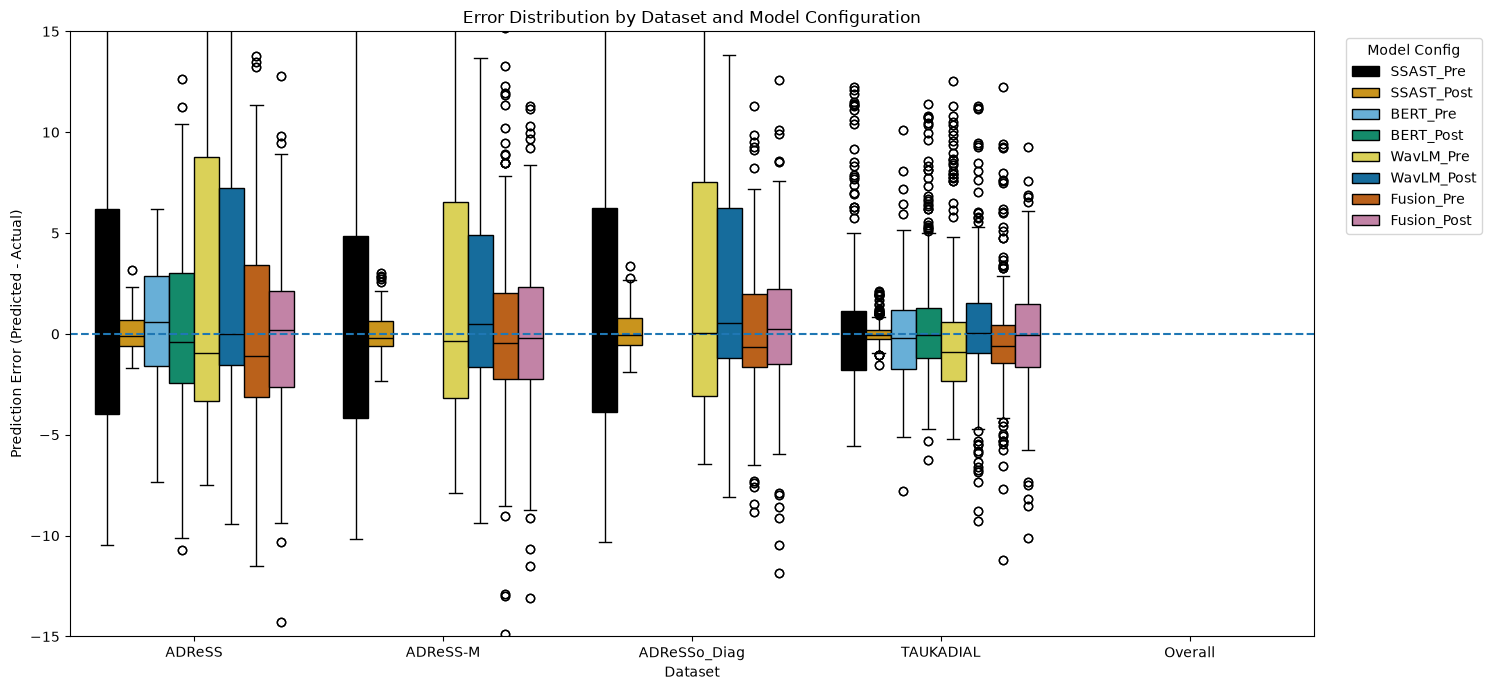

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


ssast_pre  = pd.read_csv(ROOT_DATA_PATH / "ssast-k5-huber-v4" / "ast_k5_predictions.csv")
bert_pre   = pd.read_csv(ROOT_DATA_PATH / "mmbert-k5-huber-v4" / "mmbert_k5_predictions.csv")
wavlm_pre  = pd.read_csv(ROOT_DATA_PATH / "wavlm-k5-clean-v5" / "wavlm_k5_predictions.csv")
fusion_pre = pd.read_csv(ROOT_DATA_PATH / "fusion-pre-hpo" / "fusion_pre_predictions.csv")


ssast_post  = pd.read_csv(ROOT_DATA_PATH / "ssast-k5-smart-hpo" / "ssast_final_predictions.csv")
bert_post   = pd.read_csv(ROOT_DATA_PATH / "bert-k5-smart-hpo" / "bert_final_predictions.csv")
wavlm_post  = pd.read_csv(ROOT_DATA_PATH / "wavlm-k5-smart-hpo" / "wavlm_final_predictions.csv")
fusion_post = pd.read_csv(ROOT_DATA_PATH / "fusion-smart-hpo" / "fusion_final_predictions.csv")


ssast_pre  = ssast_pre.rename(columns={"pred_audio":"y_pred","label":"y_true"})
bert_pre   = bert_pre.rename(columns={"pred_text":"y_pred","label":"y_true"})
wavlm_pre  = wavlm_pre.rename(columns={"pred_wavlm":"y_pred","label":"y_true"})
fusion_pre = fusion_pre.rename(columns={"label":"y_true"})

def clean(df):
    return df[["speaker_id","y_true","y_pred"]]

ssast_pre  = clean(ssast_pre)
bert_pre   = clean(bert_pre)
wavlm_pre  = clean(wavlm_pre)
fusion_pre = clean(fusion_pre)

ssast_post  = clean(ssast_post)
bert_post   = clean(bert_post)
wavlm_post  = clean(wavlm_post)
fusion_post = clean(fusion_post)

meta = labeled_norm.to_pandas()[["speaker_id","dataset"]]

def attach(df, model, phase):
    df = df.merge(meta, on="speaker_id", how="left")
    df["model"] = model
    df["phase"] = phase
    df["model_config"] = model + "_" + phase
    df["error"] = df["y_pred"] - df["y_true"]
    return df

dfs = []
dfs.append(attach(ssast_pre,  "SSAST",  "Pre"))
dfs.append(attach(ssast_post, "SSAST",  "Post"))
dfs.append(attach(bert_pre,   "BERT",   "Pre"))
dfs.append(attach(bert_post,  "BERT",   "Post"))
dfs.append(attach(wavlm_pre,  "WavLM",  "Pre"))
dfs.append(attach(wavlm_post, "WavLM",  "Post"))
dfs.append(attach(fusion_pre,  "Fusion", "Pre"))
dfs.append(attach(fusion_post, "Fusion", "Post"))

df_all = pd.concat(dfs, ignore_index=True)

df_overall = df_all.copy()
df_overall["language"] = "Overall"

df_plot = pd.concat([df_all, df_overall], ignore_index=True)


okabe_ito = [
    "#000000",
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7"
]

model_order = [
    "SSAST_Pre", "SSAST_Post",
    "BERT_Pre", "BERT_Post",
    "WavLM_Pre", "WavLM_Post",
    "Fusion_Pre", "Fusion_Post"
]

dataset_order = ["ADReSS", "ADReSS-M", "ADReSSo_Diag", "TAUKADIAL", "Overall"]

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df_plot,
    x="dataset",
    y="error",
    hue="model_config",
    order=dataset_order,
    hue_order=model_order,
    palette=okabe_ito,
    linewidth=1
)

plt.axhline(0, linestyle="--")
plt.ylim(-15, 15)
plt.xlabel("Dataset")
plt.ylabel("Prediction Error (Predicted - Actual)")
plt.title("Error Distribution by Dataset and Model Configuration")
plt.legend(title="Model Config", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

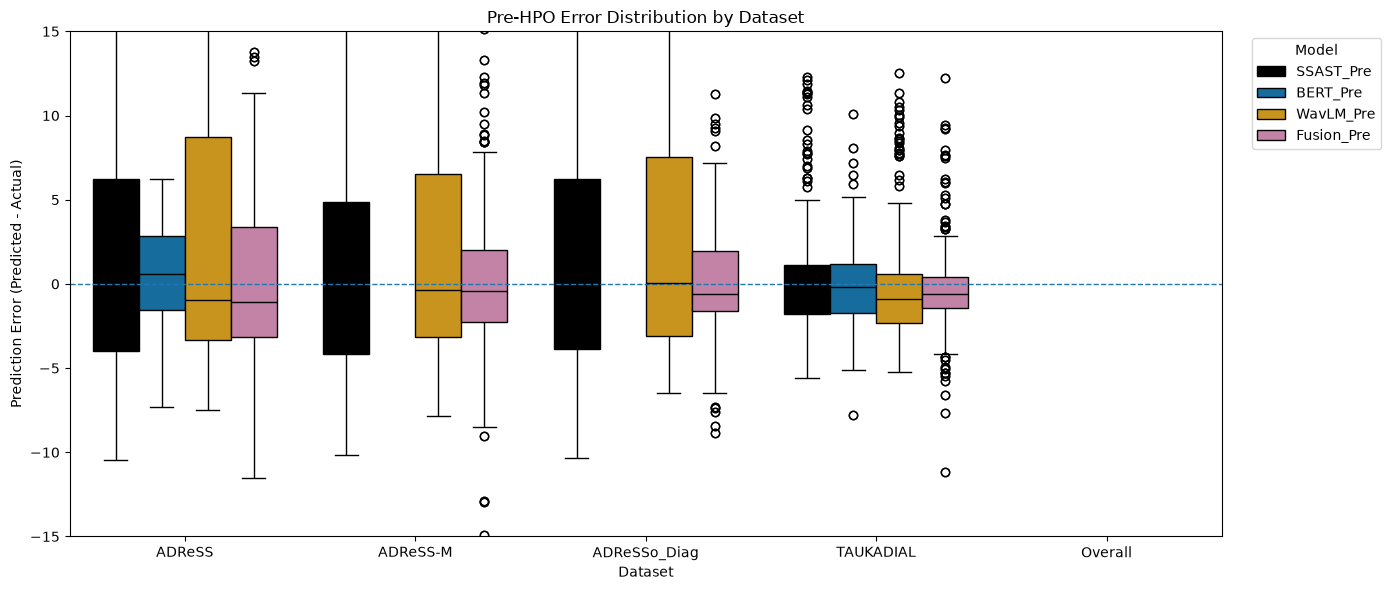

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


df_pre = df_plot[df_plot["phase"] == "Pre"].copy()

dataset_order = ["ADReSS", "ADReSS-M", "ADReSSo_Diag", "TAUKADIAL", "Overall"]
model_order = ["SSAST_Pre", "BERT_Pre", "WavLM_Pre", "Fusion_Pre"]


palette_pre = {
    "SSAST_Pre": "#000000",
    "BERT_Pre": "#0072B2",
    "WavLM_Pre": "#E69F00",
    "Fusion_Pre": "#CC79A7",
}

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_pre,
    x="dataset",
    y="error",
    hue="model_config",
    order=dataset_order,
    hue_order=model_order,
    palette=palette_pre,
    linewidth=1
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylim(-15, 15)
plt.title("Pre-HPO Error Distribution by Dataset")
plt.ylabel("Prediction Error (Predicted - Actual)")
plt.xlabel("Dataset")
plt.legend(title="Model", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

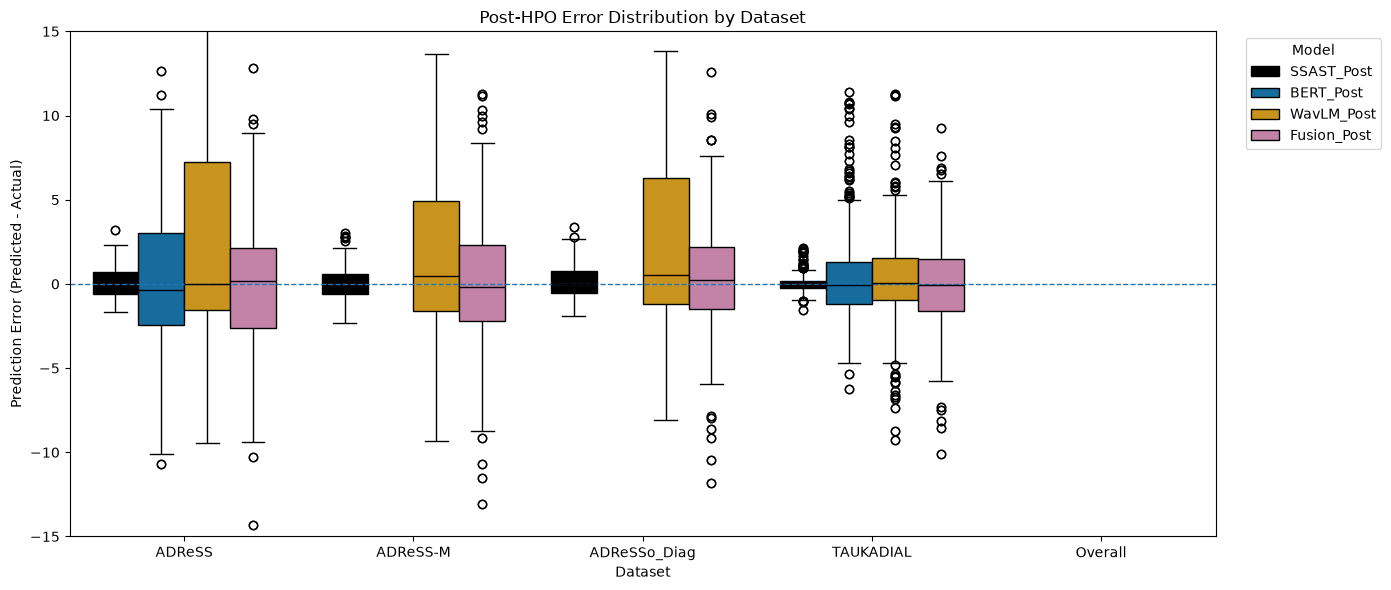

In [ ]:
df_post = df_plot[df_plot["phase"] == "Post"].copy()

model_order_post = ["SSAST_Post", "BERT_Post", "WavLM_Post", "Fusion_Post"]

palette_post = {
    "SSAST_Post": "#000000",
    "BERT_Post": "#0072B2",
    "WavLM_Post": "#E69F00",
    "Fusion_Post": "#CC79A7",
}

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_post,
    x="dataset",
    y="error",
    hue="model_config",
    order=dataset_order,
    hue_order=model_order_post,
    palette=palette_post,
    linewidth=1
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylim(-15, 15)
plt.title("Post-HPO Error Distribution by Dataset")
plt.ylabel("Prediction Error (Predicted - Actual)")
plt.xlabel("Dataset")
plt.legend(title="Model", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

Concat Fusion

In [ ]:
import pandas as pd

# Load the three model prediction files
df_text  = pd.read_csv(ROOT_DATA_PATH / "mmbert-k5-huber-v4" / "mmbert_k5_predictions.csv")
df_audio = pd.read_csv(ROOT_DATA_PATH / "ssast-k5-huber-v4" / "ast_k5_predictions.csv")
df_wavlm = pd.read_csv(ROOT_DATA_PATH / "wavlm-k5-clean-v5" / "wavlm_k5_predictions.csv")

# Merge on speaker_id keeping only common samples
df_common = (
    df_text[["speaker_id", "label", "pred_text"]]
    .merge(df_audio[["speaker_id", "pred_audio"]], on="speaker_id", how="inner")
    .merge(df_wavlm[["speaker_id", "pred_wavlm"]], on="speaker_id", how="inner")
)

print("Common samples:", len(df_common))
print("Columns:", df_common.columns.tolist())

# Save it where Cell 64 expects it
df_common.to_csv(ROOT_DATA_PATH / "fusion_stepA_common_samples.csv", index=False)
print("Saved fusion_stepA_common_samples.csv")

Common samples: 98
Columns: ['speaker_id', 'label', 'pred_text', 'pred_audio', 'pred_wavlm']
Saved fusion_stepA_common_samples.csv


In [ ]:
import torch
from transformers import (
    AutoModelForAudioClassification,
    AutoFeatureExtractor,
    AutoTokenizer,
    AutoModelForSequenceClassification
)

#AST
feature_extractor = AutoFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)
AST_CHECKPOINT = str(ROOT_DATA_PATH / "ssast-k5-huber-v4/fold-01-final-v4")

ast_model = AutoModelForAudioClassification.from_pretrained(
    AST_CHECKPOINT,
    local_files_only=True
)


#ModernBERT
tokenizer = AutoTokenizer.from_pretrained(
    "jhu-clsp/mmBERT-base"
)

TEXT_CHECKPOINT = str(ROOT_DATA_PATH / "mmbert-k5-huber-v4/fold-05-final")
text_model = AutoModelForSequenceClassification.from_pretrained(
    TEXT_CHECKPOINT,
    local_files_only=True
)

print("✅ AST and ModernBERT models loaded")


Loading weights: 100%|██████████| 138/138 [00:00<00:00, 11772.65it/s]

✅ AST and ModernBERT models loaded


In [ ]:
import pandas as pd
from pathlib import Path

FUSION_CSV = ROOT_DATA_PATH / "fusion_stepA_common_samples.csv"
df_base = pd.read_csv(FUSION_CSV)

print("Loaded base fusion:", df_base.shape)
print("Columns:", df_base.columns.tolist())

# Load manifests to attach text + audio paths
manifest_folder_path = ROOT_DATA_PATH / 'Manifest_Files'
train_file = manifest_folder_path / 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path / 'combined_multilingual_validation_manifest.csv'

manifest_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

need = {"speaker_id", "audio_filepath", "text"}
missing = need - set(manifest_df.columns)
if missing:
    raise ValueError(f"Manifest missing columns {missing}. Found: {manifest_df.columns.tolist()}")

# Merge
df_fusion = df_base.merge(
    manifest_df[["speaker_id", "audio_filepath", "text", "language"]],
    on="speaker_id",
    how="left"
)

print("After merge:", df_fusion.shape)
print("Columns after merge:", df_fusion.columns.tolist())
print("Missing audio_filepath:", df_fusion["audio_filepath"].isna().sum())
print("Missing text:", df_fusion["text"].isna().sum())

if "language" not in df_fusion.columns:
    lang_cols = [c for c in df_fusion.columns if c.startswith("language")]
    print("Found language-like columns:", lang_cols)
    if "language_x" in df_fusion.columns:
        df_fusion["language"] = df_fusion["language_x"]
    elif "language_y" in df_fusion.columns:
        df_fusion["language"] = df_fusion["language_y"]
    else:
        df_fusion["language"] = df_fusion[lang_cols[0]]

if "label" not in df_fusion.columns:
    if "label_text" in df_fusion.columns:
        df_fusion["label"] = df_fusion["label_text"]
    else:
        raise ValueError("No label column found.")

df_fusion = df_fusion[["speaker_id", "label", "language", "audio_filepath", "text"]].copy()

print("Final df_fusion:", df_fusion.shape)
df_fusion.head()


Loaded base fusion: (98, 5)
Columns: ['speaker_id', 'label', 'pred_text', 'pred_audio', 'pred_wavlm']
After merge: (98, 8)
Columns after merge: ['speaker_id', 'label', 'pred_text', 'pred_audio', 'pred_wavlm', 'audio_filepath', 'text', 'language']
Missing audio_filepath: 0
Missing text: 0
Final df_fusion: (98, 5)


,speaker_id,label,language,audio_filepath,text
0,TAUKADIAL__taukdial-156-2,30.0,Mandarin,/home/abl-station1/Desktop/speech_analysis_tak...,公園啊 公園那個老人家在下棋 泡茶下棋 小朋友在打羽毛球 這個小男生的遛狗 還有的小朋友在盪...
1,TAUKADIAL__taukdial-053-3,27.0,Mandarin,/home/abl-station1/Desktop/speech_analysis_tak...,這老爸在燙衣服吧 小鬼去拉這個插頭 不曉得是不是小鬼觸電了 然後那狗在 狗不要在那邊追他幹嘛...
2,TAUKADIAL__taukdial-141-2,30.0,Mandarin,/home/abl-station1/Desktop/speech_analysis_tak...,這個圖片環境是在一個公園內 有盪鞦韆 有溜滑梯 有椅子 還有一個涼亭 一對有一個一組兩人組的...
3,TAUKADIAL__taukdial-088-3,30.0,Mandarin,/home/abl-station1/Desktop/speech_analysis_tak...,"好,看起來我們有一個忙碌的媽媽 在洗碗的時候 她的孩子們正在進入烘焙瓶裡 可能會傷害自己 因..."
4,TAUKADIAL__taukdial-127-3,30.0,Mandarin,/home/abl-station1/Desktop/speech_analysis_tak...,有一個爸爸 他自己獨自帶小孩 然後家裡呢 就有兩隻寵物 一隻狗一隻貓 然後這個爸爸他正在 燙...


In [ ]:
import soundfile as sf
import torchaudio
import torch
from torch.utils.data import Dataset, DataLoader

class FusionDataset(Dataset):
    def __init__(self, df, tokenizer, feature_extractor, max_len=256):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.feat = feature_extractor
        self.max_len = max_len
        self.target_sr = feature_extractor.sampling_rate

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # TEXT (NO padding here)
        text_inputs = self.tokenizer(
            str(row["text"]),
            truncation=True,
            max_length=self.max_len,
            return_tensors=None,
        )

        # AUDIO
        wav, sr = sf.read(row["audio_filepath"])
        if wav.ndim > 1:
            wav = wav.mean(axis=1)

        wav = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
        if sr != self.target_sr:
            wav = torchaudio.functional.resample(wav, sr, self.target_sr)

        # feature_extractor expects numpy 1D arrays
        audio_inputs = self.feat(
            wav.squeeze(0).numpy(),
            sampling_rate=self.target_sr,
            return_tensors="pt",
        )

        return {
            "text_inputs": text_inputs,
            "audio_inputs": {k: v.squeeze(0) for k, v in audio_inputs.items()},
            "label": float(row["label"]),
            "speaker_id": row["speaker_id"],
            "language": row["language"],
        }

def fusion_collate(batch):
    # TEXT pad dynamically
    texts = [b["text_inputs"] for b in batch]
    text_inputs = tokenizer.pad(
        texts,
        padding=True,
        return_tensors="pt"
    )

    # AUDIO stack
    audio_inputs = {
        k: torch.stack([b["audio_inputs"][k] for b in batch])
        for k in batch[0]["audio_inputs"]
    }

    labels = torch.tensor([b["label"] for b in batch], dtype=torch.float32)
    speaker_ids = [b["speaker_id"] for b in batch]
    languages = [b["language"] for b in batch]

    return {
        "text_inputs": text_inputs,
        "audio_inputs": audio_inputs,
        "label": labels,
        "speaker_id": speaker_ids,
        "language": languages
    }

fusion_dataset = FusionDataset(df_fusion, tokenizer, feature_extractor, max_len=256)

fusion_loader = DataLoader(
    fusion_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=fusion_collate,
    num_workers=0
)

print("Fusion DataLoader ready | batches:", len(fusion_loader))

Fusion DataLoader ready | batches: 49


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import gc
import torch

rows = []
ast_model.to(device).eval()
text_model.to(device).eval()

with torch.inference_mode():
    for batch in tqdm(fusion_loader, desc="Extracting embeddings (AST + Text)"):
        audio_inputs = {k: v.to(device) for k, v in batch["audio_inputs"].items()}

        ast_out = ast_model(**audio_inputs, output_hidden_states=True, return_dict=True)

        if hasattr(ast_out, "pooler_output") and ast_out.pooler_output is not None:
            audio_emb = ast_out.pooler_output
        elif hasattr(ast_out, "hidden_states") and len(ast_out.hidden_states) > 0:
            audio_emb = ast_out.hidden_states[-1][:, 0, :]
        else:
            raise AttributeError("Could not extract audio embeddings from AST model output.")

        text_inputs = {k: v.to(device) for k, v in batch["text_inputs"].items()}

        txt_out = text_model(**text_inputs, output_hidden_states=True, return_dict=True)

        if hasattr(txt_out, "pooler_output") and txt_out.pooler_output is not None:
            text_emb = txt_out.pooler_output
        elif hasattr(txt_out, "hidden_states") and len(txt_out.hidden_states) > 0:
            text_emb = txt_out.hidden_states[-1][:, 0, :]
        else:
            raise AttributeError("Could not extract text embeddings from ModernBERT model output.")

        audio_emb = audio_emb.float().cpu().numpy()
        text_emb  = text_emb.float().cpu().numpy()

        labels = batch["label"].cpu().numpy()
        speaker_ids = batch["speaker_id"]
        langs = batch["language"]

        for i in range(len(speaker_ids)):
            rows.append({
                "speaker_id": speaker_ids[i],
                "language": langs[i],
                "label": float(labels[i]),
                "audio_emb": audio_emb[i],
                "text_emb": text_emb[i],
            })

        del audio_inputs, text_inputs, ast_out, txt_out, audio_emb, text_emb
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

df_emb = pd.DataFrame(rows)
print("Extracted embeddings:", df_emb.shape)
print("Emb sizes:", len(df_emb.iloc[0]["audio_emb"]), len(df_emb.iloc[0]["text_emb"]))

Extracting embeddings (AST + Text): 100%|██████████| 49/49 [00:20<00:00,  2.42it/s]

Extracted embeddings: (98, 5)
Emb sizes: 384 768


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

X_audio = np.stack(df_emb["audio_emb"].values)
X_text  = np.stack(df_emb["text_emb"].values)
y       = df_emb["label"].values.astype(float)

# CONCAT FUSION FEATURES
X_concat = np.concatenate([X_audio, X_text], axis=1)
print("X_concat shape:", X_concat.shape)

# Save features
OUT_DIR = ROOT_DATA_PATH / "concat_fusion"
OUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUT_DIR / "X_concat.npy", X_concat)
np.save(OUT_DIR / "y.npy", y)
df_emb[["speaker_id", "language"]].to_csv(OUT_DIR / "meta.csv", index=False)

print("Saved:")
print(" -", OUT_DIR / "X_concat.npy")
print(" -", OUT_DIR / "y.npy")
print(" -", OUT_DIR / "meta.csv")


X_concat shape: (98, 1152)
Saved:
 - /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/concat_fusion/X_concat.npy
 - /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/concat_fusion/y.npy
 - /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/concat_fusion/meta.csv


DEVICE: cuda
X: (98, 1152) y: (98,)

=== Fold 1/5 ===
Fold RMSE: 5.1715

=== Fold 2/5 ===
Fold RMSE: 3.8712

=== Fold 3/5 ===
Fold RMSE: 4.7994

=== Fold 4/5 ===
Fold RMSE: 5.4803

=== Fold 5/5 ===
Fold RMSE: 4.0790

=== CONCAT FUSION (MLP + Huber) RESULTS ===
Fold RMSE mean: 4.680267184730768
Fold RMSE std : 0.6183340600599184
OOF RMSE      : 4.718669562254189
OOF MAE       : 3.5461463928222656
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/concat-mlp-k5-huber


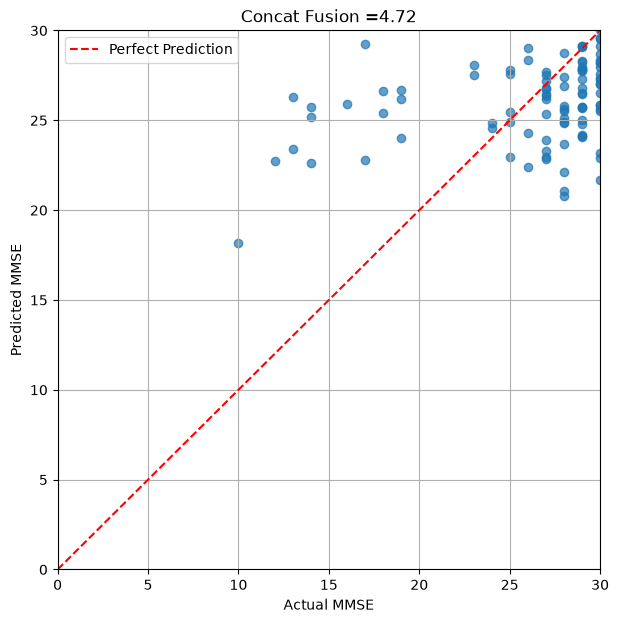

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
from pathlib import Path
import gc

SEED = 42
N_SPLITS = 5

BATCH = 64 if torch.cuda.is_available() else 32
EPOCHS = 40
PATIENCE = 7

LR = 2e-4
WEIGHT_DECAY = 1e-2
HIDDEN = 512
DROPOUT = 0.25

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

torch.manual_seed(SEED)
np.random.seed(SEED)

OUT_DIR = ROOT_DATA_PATH / "concat_fusion"
X = np.load(OUT_DIR / "X_concat.npy")
y = np.load(OUT_DIR / "y.npy").astype(np.float32)
meta = pd.read_csv(OUT_DIR / "meta.csv")

groups = meta["speaker_id"].astype(str).values
languages = meta["language"].values

print("X:", X.shape, "y:", y.shape)

class NpDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class ConcatMLP(nn.Module):
    def __init__(self, in_dim, hidden=512, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def train_one_fold(model, train_loader, val_loader):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    loss_fn = nn.SmoothL1Loss(beta=1.0)

    best_rmse = float("inf")
    best_state = None
    bad = 0

    for epoch in range(1, EPOCHS + 1):

        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        #validate
        model.eval()
        preds_all, ys_all = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                preds = model(xb).cpu().numpy()
                preds_all.append(preds)
                ys_all.append(yb.numpy())

        preds_all = np.concatenate(preds_all)
        ys_all = np.concatenate(ys_all)

        val_rmse = rmse(ys_all, preds_all)

        if val_rmse < best_rmse - 1e-4:
            best_rmse = val_rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_rmse

#training
gkf = GroupKFold(n_splits=N_SPLITS)

oof_pred = np.zeros_like(y, dtype=np.float32)
fold_rmses = []

for fold, (tr, va) in enumerate(gkf.split(X, y, groups=groups), start=1):
    print(f"\n=== Fold {fold}/{N_SPLITS} ===")

    train_ds = NpDataset(X[tr], y[tr])
    val_ds   = NpDataset(X[va], y[va])

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False)

    model = ConcatMLP(
        in_dim=X.shape[1],
        hidden=HIDDEN,
        dropout=DROPOUT
    ).to(DEVICE)

    best_rmse = train_one_fold(model, train_loader, val_loader)
    fold_rmses.append(best_rmse)

    # OOF predictions
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(DEVICE)
            preds.append(model(xb).cpu().numpy())
    preds = np.concatenate(preds)

    oof_pred[va] = preds
    print(f"Fold RMSE: {best_rmse:.4f}")

    del model
    torch.cuda.empty_cache()
    gc.collect()

#FINAL METRICS
oof_rmse = rmse(y, oof_pred)
oof_mae  = mae(y, oof_pred)

print("\n=== CONCAT FUSION (MLP + Huber) RESULTS ===")
print("Fold RMSE mean:", float(np.mean(fold_rmses)))
print("Fold RMSE std :", float(np.std(fold_rmses)))
print("OOF RMSE      :", oof_rmse)
print("OOF MAE       :", oof_mae)

# SAVE OUTPUTS
SAVE_DIR = ROOT_DATA_PATH / "concat-mlp-k5-huber"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

df_out = pd.DataFrame({
    "speaker_id": groups,
    "language": languages,
    "label": y,
    "pred_concat": oof_pred,
})

df_out.to_csv(SAVE_DIR / "concat_mlp_k5_predictions.csv", index=False)
pd.DataFrame({"fold": list(range(1, N_SPLITS + 1)), "rmse": fold_rmses}) \
  .to_csv(SAVE_DIR / "concat_mlp_k5_fold_rmse.csv", index=False)

print("Saved to:", SAVE_DIR)

# SCATTER PLOT
plt.figure(figsize=(7,7))
plt.scatter(y, np.clip(oof_pred, 0, 30), alpha=0.7)
plt.plot([0, 30], [0, 30], "r--", label="Perfect Prediction")
plt.xlim(0, 30)
plt.ylim(0, 30)
plt.grid(True)
plt.xlabel("Actual MMSE")
plt.ylabel("Predicted MMSE")
plt.title(f"Concat Fusion ={oof_rmse:.2f}")
plt.legend()
plt.show()


MLP + GATED fusion

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLPEncoder(nn.Module):
    def __init__(self, in_dim: int, hid_dim: int, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hid_dim, hid_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class GatedFusionRegressor(nn.Module):
    def __init__(
        self,
        text_in_dim: int,
        audio_in_dim: int,
        hid_dim: int = 256,
        dropout: float = 0.2,
        gate_hidden: int = 128,
    ):
        super().__init__()
        self.text_enc = MLPEncoder(text_in_dim, hid_dim, dropout)
        self.audio_enc = MLPEncoder(audio_in_dim, hid_dim, dropout)

        self.gate = nn.Sequential(
            nn.Linear(2 * hid_dim, gate_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(gate_hidden, hid_dim),
            nn.Sigmoid(),
        )

        self.head = nn.Sequential(
            nn.Linear(hid_dim, hid_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hid_dim // 2, 1),
        )

    def forward(self, x_text, x_audio):
        ht = self.text_enc(x_text)
        ha = self.audio_enc(x_audio)
        g = self.gate(torch.cat([ht, ha], dim=-1))
        h = g * ht + (1.0 - g) * ha
        yhat = self.head(h).squeeze(-1)
        return yhat, g


In [ ]:
def gate_regularizer(g, strength=1e-3):
    return strength * ((g - 0.5) ** 2).mean()

In [ ]:
from torch.utils.data import DataLoader

def train_one_epoch(model, loader, optimizer, device, loss_type="l1", gate_reg=0.0, mod_drop_p=0.0):
    model.train()
    total_loss = 0.0

    for batch in loader:
        x_text = batch["x_text"].to(device)
        x_audio = batch["x_audio"].to(device)
        y = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        # optional modality dropout
        if mod_drop_p > 0.0:
            if torch.rand(1).item() < mod_drop_p:
                x_text = torch.zeros_like(x_text)
            if torch.rand(1).item() < mod_drop_p:
                x_audio = torch.zeros_like(x_audio)

        yhat, g = model(x_text, x_audio)

        if loss_type == "mse":
            loss = F.mse_loss(yhat, y)
        else:
            loss = F.l1_loss(yhat, y)

        if gate_reg > 0:
            loss = loss + gate_regularizer(g, strength=gate_reg)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_rmse(model, loader, device):
    model.eval()
    ys, preds = [], []
    for batch in loader:
        x_text = batch["x_text"].to(device)
        x_audio = batch["x_audio"].to(device)
        y = batch["y"].to(device).float()

        yhat, _ = model(x_text, x_audio)
        ys.append(y.cpu())
        preds.append(yhat.cpu())

    ys = torch.cat(ys).numpy()
    preds = torch.cat(preds).numpy()
    rmse = float(((ys - preds) ** 2).mean() ** 0.5)
    return rmse



=== Fold 1/5 ===
Fold RMSE: 4.6557

=== Fold 2/5 ===
Fold RMSE: 4.1578

=== Fold 3/5 ===
Fold RMSE: 4.8627

=== Fold 4/5 ===
Fold RMSE: 5.4966

=== Fold 5/5 ===
Fold RMSE: 4.1500

=== GATED FUSION RESULTS ===
Mean RMSE: 4.664561529007594
Std  RMSE: 0.5006227547915014
OOF RMSE : 4.687631223749173
OOF MAE  : 3.605893135070801


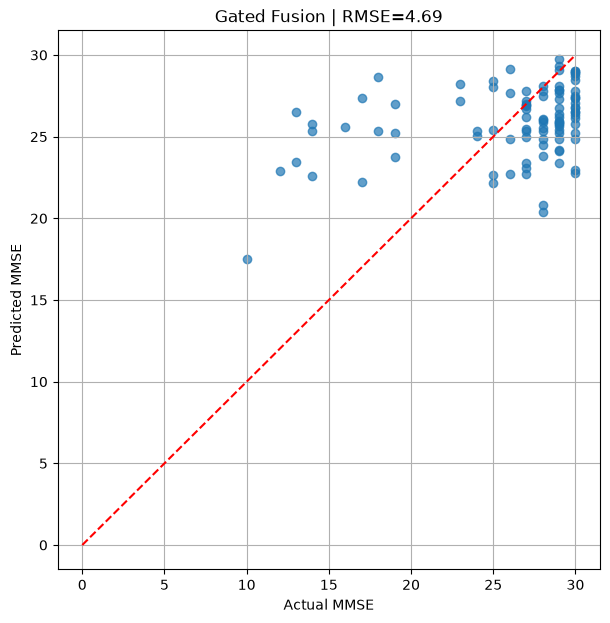

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import gc
from pathlib import Path

SEED = 42
N_SPLITS = 5

BATCH = 64 if torch.cuda.is_available() else 32
EPOCHS = 40
PATIENCE = 7

LR = 2e-4
WEIGHT_DECAY = 1e-2
HIDDEN = 512
DROPOUT = 0.25

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

# LOAD EMBEDDINGS
OUT_DIR = ROOT_DATA_PATH / "concat_fusion"
X_audio = np.load(OUT_DIR / "X_concat.npy")[:, :768]
X_text  = np.load(OUT_DIR / "X_concat.npy")[:, 768:]
y = np.load(OUT_DIR / "y.npy").astype(np.float32)
meta = pd.read_csv(OUT_DIR / "meta.csv")

groups = meta["speaker_id"].astype(str).values
languages = meta["language"].values

class FusionDataset(Dataset):
    def __init__(self, Xa, Xt, y):
        self.Xa = torch.from_numpy(Xa).float()
        self.Xt = torch.from_numpy(Xt).float()
        self.y  = torch.from_numpy(y).float()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.Xa[i], self.Xt[i], self.y[i]

# MODEL
class GatedFusionMLP(nn.Module):
    def __init__(self, audio_dim=768, text_dim=384, hidden=512, dropout=0.25):
        super().__init__()

        self.audio_proj = nn.Sequential(
            nn.LayerNorm(audio_dim),
            nn.Linear(audio_dim, hidden),
            nn.GELU()
        )
        self.text_proj = nn.Sequential(
            nn.LayerNorm(text_dim),
            nn.Linear(text_dim, hidden),
            nn.GELU()
        )
        self.gate = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.Sigmoid()
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, xa, xt):
        ha = self.audio_proj(xa)
        ht = self.text_proj(xt)
        g  = self.gate(torch.cat([ha, ht], dim=1))
        h  = g * ha + (1 - g) * ht
        return self.head(h).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def train_one_fold(model, tr_loader, va_loader):
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    best_rmse, bad = float("inf"), 0
    best_state = None

    for _ in range(EPOCHS):
        model.train()
        for xa, xt, yb in tr_loader:
            xa, xt, yb = xa.to(DEVICE), xt.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xa, xt), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        preds, ys = [], []
        with torch.no_grad():
            for xa, xt, yb in va_loader:
                xa, xt = xa.to(DEVICE), xt.to(DEVICE)
                preds.append(model(xa, xt).cpu().numpy())
                ys.append(yb.numpy())

        preds = np.concatenate(preds)
        ys = np.concatenate(ys)
        val_rmse = rmse(ys, preds)

        if val_rmse < best_rmse - 1e-4:
            best_rmse = val_rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return best_rmse

gkf = GroupKFold(n_splits=N_SPLITS)
oof_pred = np.zeros_like(y)
fold_rmses = []

for fold, (tr, va) in enumerate(gkf.split(X_audio, y, groups=groups), 1):
    print(f"\n=== Fold {fold}/{N_SPLITS} ===")

    tr_ds = FusionDataset(X_audio[tr], X_text[tr], y[tr])
    va_ds = FusionDataset(X_audio[va], X_text[va], y[va])

    tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH, shuffle=False)

    model = GatedFusionMLP(audio_dim=768, text_dim=384).to(DEVICE)
    best_rmse = train_one_fold(model, tr_loader, va_loader)
    fold_rmses.append(best_rmse)

    model.eval()
    with torch.no_grad():
        preds = []
        for xa, xt, _ in va_loader:
            preds.append(model(xa.to(DEVICE), xt.to(DEVICE)).cpu().numpy())
    oof_pred[va] = np.concatenate(preds)

    print(f"Fold RMSE: {best_rmse:.4f}")

    del model
    torch.cuda.empty_cache()
    gc.collect()


print("\n=== GATED FUSION RESULTS ===")
print("Mean RMSE:", np.mean(fold_rmses))
print("Std  RMSE:", np.std(fold_rmses))
print("OOF RMSE :", rmse(y, oof_pred))
print("OOF MAE  :", mae(y, oof_pred))


SAVE_DIR = ROOT_DATA_PATH / "gated-mlp-k5-huber"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "speaker_id": groups,
    "language": languages,
    "label": y,
    "pred_gated": oof_pred
}).to_csv(SAVE_DIR / "gated_k5_predictions.csv", index=False)

plt.figure(figsize=(7,7))
plt.scatter(y, np.clip(oof_pred, 0, 30), alpha=0.7)
plt.plot([0,30],[0,30],'r--')
plt.xlabel("Actual MMSE")
plt.ylabel("Predicted MMSE")
plt.title(f"Gated Fusion | RMSE={rmse(y,oof_pred):.2f}")
plt.grid(True)
plt.show()


Cross-Attention fusion


=== Fold 1/5 ===
Fold RMSE: 7.7857

=== Fold 2/5 ===
Fold RMSE: 10.9280

=== Fold 3/5 ===
Fold RMSE: 10.8936

=== Fold 4/5 ===
Fold RMSE: 10.8684

=== Fold 5/5 ===
Fold RMSE: 12.8652

=== CROSS-ATTENTION RESULTS ===
Mean RMSE: 10.668190478741268
Std  RMSE: 1.630572624900651
OOF RMSE : 10.768088447853723
OOF MAE  : 10.016792297363281


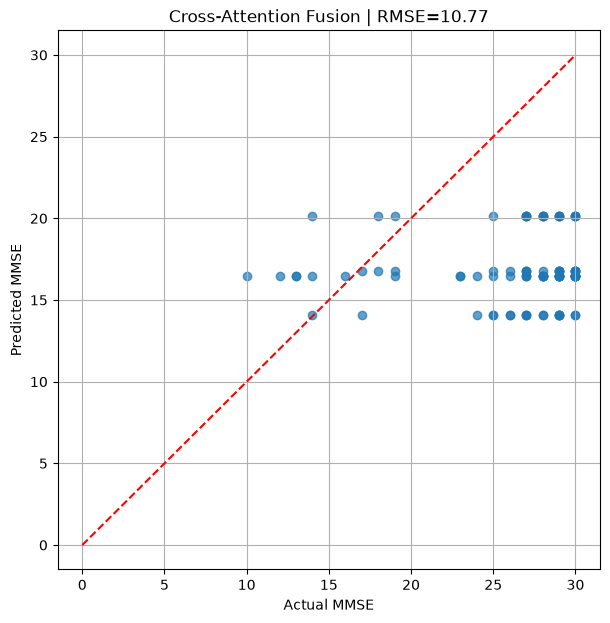

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import gc
from pathlib import Path



SEED = 42
N_SPLITS = 5

BATCH = 64 if torch.cuda.is_available() else 32
EPOCHS = 40
PATIENCE = 7

LR = 2e-4
WEIGHT_DECAY = 1e-2
HIDDEN = 256
DROPOUT = 0.25
N_HEADS = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)


OUT_DIR = ROOT_DATA_PATH / "concat_fusion"
X_concat = np.load(OUT_DIR / "X_concat.npy")
X_audio = X_concat[:, :768]
X_text  = X_concat[:, 768:]
y = np.load(OUT_DIR / "y.npy").astype(np.float32)
meta = pd.read_csv(OUT_DIR / "meta.csv")

groups = meta["speaker_id"].astype(str).values
languages = meta["language"].values


class FusionDataset(Dataset):
    def __init__(self, Xa, Xt, y):
        self.Xa = torch.from_numpy(Xa).float()
        self.Xt = torch.from_numpy(Xt).float()
        self.y  = torch.from_numpy(y).float()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.Xa[i], self.Xt[i], self.y[i]

class CrossAttentionFusion(nn.Module):
    def __init__(self, audio_dim=768, text_dim=384, hidden=256, heads=4, dropout=0.25):
        super().__init__()

        self.audio_proj = nn.Linear(audio_dim, hidden)
        self.text_proj  = nn.Linear(text_dim, hidden)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm = nn.LayerNorm(hidden)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, xa, xt):
        qa = self.audio_proj(xa).unsqueeze(1)
        kv = self.text_proj(xt).unsqueeze(1)

        attn_out, _ = self.cross_attn(qa, kv, kv)
        h = self.norm(attn_out.squeeze(1))
        return self.head(h).squeeze(-1)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def train_one_fold(model, tr_loader, va_loader):
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    best_rmse, bad = float("inf"), 0
    best_state = None

    for _ in range(EPOCHS):
        model.train()
        for xa, xt, yb in tr_loader:
            xa, xt, yb = xa.to(DEVICE), xt.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xa, xt), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        preds, ys = [], []
        with torch.no_grad():
            for xa, xt, yb in va_loader:
                xa, xt = xa.to(DEVICE), xt.to(DEVICE)
                preds.append(model(xa, xt).cpu().numpy())
                ys.append(yb.numpy())

        preds = np.concatenate(preds)
        ys = np.concatenate(ys)
        val_rmse = rmse(ys, preds)

        if val_rmse < best_rmse - 1e-4:
            best_rmse = val_rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return best_rmse

gkf = GroupKFold(n_splits=N_SPLITS)
oof_pred = np.zeros_like(y)
fold_rmses = []

for fold, (tr, va) in enumerate(gkf.split(X_audio, y, groups=groups), 1):
    print(f"\n=== Fold {fold}/{N_SPLITS} ===")

    tr_ds = FusionDataset(X_audio[tr], X_text[tr], y[tr])
    va_ds = FusionDataset(X_audio[va], X_text[va], y[va])

    tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH, shuffle=False)

    model = CrossAttentionFusion(
        audio_dim=768,
        text_dim=384,
        hidden=HIDDEN,
        heads=N_HEADS,
        dropout=DROPOUT
    ).to(DEVICE)

    best_rmse = train_one_fold(model, tr_loader, va_loader)
    fold_rmses.append(best_rmse)

    model.eval()
    with torch.no_grad():
        preds = []
        for xa, xt, _ in va_loader:
            preds.append(model(xa.to(DEVICE), xt.to(DEVICE)).cpu().numpy())
    oof_pred[va] = np.concatenate(preds)

    print(f"Fold RMSE: {best_rmse:.4f}")

    del model
    torch.cuda.empty_cache()
    gc.collect()

print("\n=== CROSS-ATTENTION RESULTS ===")
print("Mean RMSE:", np.mean(fold_rmses))
print("Std  RMSE:", np.std(fold_rmses))
print("OOF RMSE :", rmse(y, oof_pred))
print("OOF MAE  :", mae(y, oof_pred))

SAVE_DIR = ROOT_DATA_PATH / "cross-attn-k5-huber"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "speaker_id": groups,
    "language": languages,
    "label": y,
    "pred_cross_attn": oof_pred
}).to_csv(SAVE_DIR / "cross_attn_k5_predictions.csv", index=False)

plt.figure(figsize=(7,7))
plt.scatter(y, np.clip(oof_pred, 0, 30), alpha=0.7)
plt.plot([0,30],[0,30],'r--')
plt.xlabel("Actual MMSE")
plt.ylabel("Predicted MMSE")
plt.title(f"Cross-Attention Fusion | RMSE={rmse(y,oof_pred):.2f}")
plt.grid(True)
plt.show()


Late Fusion - mlp on predictions

In [ ]:
df_a = pd.read_csv(AST_PRED_PATH)
df_t = pd.read_csv(TEXT_PRED_PATH)

# Force speaker_id to string and average across folds
df_a["speaker_id"] = df_a["speaker_id"].astype(str).str.strip()
df_t["speaker_id"] = df_t["speaker_id"].astype(str).str.strip()

df_a = df_a.groupby("speaker_id", as_index=False).agg(
    label=("label", "first"),
    pred_audio=("pred_audio", "mean")
)

print("SSAST after averaging:", len(df_a))
print("mmBERT rows:", len(df_t))
print("Sample SSAST speaker_ids:", df_a["speaker_id"].head().tolist())
print("Sample mmBERT speaker_ids:", df_t["speaker_id"].head().tolist())

SSAST after averaging: 896
mmBERT rows: 98
Sample SSAST speaker_ids: ['ADReSS-M__adrso002', 'ADReSS-M__adrso003', 'ADReSS-M__adrso004', 'ADReSS-M__adrso005', 'ADReSS-M__adrso006']
Sample mmBERT speaker_ids: ['TAUKADIAL__taukdial-156-2', 'TAUKADIAL__taukdial-053-3', 'TAUKADIAL__taukdial-141-2', 'TAUKADIAL__taukdial-088-3', 'TAUKADIAL__taukdial-127-3']


FROZEN BACKBONE SCREEN

Audio Spectrogram Transformer family

SSAST after averaging: 896
mmBERT rows: 98
Late-fusion rows: 98

=== Fold 1/5 ===
Fold RMSE: 6.1932

=== Fold 2/5 ===
Fold RMSE: 13.8175

=== Fold 3/5 ===
Fold RMSE: 15.8200

=== Fold 4/5 ===
Fold RMSE: 17.9360

=== Fold 5/5 ===
Fold RMSE: 12.7877

=== LATE FUSION (MLP) RESULTS ===
Mean RMSE: 13.310891472076932
Std  RMSE: 3.9718861493421076
OOF RMSE : 13.854324469946366
OOF MAE  : 12.727458000183105


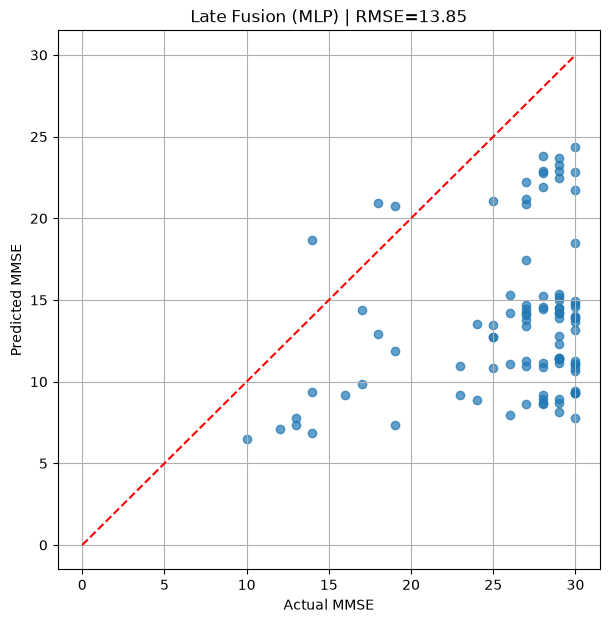

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from pathlib import Path
import gc

SEED = 42
N_SPLITS = 5

BATCH = 64 if torch.cuda.is_available() else 32
EPOCHS = 40
PATIENCE = 7

LR = 1e-3
WEIGHT_DECAY = 1e-3
HIDDEN = 16
DROPOUT = 0.2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

AST_PRED_PATH  = ROOT_DATA_PATH / "ssast-k5-huber-v4" / "ast_k5_predictions.csv"
TEXT_PRED_PATH = ROOT_DATA_PATH / "mmbert-k5-huber-v4" / "mmbert_k5_predictions.csv"

df_a = pd.read_csv(AST_PRED_PATH)
df_t = pd.read_csv(TEXT_PRED_PATH)


# (Edited)Average SSAST predictions across folds per speaker
df_a = df_a.groupby("speaker_id").agg(
    label=("label", "first"),
    pred_audio=("pred_audio", "mean")
).reset_index()

print("SSAST after averaging:", len(df_a))
print("mmBERT rows:", len(df_t))


# (Edited)sanity
# assert df_a["speaker_id"].nunique() == len(df_a)
# assert df_t["speaker_id"].nunique() == len(df_t)

# merge
df = df_a[["speaker_id", "label", "pred_audio"]].merge(
    df_t[["speaker_id", "pred_text"]],
    on="speaker_id",
    how="inner"
)

print("Late-fusion rows:", len(df))

X = df[["pred_audio", "pred_text"]].values.astype(np.float32)
y = df["label"].values.astype(np.float32)
groups = df["speaker_id"].astype(str).values

class PredDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

class LateFusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, HIDDEN),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def train_one_fold(model, tr_loader, va_loader):
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    best_rmse, bad = float("inf"), 0
    best_state = None

    for _ in range(EPOCHS):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        model.eval()
        preds, ys = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE)
                preds.append(model(xb).cpu().numpy())
                ys.append(yb.numpy())

        preds = np.concatenate(preds)
        ys = np.concatenate(ys)
        val_rmse = rmse(ys, preds)

        if val_rmse < best_rmse - 1e-4:
            best_rmse = val_rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return best_rmse

gkf = GroupKFold(n_splits=N_SPLITS)
oof_pred = np.zeros_like(y)
fold_rmses = []

for fold, (tr, va) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"\n=== Fold {fold}/{N_SPLITS} ===")

    tr_ds = PredDataset(X[tr], y[tr])
    va_ds = PredDataset(X[va], y[va])

    tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH, shuffle=False)

    model = LateFusionMLP().to(DEVICE)
    best_rmse = train_one_fold(model, tr_loader, va_loader)
    fold_rmses.append(best_rmse)

    model.eval()
    with torch.no_grad():
        preds = []
        for xb, _ in va_loader:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
    oof_pred[va] = np.concatenate(preds)

    print(f"Fold RMSE: {best_rmse:.4f}")

    del model
    torch.cuda.empty_cache()
    gc.collect()

print("\n=== LATE FUSION (MLP) RESULTS ===")
print("Mean RMSE:", np.mean(fold_rmses))
print("Std  RMSE:", np.std(fold_rmses))
print("OOF RMSE :", rmse(y, oof_pred))
print("OOF MAE  :", mae(y, oof_pred))

SAVE_DIR = ROOT_DATA_PATH / "late-fusion-mlp-k5-huber"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "speaker_id": groups,
    "label": y,
    "pred_late_mlp": oof_pred
}).to_csv(SAVE_DIR / "late_mlp_k5_predictions.csv", index=False)

plt.figure(figsize=(7,7))
plt.scatter(y, np.clip(oof_pred, 0, 30), alpha=0.7)
plt.plot([0,30],[0,30],'r--')
plt.xlabel("Actual MMSE")
plt.ylabel("Predicted MMSE")
plt.title(f"Late Fusion (MLP) | RMSE={rmse(y,oof_pred):.2f}")
plt.grid(True)
plt.show()


PaSST Stage A — Frozen Backbone Screen

run "ROOT_DATA_PATH...."

Install In Terminal: conda activate asr311
pip install 'git+https://github.com/kkoutini/passt_hear21@0.0.19#egg=hear21passt'

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import soundfile as sf
import torchaudio

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from torch.utils.data import DataLoader, Dataset

# pip install 'git+https://github.com/kkoutini/passt_hear21@0.0.19#egg=hear21passt'
from hear21passt.base import get_basic_model, get_scene_embeddings

import hear21passt.models.preprocess as _pp
import torch.nn.functional as F

def _patched_forward(self, x):
    x = F.conv1d(x.unsqueeze(1), self.preemphasis_coefficient).squeeze(1)
    x = torch.stft(
        x,
        self.n_fft,
        hop_length=self.hopsize,
        win_length=self.win_length,
        center=True,
        normalized=False,
        window=self.window,
        return_complex=True
    )
    x = x.abs() ** 2  # power magnitude from complex tensor
    fmin = self.fmin + torch.randint(self.fmin_aug_range, (1,)).item()
    fmax = self.fmax + self.fmax_aug_range // 2 - torch.randint(self.fmax_aug_range, (1,)).item()
    if not self.training:
        fmin = self.fmin
        fmax = self.fmax
    mel_basis, _ = torchaudio.compliance.kaldi.get_mel_banks(
        self.n_mels, self.n_fft, self.sr,
        fmin, fmax, vtln_low=100.0, vtln_high=-500., vtln_warp_factor=1.0
    )
    mel_basis = torch.as_tensor(
        F.pad(mel_basis, (0, 1), mode='constant', value=0),
        device=x.device
    )
    with torch.cuda.amp.autocast(enabled=False):
        melspec = torch.matmul(mel_basis, x)
    melspec = (melspec + 0.00001).log()
    if self.training:
        melspec = self.freqm(melspec)
        melspec = self.timem(melspec)
    melspec = (melspec + 4.5) / 5.
    return melspec

_pp.AugmentMelSTFT.forward = _patched_forward
print("PaSST STFT patch applied.")

SEED = 42
N_SPLITS = 5
BATCH = 16
MAX_SECONDS = 30
TARGET_SR = 32000  # PaSST expects 32kHz

torch.manual_seed(SEED)
np.random.seed(SEED)

PASST_OUT = ROOT_DATA_PATH / "passt-stage-a"
PASST_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = PASST_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("PaSST Stage A already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load PaSST frozen
passt_model = get_basic_model(mode="embed_only").to(device)
for p in passt_model.parameters():
    p.requires_grad = False
passt_model.eval()
print("PaSST loaded and frozen.")

# Load manifest
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)
# Build MMSE lookup from metadata files
all_meta = []

# ADReSS-2020
p = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(p/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(p/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]

# ADReSSo
p = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(p).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])

# ADReSS-M
p = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(p).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])

# TAUKADIAL
p = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(p)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()
print("MMSE lookup size:", len(mmse_lookup))

# Attach labels to manifest
def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df = full_df.dropna(subset=["label", "audio_filepath"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

# Extract embeddings
def extract_passt_embedding(audio_path):
    wav, sr = sf.read(audio_path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav_tensor = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
    if sr != TARGET_SR:
        wav_tensor = torchaudio.functional.resample(wav_tensor, sr, TARGET_SR)
    max_samples = MAX_SECONDS * TARGET_SR
    if wav_tensor.shape[-1] > max_samples:
        wav_tensor = wav_tensor[..., :max_samples]
    with torch.no_grad():
        emb = get_scene_embeddings(wav_tensor.to(device), passt_model)
    return emb.cpu().numpy().squeeze()

print("Extracting PaSST embeddings...")
embeddings = []
valid_idx = []
for i, row in full_df.iterrows():
    try:
        emb = extract_passt_embedding(row["audio_filepath"])
        embeddings.append(emb)
        valid_idx.append(i)
    except Exception as e:
        print(f"Failed: {row['speaker_id']} | {e}")

X = np.array(embeddings)
df_valid = full_df.iloc[valid_idx].reset_index(drop=True)
y = df_valid["label"].values.astype(np.float32)
groups = df_valid["speaker_id"].astype(str).values
datasets_col = df_valid["dataset"].values
print(f"Embeddings shape: {X.shape}")

# MLP head
class MLPHead(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# k-fold
gkf = GroupKFold(n_splits=N_SPLITS)
oof_preds = np.zeros_like(y)
fold_rmses = []
rows = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"\nFold {fold}/{N_SPLITS}")
    X_tr, X_va = X[tr_idx], X[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)

    model = MLPHead(input_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    for epoch in range(100):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_tr_t), y_tr_t)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_va_t).cpu().numpy()

    oof_preds[va_idx] = preds
    fold_rmse = rmse(y_va, preds)
    fold_rmses.append(fold_rmse)
    print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

    for sid, yt, yp, ds in zip(
        df_valid["speaker_id"].values[va_idx],
        y_va, preds,
        datasets_col[va_idx]
    ):
        rows.append({"fold": fold, "speaker_id": sid, "dataset": ds,
                     "label": float(yt), "pred_passt": float(yp)})

    del model
    torch.cuda.empty_cache()
    gc.collect()

# Per-corpus RMSE
df_preds = pd.DataFrame(rows)
print("\n=== PaSST Stage A — Overall OOF RMSE:", rmse(y, oof_preds))
print("\n=== Per-corpus RMSE ===")
for ds, grp in df_preds.groupby("dataset"):
    print(f"  {ds}: {rmse(grp['label'], grp['pred_passt']):.4f} (n={len(grp)})")

# Save
df_preds.to_csv(PASST_OUT / "passt_stage_a_predictions.csv", index=False)
pd.DataFrame({"fold": list(range(1, N_SPLITS+1)), "rmse": fold_rmses}).to_csv(
    PASST_OUT / "passt_stage_a_fold_rmse.csv", index=False)
np.save(PASST_OUT / "passt_embeddings.npy", X)
DONE_FLAG.write_text("done")

print("\nPaSST Stage A complete.")
print("Mean RMSE:", round(np.mean(fold_rmses), 4))
print("Saved to:", PASST_OUT.resolve())

PaSST STFT patch applied.


 Loading PASST TRAINED ON AUDISET 


PaSST(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
    (1): Block(
      (no

/tmp/ipykernel_2416808/1280186356.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/hear21passt/models/passt.py:284: UserWarning: Input image size (128*1000) doesn't match model (128*998).
  warnings.warn(f"Input image size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]}).")


Embeddings shape: (896, 768)

Fold 1/5
Fold 1 RMSE: 6.2199

Fold 2/5
Fold 2 RMSE: 5.3301

Fold 3/5
Fold 3 RMSE: 4.5468

Fold 4/5
Fold 4 RMSE: 5.0617

Fold 5/5
Fold 5 RMSE: 5.3944

=== PaSST Stage A — Overall OOF RMSE: 5.339438500476076

=== Per-corpus RMSE ===
  ADReSS: 6.9144 (n=107)
  ADReSS-M: 6.2184 (n=236)
  ADReSSo_Diag: 6.8275 (n=166)
  TAUKADIAL: 3.0352 (n=387)

PaSST Stage A complete.
Mean RMSE: 5.3106
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/passt-stage-a


BEATs Stage A — Frozen Backbone Screen

In [ ]:
import os, gc
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import soundfile as sf
import torchaudio

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# BEATs source files cloned from microsoft/unilm
BEATS_PATH = '/home/abl-station1/Desktop/speech_analysis_takeover/unilm/beats'
sys.path.append(BEATS_PATH)
from BEATs import BEATs, BEATsConfig

SEED = 42
N_SPLITS = 5
MAX_SECONDS = 30
TARGET_SR = 16000  # BEATs expects 16kHz

torch.manual_seed(SEED)
np.random.seed(SEED)

BEATS_OUT = ROOT_DATA_PATH / "beats-stage-a"
BEATS_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = BEATS_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("BEATs Stage A already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load BEATs frozen
BEATS_CKPT = ROOT_DATA_PATH / "BEATs_iter3_plus_AS2M.pt"
checkpoint = torch.load(BEATS_CKPT, map_location=device)
cfg = BEATsConfig(checkpoint['cfg'])
beats_model = BEATs(cfg)
beats_model.load_state_dict(checkpoint['model'])
beats_model.eval().to(device)

for p in beats_model.parameters():
    p.requires_grad = False
print("BEATs loaded and frozen.")

# Load manifest
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

# Build MMSE lookup from metadata files
all_meta = []

# ADReSS-2020
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]

# ADReSSo
meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])

# ADReSS-M
meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])

# TAUKADIAL
meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()
print("MMSE lookup size:", len(mmse_lookup))

# Attach labels — TAUKADIAL needs .wav suffix
def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df = full_df.dropna(subset=["label", "audio_filepath"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

# Extract BEATs embeddings
def extract_beats_embedding(audio_path):
    wav, sr = sf.read(audio_path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav_tensor = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
    if sr != TARGET_SR:
        wav_tensor = torchaudio.functional.resample(wav_tensor, sr, TARGET_SR)
    max_samples = MAX_SECONDS * TARGET_SR
    if wav_tensor.shape[-1] > max_samples:
        wav_tensor = wav_tensor[..., :max_samples]
    wav_tensor = wav_tensor.to(device)
    padding_mask = torch.zeros(wav_tensor.shape, dtype=torch.bool).to(device)
    with torch.no_grad():
        rep, _ = beats_model.extract_features(wav_tensor, padding_mask=padding_mask)
    return rep.mean(dim=1).cpu().numpy().squeeze()

print("Extracting BEATs embeddings...")
embeddings = []
valid_idx = []
for i, row in full_df.iterrows():
    try:
        emb = extract_beats_embedding(row["audio_filepath"])
        embeddings.append(emb)
        valid_idx.append(i)
    except Exception as e:
        print(f"Failed: {row['speaker_id']} | {e}")

print(f"Successfully extracted: {len(embeddings)} embeddings")

X = np.array(embeddings)
df_valid = full_df.iloc[valid_idx].reset_index(drop=True)
y = df_valid["label"].values.astype(np.float32)
groups = df_valid["speaker_id"].astype(str).values
datasets_col = df_valid["dataset"].values
print(f"Embeddings shape: {X.shape}")

# MLP head
class MLPHead(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# k-fold
gkf = GroupKFold(n_splits=N_SPLITS)
oof_preds = np.zeros_like(y)
fold_rmses = []
rows = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"\nFold {fold}/{N_SPLITS}")
    X_tr, X_va = X[tr_idx], X[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)

    model = MLPHead(input_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    for epoch in range(100):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_tr_t), y_tr_t)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_va_t).cpu().numpy()

    oof_preds[va_idx] = preds
    fold_rmse = rmse(y_va, preds)
    fold_rmses.append(fold_rmse)
    print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

    for sid, yt, yp, ds in zip(
        df_valid["speaker_id"].values[va_idx],
        y_va, preds,
        datasets_col[va_idx]
    ):
        rows.append({"fold": fold, "speaker_id": sid, "dataset": ds,
                     "label": float(yt), "pred_beats": float(yp)})

    del model
    torch.cuda.empty_cache()
    gc.collect()

# Save outputs
df_preds = pd.DataFrame(rows)
pred_csv = BEATS_OUT / "beats_stage_a_predictions.csv"
df_preds.to_csv(pred_csv, index=False)

rmse_csv = BEATS_OUT / "beats_stage_a_fold_rmse.csv"
pd.DataFrame({
    "fold": list(range(1, N_SPLITS + 1)),
    "rmse": fold_rmses
}).to_csv(rmse_csv, index=False)

np.save(BEATS_OUT / "beats_embeddings.npy", X)
DONE_FLAG.write_text("done")

print(f"=== BEATs Stage A — Overall OOF RMSE: {rmse(y, oof_preds)}")
print("\n=== Per-corpus RMSE ===")
for ds, grp in df_preds.groupby("dataset"):
    print(f"  {ds}: {rmse(grp['label'], grp['pred_beats']):.4f} (n={len(grp)})")
print("\nBEATs Stage A complete.")
print("Mean RMSE:", round(float(np.mean(fold_rmses)), 4))
print("Saved to:", BEATS_OUT.resolve())

/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


BEATs loaded and frozen.
MMSE lookup size: 730
Manifest rows after label join: 896
Extracting BEATs embeddings...
Successfully extracted: 896 embeddings
Embeddings shape: (896, 768)

Fold 1/5
Fold 1 RMSE: 6.1868

Fold 2/5
Fold 2 RMSE: 5.3389

Fold 3/5
Fold 3 RMSE: 4.9943

Fold 4/5
Fold 4 RMSE: 5.1092

Fold 5/5
Fold 5 RMSE: 5.5078
=== BEATs Stage A — Overall OOF RMSE: 5.4444469053993805

=== Per-corpus RMSE ===
  ADReSS: 6.5552 (n=107)
  ADReSS-M: 6.4062 (n=236)
  ADReSSo_Diag: 6.9123 (n=166)
  TAUKADIAL: 3.3506 (n=387)

BEATs Stage A complete.
Mean RMSE: 5.4274
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/beats-stage-a


Self-Supervised Learning speech encoders family

XLS-R Stage A — Frozen Backbone Screen

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import soundfile as sf
import torchaudio

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

SEED = 42
N_SPLITS = 5
MAX_SECONDS = 30
TARGET_SR = 16000  # XLS-R expects 16kHz

torch.manual_seed(SEED)
np.random.seed(SEED)

XLSR_OUT = ROOT_DATA_PATH / "xlsr-stage-a"
XLSR_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = XLSR_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("XLS-R Stage A already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load XLS-R frozen
MODEL_CKPT = "facebook/wav2vec2-xls-r-1b"
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_CKPT)
xlsr_model = Wav2Vec2Model.from_pretrained(MODEL_CKPT)
xlsr_model.eval().to(device)

for p in xlsr_model.parameters():
    p.requires_grad = False
print("XLS-R 1B loaded and frozen.")

# Load manifest
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

# Build MMSE lookup from metadata files
all_meta = []

# ADReSS-2020
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]

# ADReSSo
meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])

# ADReSS-M
meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])

# TAUKADIAL
meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()
print("MMSE lookup size:", len(mmse_lookup))

# Attach labels — TAUKADIAL needs .wav suffix
def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df = full_df.dropna(subset=["label", "audio_filepath"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

# Extract XLS-R embeddings
def extract_xlsr_embedding(audio_path):
    wav, sr = sf.read(audio_path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    if sr != TARGET_SR:
        wav_tensor = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
        wav_tensor = torchaudio.functional.resample(wav_tensor, sr, TARGET_SR)
        wav = wav_tensor.squeeze(0).numpy()
    max_samples = MAX_SECONDS * TARGET_SR
    if len(wav) > max_samples:
        wav = wav[:max_samples]
    inputs = feature_extractor(
        wav, sampling_rate=TARGET_SR, return_tensors="pt", padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = xlsr_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).cpu().numpy().squeeze()

# Load cached embeddings if they exist
cached_embeddings = XLSR_OUT / "xlsr_embeddings.npy"
if cached_embeddings.exists():
    X = np.load(cached_embeddings)
    df_valid = full_df.reset_index(drop=True)
    y = df_valid["label"].values.astype(np.float32)
    groups = df_valid["speaker_id"].astype(str).values
    datasets_col = df_valid["dataset"].values
    print(f"Loaded cached embeddings: {X.shape}")
else:
    print("Extracting XLS-R embeddings...")
    embeddings = []
    valid_idx = []
    for i, row in full_df.iterrows():
        try:
            emb = extract_xlsr_embedding(row["audio_filepath"])
            embeddings.append(emb)
            valid_idx.append(i)
        except Exception as e:
            print(f"Failed: {row['speaker_id']} | {e}")
    print(f"Successfully extracted: {len(embeddings)} embeddings")
    X = np.array(embeddings)
    df_valid = full_df.iloc[valid_idx].reset_index(drop=True)
    y = df_valid["label"].values.astype(np.float32)
    groups = df_valid["speaker_id"].astype(str).values
    datasets_col = df_valid["dataset"].values
    np.save(cached_embeddings, X)
    print(f"Embeddings shape: {X.shape}")

# MLP head
class MLPHead(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# k-fold
gkf = GroupKFold(n_splits=N_SPLITS)
oof_preds = np.zeros_like(y)
fold_rmses = []
rows = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"\nFold {fold}/{N_SPLITS}")
    X_tr, X_va = X[tr_idx], X[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)

    model = MLPHead(input_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    for epoch in range(100):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_tr_t), y_tr_t)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_va_t).cpu().numpy()

    oof_preds[va_idx] = preds
    fold_rmse = rmse(y_va, preds)
    fold_rmses.append(fold_rmse)
    print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

    for sid, yt, yp, ds in zip(
        df_valid["speaker_id"].values[va_idx],
        y_va, preds,
        datasets_col[va_idx]
    ):
        rows.append({"fold": fold, "speaker_id": sid, "dataset": ds,
                     "label": float(yt), "pred_xlsr": float(yp)})

    del model
    torch.cuda.empty_cache()
    gc.collect()

# Save outputs
df_preds = pd.DataFrame(rows)
pred_csv = XLSR_OUT / "xlsr_stage_a_predictions.csv"
df_preds.to_csv(pred_csv, index=False)

rmse_csv = XLSR_OUT / "xlsr_stage_a_fold_rmse.csv"
pd.DataFrame({
    "fold": list(range(1, N_SPLITS + 1)),
    "rmse": fold_rmses
}).to_csv(rmse_csv, index=False)

DONE_FLAG.write_text("done")

print(f"=== XLS-R Stage A — Overall OOF RMSE: {rmse(y, oof_preds)}")
print("\n=== Per-corpus RMSE ===")
for ds, grp in df_preds.groupby("dataset"):
    print(f"  {ds}: {rmse(grp['label'], grp['pred_xlsr']):.4f} (n={len(grp)})")
print("\nXLS-R Stage A complete.")
print("Mean RMSE:", round(float(np.mean(fold_rmses)), 4))
print("Saved to:", XLSR_OUT.resolve())

Loading weights: 100%|██████████| 806/806 [00:00<00:00, 35603.35it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-1b
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLS-R 1B loaded and frozen.
MMSE lookup size: 730
Manifest rows after label join: 896
Extracting XLS-R embeddings...
Successfully extracted: 896 embeddings
Embeddings shape: (896, 1280)

Fold 1/5
Fold 1 RMSE: 6.8767

Fold 2/5
Fold 2 RMSE: 6.1230

Fold 3/5
Fold 3 RMSE: 5.4806

Fold 4/5
Fold 4 RMSE: 5.7007

Fold 5/5
Fold 5 RMSE: 6.0320
=== XLS-R Stage A — Overall OOF RMSE: 6.062313430904203

=== Per-corpus RMSE ===
  ADReSS: 7.8732 (n=107)
  ADReSS-M: 7.2979 (n=236)
  ADReSSo_Diag: 7.6731 (n=166)
  TAUKADIAL: 3.1964 (n=387)

XLS-R Stage A complete.
Mean RMSE: 6.0426
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/xlsr-stage-a


w2v-BERT 2.0 Stage A — Frozen Backbone Screen

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import soundfile as sf
import torchaudio

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from transformers import AutoProcessor, Wav2Vec2BertModel

SEED = 42
N_SPLITS = 5
MAX_SECONDS = 30
TARGET_SR = 16000  # w2v-BERT 2.0 expects 16kHz

torch.manual_seed(SEED)
np.random.seed(SEED)

W2VBERT_OUT = ROOT_DATA_PATH / "w2vbert-stage-a"
W2VBERT_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = W2VBERT_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("w2v-BERT 2.0 Stage A already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load w2v-BERT 2.0 frozen
MODEL_CKPT = "facebook/w2v-bert-2.0"
from transformers import SeamlessM4TFeatureExtractor
processor = SeamlessM4TFeatureExtractor.from_pretrained(MODEL_CKPT)
w2vbert_model = Wav2Vec2BertModel.from_pretrained(MODEL_CKPT)
w2vbert_model.eval().to(device)

for p in w2vbert_model.parameters():
    p.requires_grad = False
print("w2v-BERT 2.0 loaded and frozen.")

# Load manifest
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

# Build MMSE lookup from metadata files
all_meta = []

# ADReSS-2020
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]

# ADReSSo
meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])

# ADReSS-M
meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])

# TAUKADIAL
meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()
print("MMSE lookup size:", len(mmse_lookup))

# Attach labels — TAUKADIAL needs .wav suffix
def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df = full_df.dropna(subset=["label", "audio_filepath"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

# Extract w2v-BERT 2.0 embeddings
def extract_w2vbert_embedding(audio_path):
    wav, sr = sf.read(audio_path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    if sr != TARGET_SR:
        wav_tensor = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
        wav_tensor = torchaudio.functional.resample(wav_tensor, sr, TARGET_SR)
        wav = wav_tensor.squeeze(0).numpy()
    max_samples = MAX_SECONDS * TARGET_SR
    if len(wav) > max_samples:
        wav = wav[:max_samples]
    inputs = processor(
        wav, sampling_rate=TARGET_SR, return_tensors="pt", padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = w2vbert_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).cpu().numpy().squeeze()

# Load cached embeddings if they exist
cached_embeddings = W2VBERT_OUT / "w2vbert_embeddings.npy"
if cached_embeddings.exists():
    X = np.load(cached_embeddings)
    df_valid = full_df.reset_index(drop=True)
    y = df_valid["label"].values.astype(np.float32)
    groups = df_valid["speaker_id"].astype(str).values
    datasets_col = df_valid["dataset"].values
    print(f"Loaded cached embeddings: {X.shape}")
else:
    print("Extracting w2v-BERT 2.0 embeddings...")
    embeddings = []
    valid_idx = []
    for i, row in full_df.iterrows():
        try:
            emb = extract_w2vbert_embedding(row["audio_filepath"])
            embeddings.append(emb)
            valid_idx.append(i)
        except Exception as e:
            print(f"Failed: {row['speaker_id']} | {e}")
    print(f"Successfully extracted: {len(embeddings)} embeddings")
    X = np.array(embeddings)
    df_valid = full_df.iloc[valid_idx].reset_index(drop=True)
    y = df_valid["label"].values.astype(np.float32)
    groups = df_valid["speaker_id"].astype(str).values
    datasets_col = df_valid["dataset"].values
    np.save(cached_embeddings, X)
    print(f"Embeddings shape: {X.shape}")

# MLP head
class MLPHead(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# k-fold
gkf = GroupKFold(n_splits=N_SPLITS)
oof_preds = np.zeros_like(y)
fold_rmses = []
rows = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"\nFold {fold}/{N_SPLITS}")
    X_tr, X_va = X[tr_idx], X[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)

    model = MLPHead(input_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    for epoch in range(100):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_tr_t), y_tr_t)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_va_t).cpu().numpy()

    oof_preds[va_idx] = preds
    fold_rmse = rmse(y_va, preds)
    fold_rmses.append(fold_rmse)
    print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

    for sid, yt, yp, ds in zip(
        df_valid["speaker_id"].values[va_idx],
        y_va, preds,
        datasets_col[va_idx]
    ):
        rows.append({"fold": fold, "speaker_id": sid, "dataset": ds,
                     "label": float(yt), "pred_w2vbert": float(yp)})

    del model
    torch.cuda.empty_cache()
    gc.collect()

# Save outputs
df_preds = pd.DataFrame(rows)
pred_csv = W2VBERT_OUT / "w2vbert_stage_a_predictions.csv"
df_preds.to_csv(pred_csv, index=False)

rmse_csv = W2VBERT_OUT / "w2vbert_stage_a_fold_rmse.csv"
pd.DataFrame({
    "fold": list(range(1, N_SPLITS + 1)),
    "rmse": fold_rmses
}).to_csv(rmse_csv, index=False)

DONE_FLAG.write_text("done")

print(f"=== w2v-BERT 2.0 Stage A — Overall OOF RMSE: {rmse(y, oof_preds)}")
print("\n=== Per-corpus RMSE ===")
for ds, grp in df_preds.groupby("dataset"):
    print(f"  {ds}: {rmse(grp['label'], grp['pred_w2vbert']):.4f} (n={len(grp)})")
print("\nw2v-BERT 2.0 Stage A complete.")
print("Mean RMSE:", round(float(np.mean(fold_rmses)), 4))
print("Saved to:", W2VBERT_OUT.resolve())

Loading weights: 100%|██████████| 773/773 [00:00<00:00, 16329.78it/s]


w2v-BERT 2.0 loaded and frozen.
MMSE lookup size: 730
Manifest rows after label join: 896
Extracting w2v-BERT 2.0 embeddings...
Successfully extracted: 896 embeddings
Embeddings shape: (896, 1024)

Fold 1/5
Fold 1 RMSE: 9.1462

Fold 2/5
Fold 2 RMSE: 8.2204

Fold 3/5
Fold 3 RMSE: 7.3967

Fold 4/5
Fold 4 RMSE: 7.7218

Fold 5/5
Fold 5 RMSE: 8.0533
=== w2v-BERT 2.0 Stage A — Overall OOF RMSE: 8.130422807235432

=== Per-corpus RMSE ===
  ADReSS: 9.7842 (n=107)
  ADReSS-M: 9.9268 (n=236)
  ADReSSo_Diag: 9.4941 (n=166)
  TAUKADIAL: 5.2746 (n=387)

w2v-BERT 2.0 Stage A complete.
Mean RMSE: 8.1077
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/w2vbert-stage-a


TE Family

EuroBERT Stage A — Frozen Backbone Screen

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from transformers import AutoModel, AutoTokenizer

SEED = 42
N_SPLITS = 5
MAX_LEN = 256

torch.manual_seed(SEED)
np.random.seed(SEED)

EUROBERT_OUT = ROOT_DATA_PATH / "eurobert-stage-a"
EUROBERT_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = EUROBERT_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("EuroBERT Stage A already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EuroBERT frozen
MODEL_CKPT = "EuroBERT/EuroBERT-210m"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)
eurobert_model = AutoModel.from_pretrained(MODEL_CKPT)
eurobert_model.eval().to(device)

for p in eurobert_model.parameters():
    p.requires_grad = False
print("EuroBERT-210m loaded and frozen.")

# Load manifest
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

# Build MMSE lookup from metadata files
all_meta = []

# ADReSS-2020
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]

# ADReSSo
meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])

# ADReSS-M
meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])

# TAUKADIAL
meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()
print("MMSE lookup size:", len(mmse_lookup))

# Attach labels — TAUKADIAL needs .wav suffix
def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df["text"] = full_df["text"].astype(str).fillna("")
full_df = full_df.dropna(subset=["label"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

# Extract EuroBERT embeddings from transcripts
def extract_eurobert_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = eurobert_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy().squeeze()

# Load cached embeddings if they exist
cached_embeddings = EUROBERT_OUT / "eurobert_embeddings.npy"
if cached_embeddings.exists():
    X = np.load(cached_embeddings)
    df_valid = full_df.reset_index(drop=True)
    y = df_valid["label"].values.astype(np.float32)
    groups = df_valid["speaker_id"].astype(str).values
    datasets_col = df_valid["dataset"].values
    print(f"Loaded cached embeddings: {X.shape}")
else:
    print("Extracting EuroBERT embeddings...")
    embeddings = []
    valid_idx = []
    for i, row in full_df.iterrows():
        try:
            emb = extract_eurobert_embedding(str(row["text"]))
            embeddings.append(emb)
            valid_idx.append(i)
        except Exception as e:
            print(f"Failed: {row['speaker_id']} | {e}")
    print(f"Successfully extracted: {len(embeddings)} embeddings")
    X = np.array(embeddings)
    df_valid = full_df.iloc[valid_idx].reset_index(drop=True)
    y = df_valid["label"].values.astype(np.float32)
    groups = df_valid["speaker_id"].astype(str).values
    datasets_col = df_valid["dataset"].values
    np.save(cached_embeddings, X)
    print(f"Embeddings shape: {X.shape}")

# MLP head
class MLPHead(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# k-fold
gkf = GroupKFold(n_splits=N_SPLITS)
oof_preds = np.zeros_like(y)
fold_rmses = []
rows = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"\nFold {fold}/{N_SPLITS}")
    X_tr, X_va = X[tr_idx], X[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)

    model = MLPHead(input_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    for epoch in range(100):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_tr_t), y_tr_t)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_va_t).cpu().numpy()

    oof_preds[va_idx] = preds
    fold_rmse = rmse(y_va, preds)
    fold_rmses.append(fold_rmse)
    print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

    for sid, yt, yp, ds in zip(
        df_valid["speaker_id"].values[va_idx],
        y_va, preds,
        datasets_col[va_idx]
    ):
        rows.append({"fold": fold, "speaker_id": sid, "dataset": ds,
                     "label": float(yt), "pred_eurobert": float(yp)})

    del model
    torch.cuda.empty_cache()
    gc.collect()

# Save outputs
df_preds = pd.DataFrame(rows)
pred_csv = EUROBERT_OUT / "eurobert_stage_a_predictions.csv"
df_preds.to_csv(pred_csv, index=False)

rmse_csv = EUROBERT_OUT / "eurobert_stage_a_fold_rmse.csv"
pd.DataFrame({
    "fold": list(range(1, N_SPLITS + 1)),
    "rmse": fold_rmses
}).to_csv(rmse_csv, index=False)

np.save(EUROBERT_OUT / "eurobert_embeddings.npy", X)
DONE_FLAG.write_text("done")

print(f"=== EuroBERT Stage A — Overall OOF RMSE: {rmse(y, oof_preds)}")
print("\n=== Per-corpus RMSE ===")
for ds, grp in df_preds.groupby("dataset"):
    print(f"  {ds}: {rmse(grp['label'], grp['pred_eurobert']):.4f} (n={len(grp)})")
print("\nEuroBERT Stage A complete.")
print("Mean RMSE:", round(float(np.mean(fold_rmses)), 4))
print("Saved to:", EUROBERT_OUT.resolve())

Loading weights: 100%|██████████| 110/110 [00:00<00:00, 10824.77it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


EuroBERT-210m loaded and frozen.
MMSE lookup size: 730
Manifest rows after label join: 896
Extracting EuroBERT embeddings...
Successfully extracted: 896 embeddings
Embeddings shape: (896, 768)

Fold 1/5
Fold 1 RMSE: 6.4526

Fold 2/5
Fold 2 RMSE: 5.6144

Fold 3/5
Fold 3 RMSE: 5.5133

Fold 4/5
Fold 4 RMSE: 5.5361

Fold 5/5
Fold 5 RMSE: 5.8076
=== EuroBERT Stage A — Overall OOF RMSE: 5.796122787491289

=== Per-corpus RMSE ===
  ADReSS: 6.4391 (n=107)
  ADReSS-M: 6.7482 (n=236)
  ADReSSo_Diag: 7.2835 (n=166)
  TAUKADIAL: 3.9740 (n=387)

EuroBERT Stage A complete.
Mean RMSE: 5.7848
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/eurobert-stage-a


XLM-RoBERTa-XL Stage A — Frozen Backbone Screen

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from transformers import AutoModel, AutoTokenizer

SEED = 42
N_SPLITS = 5
MAX_LEN = 256

torch.manual_seed(SEED)
np.random.seed(SEED)

XLMR_OUT = ROOT_DATA_PATH / "xlmr-xl-stage-a"
XLMR_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = XLMR_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("XLM-RoBERTa-XL Stage A already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load XLM-RoBERTa-XL frozen
MODEL_CKPT = "facebook/xlm-roberta-xl"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)
xlmr_model = AutoModel.from_pretrained(MODEL_CKPT)
xlmr_model.eval().to(device)

for p in xlmr_model.parameters():
    p.requires_grad = False
print("XLM-RoBERTa-XL loaded and frozen.")

# Load manifest
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

# Build MMSE lookup from metadata files
all_meta = []

# ADReSS-2020
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]

# ADReSSo
meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])

# ADReSS-M
meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])

# TAUKADIAL
meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()
print("MMSE lookup size:", len(mmse_lookup))

# Attach labels — TAUKADIAL needs .wav suffix
def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df["text"] = full_df["text"].astype(str).fillna("")
full_df = full_df.dropna(subset=["label"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

# Extract XLM-RoBERTa-XL embeddings from transcripts
def extract_xlmr_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = xlmr_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy().squeeze()

# Load cached embeddings if they exist
cached_embeddings = XLMR_OUT / "xlmr_embeddings.npy"
if cached_embeddings.exists():
    X = np.load(cached_embeddings)
    df_valid = full_df.reset_index(drop=True)
    y = df_valid["label"].values.astype(np.float32)
    groups = df_valid["speaker_id"].astype(str).values
    datasets_col = df_valid["dataset"].values
    print(f"Loaded cached embeddings: {X.shape}")
else:
    print("Extracting XLM-RoBERTa-XL embeddings...")
    embeddings = []
    valid_idx = []
    for i, row in full_df.iterrows():
        try:
            emb = extract_xlmr_embedding(str(row["text"]))
            embeddings.append(emb)
            valid_idx.append(i)
        except Exception as e:
            print(f"Failed: {row['speaker_id']} | {e}")
    print(f"Successfully extracted: {len(embeddings)} embeddings")
    X = np.array(embeddings)
    df_valid = full_df.iloc[valid_idx].reset_index(drop=True)
    y = df_valid["label"].values.astype(np.float32)
    groups = df_valid["speaker_id"].astype(str).values
    datasets_col = df_valid["dataset"].values
    np.save(cached_embeddings, X)
    print(f"Embeddings shape: {X.shape}")

# MLP head
class MLPHead(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# k-fold
gkf = GroupKFold(n_splits=N_SPLITS)
oof_preds = np.zeros_like(y)
fold_rmses = []
rows = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    print(f"\nFold {fold}/{N_SPLITS}")
    X_tr, X_va = X[tr_idx], X[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)

    model = MLPHead(input_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    for epoch in range(100):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_tr_t), y_tr_t)
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_va_t).cpu().numpy()

    oof_preds[va_idx] = preds
    fold_rmse = rmse(y_va, preds)
    fold_rmses.append(fold_rmse)
    print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

    for sid, yt, yp, ds in zip(
        df_valid["speaker_id"].values[va_idx],
        y_va, preds,
        datasets_col[va_idx]
    ):
        rows.append({"fold": fold, "speaker_id": sid, "dataset": ds,
                     "label": float(yt), "pred_xlmr": float(yp)})

    del model
    torch.cuda.empty_cache()
    gc.collect()

# Save outputs
df_preds = pd.DataFrame(rows)
pred_csv = XLMR_OUT / "xlmr_stage_a_predictions.csv"
df_preds.to_csv(pred_csv, index=False)

rmse_csv = XLMR_OUT / "xlmr_stage_a_fold_rmse.csv"
pd.DataFrame({
    "fold": list(range(1, N_SPLITS + 1)),
    "rmse": fold_rmses
}).to_csv(rmse_csv, index=False)

np.save(XLMR_OUT / "xlmr_embeddings.npy", X)
DONE_FLAG.write_text("done")

print(f"=== XLM-RoBERTa-XL Stage A — Overall OOF RMSE: {rmse(y, oof_preds)}")
print("\n=== Per-corpus RMSE ===")
for ds, grp in df_preds.groupby("dataset"):
    print(f"  {ds}: {rmse(grp['label'], grp['pred_xlmr']):.4f} (n={len(grp)})")
print("\nXLM-RoBERTa-XL Stage A complete.")
print("Mean RMSE:", round(float(np.mean(fold_rmses)), 4))
print("Saved to:", XLMR_OUT.resolve())

Loading weights: 100%|██████████| 581/581 [00:00<00:00, 9807.43it/s]
[transformers] XLMRobertaXLModel LOAD REPORT from: facebook/xlm-roberta-xl
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLM-RoBERTa-XL loaded and frozen.
MMSE lookup size: 730
Manifest rows after label join: 896
Extracting XLM-RoBERTa-XL embeddings...
Successfully extracted: 896 embeddings
Embeddings shape: (896, 2560)

Fold 1/5
Fold 1 RMSE: 6.8669

Fold 2/5
Fold 2 RMSE: 6.4143

Fold 3/5
Fold 3 RMSE: 5.5807

Fold 4/5
Fold 4 RMSE: 5.9677

Fold 5/5
Fold 5 RMSE: 6.6332
=== XLM-RoBERTa-XL Stage A — Overall OOF RMSE: 6.31022195029713

=== Per-corpus RMSE ===
  ADReSS: 7.2172 (n=107)
  ADReSS-M: 6.9561 (n=236)
  ADReSSo_Diag: 7.1309 (n=166)
  TAUKADIAL: 5.1449 (n=387)

XLM-RoBERTa-XL Stage A complete.
Mean RMSE: 6.2925
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/xlmr-xl-stage-a


Classical Baselines — Stage A Floor

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import soundfile as sf
import torchaudio
import opensmile
import re

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

SEED = 42
N_SPLITS = 5
TARGET_SR = 16000

np.random.seed(SEED)

BASELINE_OUT = ROOT_DATA_PATH / "classical-baselines-stage-a"
BASELINE_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = BASELINE_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("Classical baselines already completed. Delete _DONE.flag to rerun.")

# Load manifest
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

# Build MMSE lookup
all_meta = []
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]

meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])

meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])

meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()

def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df["text"] = full_df["text"].astype(str).fillna("")
full_df = full_df.dropna(subset=["label", "audio_filepath"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

y = full_df["label"].values.astype(np.float32)
groups = full_df["speaker_id"].astype(str).values
datasets_col = full_df["dataset"].values

# Helper
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def run_kfold(X, y, groups, model_fn, model_name, pred_col):
    gkf = GroupKFold(n_splits=N_SPLITS)
    oof_preds = np.zeros_like(y)
    fold_rmses = []
    rows = []
    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
        print(f"  Fold {fold}/{N_SPLITS}", end=" ")
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        model = model_fn()
        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)
        oof_preds[va_idx] = preds
        fold_rmse = rmse(y_va, preds)
        fold_rmses.append(fold_rmse)
        print(f"RMSE: {fold_rmse:.4f}")
        for sid, yt, yp, ds in zip(
            groups[va_idx], y_va, preds, datasets_col[va_idx]
        ):
            rows.append({"fold": fold, "speaker_id": sid, "dataset": ds,
                         "label": float(yt), pred_col: float(yp)})
    df_preds = pd.DataFrame(rows)
    print(f"=== {model_name} — Overall OOF RMSE: {rmse(y, oof_preds):.4f}")
    print(f"=== Per-corpus RMSE ===")
    for ds, grp in df_preds.groupby("dataset"):
        print(f"  {ds}: {rmse(grp['label'], grp[pred_col]):.4f} (n={len(grp)})")
    print(f"\n{model_name} complete. Mean RMSE: {round(float(np.mean(fold_rmses)), 4)}")
    return df_preds, fold_rmses, oof_preds

# ============================================================
# BASELINE 1 — Constant predictor (trivial floor)
# ============================================================
print("\n" + "="*60)
print("Baseline 1: Constant predictor (mean MMSE)")
gkf = GroupKFold(n_splits=N_SPLITS)
oof_const = np.zeros_like(y)
const_rmses = []
for fold, (tr_idx, va_idx) in enumerate(gkf.split(np.zeros(len(y)), y, groups=groups), 1):
    mean_train = y[tr_idx].mean()
    oof_const[va_idx] = mean_train
    const_rmses.append(rmse(y[va_idx], np.full(len(va_idx), mean_train)))
    print(f"  Fold {fold}/{N_SPLITS} RMSE: {const_rmses[-1]:.4f}")
print(f"=== Constant predictor — Overall OOF RMSE: {rmse(y, oof_const):.4f}")
print(f"Mean RMSE: {round(float(np.mean(const_rmses)), 4)}")

# ============================================================
# BASELINE 2 — eGeMAPS + SVR
# ============================================================
print("\n" + "="*60)
print("Baseline 2: eGeMAPS + SVR")
smile_egemaps = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

cached_egemaps = BASELINE_OUT / "egemaps_features.npy"
if cached_egemaps.exists():
    X_egemaps = np.load(cached_egemaps)
    print(f"Loaded cached eGeMAPS features: {X_egemaps.shape}")
else:
    print("Extracting eGeMAPS features...")
    feats, valid_idx = [], []
    for i, row in full_df.iterrows():
        try:
            f = smile_egemaps.process_file(row["audio_filepath"])
            feats.append(f.values.flatten())
            valid_idx.append(i)
        except Exception as e:
            print(f"Failed: {row['speaker_id']} | {e}")
    X_egemaps = np.array(feats)
    np.save(cached_egemaps, X_egemaps)
    print(f"eGeMAPS shape: {X_egemaps.shape}")

df_egemaps, rmses_egemaps, _ = run_kfold(
    X_egemaps, y, groups,
    lambda: Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf', C=10, gamma='scale'))]),
    "eGeMAPS + SVR", "pred_egemaps_svr"
)

# ============================================================
# BASELINE 3 — ComParE + XGBoost
# ============================================================
print("\n" + "="*60)
print("Baseline 3: ComParE + XGBoost")
smile_compare = opensmile.Smile(
    feature_set=opensmile.FeatureSet.ComParE_2016,
    feature_level=opensmile.FeatureLevel.Functionals,
)

cached_compare = BASELINE_OUT / "compare_features.npy"
if cached_compare.exists():
    X_compare = np.load(cached_compare)
    print(f"Loaded cached ComParE features: {X_compare.shape}")
else:
    print("Extracting ComParE features...")
    feats, valid_idx = [], []
    for i, row in full_df.iterrows():
        try:
            f = smile_compare.process_file(row["audio_filepath"])
            feats.append(f.values.flatten())
            valid_idx.append(i)
        except Exception as e:
            print(f"Failed: {row['speaker_id']} | {e}")
    X_compare = np.array(feats)
    np.save(cached_compare, X_compare)
    print(f"ComParE shape: {X_compare.shape}")

df_compare, rmses_compare, _ = run_kfold(
    X_compare, y, groups,
    lambda: Pipeline([('scaler', StandardScaler()), ('xgb', XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=SEED, verbosity=0))]),
    "ComParE + XGBoost", "pred_compare_xgb"
)

# ============================================================
# BASELINE 4 — Prosodic features + XGBoost
# ============================================================
print("\n" + "="*60)
print("Baseline 4: Prosodic features + XGBoost")

def extract_prosodic(audio_path):
    wav, sr = sf.read(audio_path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav_t = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
    if sr != TARGET_SR:
        wav_t = torchaudio.functional.resample(wav_t, sr, TARGET_SR)
        wav = wav_t.squeeze(0).numpy()
        sr = TARGET_SR
    duration = len(wav) / sr
    energy = float(np.sqrt(np.mean(wav**2)))
    zcr = float(np.mean(np.abs(np.diff(np.sign(wav)))) / 2)
    frame_len = int(0.025 * sr)
    hop_len = int(0.010 * sr)
    frames = [wav[i:i+frame_len] for i in range(0, len(wav)-frame_len, hop_len)]
    frame_energy = np.array([np.sqrt(np.mean(f**2)) for f in frames])
    silence_thresh = 0.01
    is_silent = frame_energy < silence_thresh
    pauses = np.sum(np.diff(is_silent.astype(int)) == 1)
    speech_rate = float((1 - is_silent.mean()) / duration) if duration > 0 else 0.0
    return np.array([
        duration, energy, zcr,
        float(pauses), speech_rate,
        float(frame_energy.mean()), float(frame_energy.std()),
        float(frame_energy.max()), float(frame_energy.min()),
    ], dtype=np.float32)

cached_prosodic = BASELINE_OUT / "prosodic_features.npy"
if cached_prosodic.exists():
    X_prosodic = np.load(cached_prosodic)
    print(f"Loaded cached prosodic features: {X_prosodic.shape}")
else:
    print("Extracting prosodic features...")
    feats = []
    for i, row in full_df.iterrows():
        try:
            feats.append(extract_prosodic(row["audio_filepath"]))
        except Exception as e:
            feats.append(np.zeros(9, dtype=np.float32))
            print(f"Failed: {row['speaker_id']} | {e}")
    X_prosodic = np.array(feats)
    np.save(cached_prosodic, X_prosodic)
    print(f"Prosodic shape: {X_prosodic.shape}")

df_prosodic, rmses_prosodic, _ = run_kfold(
    X_prosodic, y, groups,
    lambda: Pipeline([('scaler', StandardScaler()), ('xgb', XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=SEED, verbosity=0))]),
    "Prosodic + XGBoost", "pred_prosodic_xgb"
)

# ============================================================
# BASELINE 5 — CHAT linguistic features + XGBoost
# ============================================================
print("\n" + "="*60)
print("Baseline 5: Linguistic features + XGBoost")

def extract_linguistic(text):
    text = str(text).strip()
    if not text:
        return np.zeros(7, dtype=np.float32)
    words = text.lower().split()
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    unique_words = set(words)
    ttr = len(unique_words) / len(words) if words else 0.0
    mlu = len(words) / len(sentences) if sentences else 0.0
    fillers = sum(1 for w in words if w in {'um','uh','er','ah','hmm','like','you know'})
    repetitions = len(words) - len(dict.fromkeys(words))
    word_lengths = [len(w) for w in words]
    avg_word_len = float(np.mean(word_lengths)) if word_lengths else 0.0
    return np.array([
        len(words), len(unique_words), ttr,
        float(len(sentences)), mlu, float(fillers),
        avg_word_len
    ], dtype=np.float32)

X_linguistic = np.array([extract_linguistic(t) for t in full_df["text"]])
print(f"Linguistic features shape: {X_linguistic.shape}")

df_linguistic, rmses_linguistic, _ = run_kfold(
    X_linguistic, y, groups,
    lambda: Pipeline([('scaler', StandardScaler()), ('xgb', XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=SEED, verbosity=0))]),
    "Linguistic + XGBoost", "pred_linguistic_xgb"
)

# ============================================================
# BASELINE 6 — TF-IDF + Ridge
# ============================================================
print("\n" + "="*60)
print("Baseline 6: TF-IDF + Ridge")

df_tfidf, rmses_tfidf, _ = run_kfold(
    full_df["text"].fillna("").values, y, groups,
    lambda: Pipeline([('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))), ('ridge', Ridge(alpha=10.0))]),
    "TF-IDF + Ridge", "pred_tfidf_ridge"
)

# ============================================================
# SAVE ALL RESULTS
# ============================================================
summary = pd.DataFrame({
    "baseline": [
        "Constant predictor",
        "eGeMAPS + SVR",
        "ComParE + XGBoost",
        "Prosodic + XGBoost",
        "Linguistic + XGBoost",
        "TF-IDF + Ridge",
    ],
    "mean_rmse": [
        round(float(np.mean(const_rmses)), 4),
        round(float(np.mean(rmses_egemaps)), 4),
        round(float(np.mean(rmses_compare)), 4),
        round(float(np.mean(rmses_prosodic)), 4),
        round(float(np.mean(rmses_linguistic)), 4),
        round(float(np.mean(rmses_tfidf)), 4),
    ]
})

summary.to_csv(BASELINE_OUT / "classical_baselines_summary.csv", index=False)
df_egemaps.to_csv(BASELINE_OUT / "egemaps_svr_predictions.csv", index=False)
df_compare.to_csv(BASELINE_OUT / "compare_xgb_predictions.csv", index=False)
df_prosodic.to_csv(BASELINE_OUT / "prosodic_xgb_predictions.csv", index=False)
df_linguistic.to_csv(BASELINE_OUT / "linguistic_xgb_predictions.csv", index=False)
df_tfidf.to_csv(BASELINE_OUT / "tfidf_ridge_predictions.csv", index=False)

DONE_FLAG.write_text("done")

print("\n" + "="*60)
print("Classical baselines — Stage A complete")
print("\nSummary:")
print(summary.to_string(index=False))
print("\nSaved to:", BASELINE_OUT.resolve())

Manifest rows after label join: 896

Baseline 1: Constant predictor (mean MMSE)
  Fold 1/5 RMSE: 6.8062
  Fold 2/5 RMSE: 6.0667
  Fold 3/5 RMSE: 5.5608
  Fold 4/5 RMSE: 5.8390
  Fold 5/5 RMSE: 5.8770
=== Constant predictor — Overall OOF RMSE: 6.0455
Mean RMSE: 6.0299

Baseline 2: eGeMAPS + SVR
Extracting eGeMAPS features...
eGeMAPS shape: (896, 88)
  Fold 1/5 RMSE: 5.4316
  Fold 2/5 RMSE: 4.9601
  Fold 3/5 RMSE: 4.7101
  Fold 4/5 RMSE: 4.5425
  Fold 5/5 RMSE: 5.0396
=== eGeMAPS + SVR — Overall OOF RMSE: 4.9467
=== Per-corpus RMSE ===
  ADReSS: 6.0663 (n=107)
  ADReSS-M: 6.1328 (n=236)
  ADReSSo_Diag: 6.4392 (n=166)
  TAUKADIAL: 2.3996 (n=387)

eGeMAPS + SVR complete. Mean RMSE: 4.9368

Baseline 3: ComParE + XGBoost
Extracting ComParE features...
ComParE shape: (896, 6373)
  Fold 1/5 RMSE: 4.7471
  Fold 2/5 RMSE: 4.3678
  Fold 3/5 RMSE: 4.1305
  Fold 4/5 RMSE: 4.0904
  Fold 5/5 RMSE: 4.0452
=== ComParE + XGBoost — Overall OOF RMSE: 4.2847
=== Per-corpus RMSE ===
  ADReSS: 4.8723 (n=107)

WavLM — Frozen Embedding Extraction (Stage B prep)

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import soundfile as sf
import torchaudio

from pathlib import Path
from transformers import WavLMModel, Wav2Vec2FeatureExtractor
SEED = 42
TARGET_SR = 16000
MAX_SECONDS = 30

torch.manual_seed(SEED)
np.random.seed(SEED)

WAVLM_EMBED_OUT = ROOT_DATA_PATH / "wavlm-stage-b-embeddings"
WAVLM_EMBED_OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load WavLM frozen
MODEL_CKPT = "microsoft/wavlm-base-plus"
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_CKPT)
wavlm_model = WavLMModel.from_pretrained(MODEL_CKPT)
wavlm_model.eval().to(device)

for p in wavlm_model.parameters():
    p.requires_grad = False
print("WavLM loaded and frozen.")

# Load manifest
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

# Build MMSE lookup
all_meta = []
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]

meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])

meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])

meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()

def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df = full_df.dropna(subset=["label", "audio_filepath"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

# Extract WavLM embeddings
def extract_wavlm_embedding(audio_path):
    wav, sr = sf.read(audio_path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    if sr != TARGET_SR:
        wav_t = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
        wav_t = torchaudio.functional.resample(wav_t, sr, TARGET_SR)
        wav = wav_t.squeeze(0).numpy()
    max_samples = MAX_SECONDS * TARGET_SR
    if len(wav) > max_samples:
        wav = wav[:max_samples]
    inputs = feature_extractor(
        wav, sampling_rate=TARGET_SR, return_tensors="pt", padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = wavlm_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).cpu().numpy().squeeze()

# Load cached if exists
cached = WAVLM_EMBED_OUT / "wavlm_embeddings.npy"
if cached.exists():
    X = np.load(cached)
    print(f"Loaded cached WavLM embeddings: {X.shape}")
else:
    print("Extracting WavLM embeddings...")
    embeddings, valid_idx = [], []
    for i, row in full_df.iterrows():
        try:
            emb = extract_wavlm_embedding(row["audio_filepath"])
            embeddings.append(emb)
            valid_idx.append(i)
        except Exception as e:
            print(f"Failed: {row['speaker_id']} | {e}")
    print(f"Successfully extracted: {len(embeddings)} embeddings")
    X = np.array(embeddings)
    np.save(cached, X)
    print(f"WavLM embeddings shape: {X.shape}")

# Save metadata alongside embeddings
full_df[["speaker_id", "dataset", "language", "label"]].to_csv(
    WAVLM_EMBED_OUT / "wavlm_meta.csv", index=False
)

print("\nWavLM frozen embeddings complete.")
print("Saved to:", WAVLM_EMBED_OUT.resolve())

Loading weights: 100%|██████████| 248/248 [00:00<00:00, 32816.59it/s]


WavLM loaded and frozen.
Manifest rows after label join: 896
Extracting WavLM embeddings...


/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Successfully extracted: 896 embeddings
WavLM embeddings shape: (896, 768)

WavLM frozen embeddings complete.
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/wavlm-stage-b-embeddings


mmBERT — Frozen Embedding Extraction (Stage B prep)

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from transformers import AutoModel, AutoTokenizer

SEED = 42
MAX_LEN = 256

torch.manual_seed(SEED)
np.random.seed(SEED)

MMBERT_EMBED_OUT = ROOT_DATA_PATH / "mmbert-stage-b-embeddings"
MMBERT_EMBED_OUT.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load mmBERT frozen
MODEL_CKPT = "jhu-clsp/mmBERT-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)
mmbert_model = AutoModel.from_pretrained(MODEL_CKPT)
mmbert_model.eval().to(device)

for p in mmbert_model.parameters():
    p.requires_grad = False
print("mmBERT loaded and frozen.")

# Load manifest
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

# Build MMSE lookup
all_meta = []
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]

meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])

meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])

meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()

def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df["text"] = full_df["text"].astype(str).fillna("")
full_df = full_df.dropna(subset=["label"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

# Extract mmBERT embeddings
def extract_mmbert_embedding(text):
    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = mmbert_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy().squeeze()

# Load cached if exists
cached = MMBERT_EMBED_OUT / "mmbert_embeddings.npy"
if cached.exists():
    X = np.load(cached)
    print(f"Loaded cached mmBERT embeddings: {X.shape}")
else:
    print("Extracting mmBERT embeddings...")
    embeddings, valid_idx = [], []
    for i, row in full_df.iterrows():
        try:
            emb = extract_mmbert_embedding(row["text"])
            embeddings.append(emb)
            valid_idx.append(i)
        except Exception as e:
            print(f"Failed: {row['speaker_id']} | {e}")
    print(f"Successfully extracted: {len(embeddings)} embeddings")
    X = np.array(embeddings)
    np.save(cached, X)
    print(f"mmBERT embeddings shape: {X.shape}")

# Save metadata alongside embeddings
full_df[["speaker_id", "dataset", "language", "label"]].to_csv(
    MMBERT_EMBED_OUT / "mmbert_meta.csv", index=False
)

print("\nmmBERT frozen embeddings complete.")
print("Saved to:", MMBERT_EMBED_OUT.resolve())

Loading weights: 100%|██████████| 134/134 [00:00<00:00, 37130.00it/s]
[transformers] ModernBertModel LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.weight    | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


mmBERT loaded and frozen.
Manifest rows after label join: 896
Extracting mmBERT embeddings...
Successfully extracted: 896 embeddings
mmBERT embeddings shape: (896, 768)

mmBERT frozen embeddings complete.
Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/mmbert-stage-b-embeddings


The three modality pairs for Stage B are:
AST + Text — PaSST/BEATs × mmBERT/EuroBERT
SSL + Text — WavLM/XLS-R × mmBERT/EuroBERT
AST + SSL — PaSST/BEATs × WavLM/XLS-R

Stage B — AST + Text (PaSST/BEATs × mmBERT/EuroBERT) Bimodal Fusion Screen  

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from itertools import product

SEED = 42
N_SPLITS = 5
EPOCHS = 100
LR = 1e-3
HIDDEN = 256
DROPOUT = 0.3

torch.manual_seed(SEED)
np.random.seed(SEED)

STAGE_B_OUT = ROOT_DATA_PATH / "stage-b-ast-text"
STAGE_B_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = STAGE_B_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("Stage B AST+Text already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load embeddings
print("Loading embeddings...")
X_passt    = np.load(ROOT_DATA_PATH / "passt-stage-a/passt_embeddings.npy")
X_beats    = np.load(ROOT_DATA_PATH / "beats-stage-a/beats_embeddings.npy")
X_mmbert   = np.load(ROOT_DATA_PATH / "mmbert-stage-b-embeddings/mmbert_embeddings.npy")
X_eurobert = np.load(ROOT_DATA_PATH / "eurobert-stage-a/eurobert_embeddings.npy")

# Load metadata
meta = pd.read_csv(ROOT_DATA_PATH / "mmbert-stage-b-embeddings/mmbert_meta.csv")
y = meta["label"].values.astype(np.float32)
groups = meta["speaker_id"].astype(str).values
datasets_col = meta["dataset"].values

print(f"PaSST:    {X_passt.shape}")
print(f"BEATs:    {X_beats.shape}")
print(f"mmBERT:   {X_mmbert.shape}")
print(f"EuroBERT: {X_eurobert.shape}")
print(f"Samples:  {len(y)}")

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# ============================================================
# FUSION STRATEGIES
# ============================================================

# 1. Early concatenation
class EarlyConcat(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_a + dim_t, hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)
        )
    def forward(self, xa, xt):
        return self.net(torch.cat([xa, xt], dim=1)).squeeze(-1)

# 2. Mid pooled concatenation (poster baseline)
class MidPooledConcat(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.head = nn.Sequential(
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, xa, xt):
        ha = self.proj_a(xa)
        ht = self.proj_t(xt)
        return self.head(torch.cat([ha, ht], dim=1)).squeeze(-1)

# 3. Late fusion
class LateFusion(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.head_a = nn.Sequential(nn.Linear(dim_a, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.head_t = nn.Sequential(nn.Linear(dim_t, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.w = nn.Parameter(torch.tensor([0.5, 0.5]))
    def forward(self, xa, xt):
        pa = self.head_a(xa).squeeze(-1)
        pt = self.head_t(xt).squeeze(-1)
        w = torch.softmax(self.w, dim=0)
        return w[0] * pa + w[1] * pt

# 4. Gated MMU
class GatedMMU(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.gate = nn.Sequential(nn.Linear(hidden * 2, hidden), nn.Sigmoid())
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, xa, xt):
        ha = self.proj_a(xa)
        ht = self.proj_t(xt)
        g = self.gate(torch.cat([ha, ht], dim=1))
        h = g * ha + (1 - g) * ht
        return self.head(h).squeeze(-1)

# 5. Cross-modal co-attention
class CrossModalCoAttn(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.attn = nn.MultiheadAttention(hidden, num_heads=4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, xa, xt):
        ha = self.proj_a(xa).unsqueeze(1)
        ht = self.proj_t(xt).unsqueeze(1)
        out, _ = self.attn(ha, ht, ht)
        h = self.norm(out.squeeze(1))
        return self.head(h).squeeze(-1)

# 6. Low-rank tensor fusion
class LowRankTensor(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, rank=4, dropout=0.3):
        super().__init__()
        rank = int(rank)
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.W_a = nn.Parameter(torch.randn(rank, hidden + 1, hidden))
        self.W_t = nn.Parameter(torch.randn(rank, hidden + 1, hidden))
        self.W_out = nn.Parameter(torch.randn(rank, hidden, 1))
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
        nn.init.xavier_normal_(self.W_a)
        nn.init.xavier_normal_(self.W_t)
    def forward(self, xa, xt):
        ha = torch.relu(self.proj_a(xa))
        ht = torch.relu(self.proj_t(xt))
        ones = torch.ones(ha.shape[0], 1, device=ha.device)
        ha_ = torch.cat([ha, ones], dim=1)
        ht_ = torch.cat([ht, ones], dim=1)
        fused = torch.einsum('bi,rio->bro', ha_, self.W_a) * torch.einsum('bi,rio->bro', ht_, self.W_t)
        out = torch.einsum('bro,roi->bi', fused, self.W_out)
        return out.squeeze(-1)

# 7. Perceiver fusion
class PerceiverFusion(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, n_latents=8, dropout=0.3):
        super().__init__()
        n_latents = int(n_latents)
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.latents = nn.Parameter(torch.randn(n_latents, hidden))
        self.cross_attn = nn.MultiheadAttention(hidden, num_heads=4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, xa, xt):
        ha = self.proj_a(xa).unsqueeze(1)
        ht = self.proj_t(xt).unsqueeze(1)
        kv = torch.cat([ha, ht], dim=1)
        lat = self.latents.unsqueeze(0).expand(xa.shape[0], -1, -1)
        out, _ = self.cross_attn(lat, kv, kv)
        h = self.norm(out.mean(dim=1))
        return self.head(h).squeeze(-1)

# 8. MoE fusion
class MoEFusion(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, n_experts=4, dropout=0.3):
        super().__init__()
        n_experts = int(n_experts)
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Dropout(dropout))
            for _ in range(n_experts)
        ])
        self.gate = nn.Linear(hidden * 2, n_experts)
        self.head = nn.Linear(hidden, 1)
    def forward(self, xa, xt):
        ha = self.proj_a(xa)
        ht = self.proj_t(xt)
        h = torch.cat([ha, ht], dim=1)
        weights = torch.softmax(self.gate(h), dim=1)
        expert_outs = torch.stack([e(h) for e in self.experts], dim=1)
        fused = (weights.unsqueeze(-1) * expert_outs).sum(dim=1)
        return self.head(fused).squeeze(-1)

FUSION_STRATEGIES = {
    "early_concat":      lambda da, dt: EarlyConcat(da, dt, HIDDEN, DROPOUT),
    "mid_pooled_concat": lambda da, dt: MidPooledConcat(da, dt, HIDDEN, DROPOUT),
    "late_fusion":       lambda da, dt: LateFusion(da, dt, HIDDEN, DROPOUT),
    "gated_mmu":         lambda da, dt: GatedMMU(da, dt, HIDDEN, DROPOUT),
    "cross_modal_attn":  lambda da, dt: CrossModalCoAttn(da, dt, HIDDEN, DROPOUT),
    "low_rank_tensor":   lambda da, dt: LowRankTensor(da, dt, HIDDEN, rank=4, dropout=DROPOUT),
    "perceiver":         lambda da, dt: PerceiverFusion(da, dt, HIDDEN, n_latents=8, dropout=DROPOUT),
    "moe":               lambda da, dt: MoEFusion(da, dt, HIDDEN, n_experts=4, dropout=DROPOUT),
}

def run_fusion(X_audio, X_text, y, groups, datasets_col, audio_name, text_name, fusion_name, model_fn):
    gkf = GroupKFold(n_splits=N_SPLITS)
    oof_preds = np.zeros_like(y)
    fold_rmses = []
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_audio, y, groups=groups), 1):
        Xa_tr = torch.tensor(X_audio[tr_idx], dtype=torch.float32).to(device)
        Xa_va = torch.tensor(X_audio[va_idx], dtype=torch.float32).to(device)
        Xt_tr = torch.tensor(X_text[tr_idx], dtype=torch.float32).to(device)
        Xt_va = torch.tensor(X_text[va_idx], dtype=torch.float32).to(device)
        y_tr  = torch.tensor(y[tr_idx], dtype=torch.float32).to(device)
        y_va  = y[va_idx]

        model = model_fn(X_audio.shape[1], X_text.shape[1]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=LR)
        loss_fn = nn.SmoothL1Loss(beta=1.0)

        for epoch in range(EPOCHS):
            model.train()
            opt.zero_grad()
            loss = loss_fn(model(Xa_tr, Xt_tr), y_tr)
            if torch.isnan(loss):
                break
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            preds = model(Xa_va, Xt_va).cpu().numpy()
        preds = np.nan_to_num(preds, nan=float(y[tr_idx].mean()))

        oof_preds[va_idx] = preds
        fold_rmse = rmse(y_va, preds)
        fold_rmses.append(fold_rmse)

        for sid, yt, yp, ds in zip(groups[va_idx], y_va, preds, datasets_col[va_idx]):
            rows.append({"audio": audio_name, "text": text_name, "fusion": fusion_name,
                         "fold": fold, "speaker_id": sid, "dataset": ds,
                         "label": float(yt), "pred": float(yp)})
        del model
        torch.cuda.empty_cache()
        gc.collect()

    mean_r = float(np.mean(fold_rmses))
    oof_r  = rmse(y, oof_preds)
    return pd.DataFrame(rows), fold_rmses, mean_r, oof_r

# ============================================================
# RUN ALL PAIRS x FUSION STRATEGIES
# ============================================================
audio_encoders = {"PaSST": X_passt, "BEATs": X_beats}
text_encoders  = {"mmBERT": X_mmbert, "EuroBERT": X_eurobert}

all_results = []
all_preds = []

for (audio_name, X_audio), (text_name, X_text) in product(audio_encoders.items(), text_encoders.items()):
    print(f"\n{'='*60}")
    print(f"Pair: {audio_name} + {text_name}")
    print(f"{'='*60}")
    for fusion_name, fusion_fn in FUSION_STRATEGIES.items():
        print(f"  [{fusion_name}]", end=" ")
        df_preds, fold_rmses, mean_r, oof_r = run_fusion(
            X_audio, X_text, y, groups, datasets_col,
            audio_name, text_name, fusion_name, fusion_fn
        )
        print(f"Mean RMSE: {mean_r:.4f} | OOF RMSE: {oof_r:.4f}")
        all_results.append({
            "audio": audio_name, "text": text_name,
            "fusion": fusion_name,
            "mean_rmse": round(mean_r, 4),
            "oof_rmse": round(oof_r, 4),
            "fold_rmses": [round(x, 4) for x in fold_rmses]
        })
        all_preds.append(df_preds)

# Save
results_df = pd.DataFrame(all_results)
results_df.to_csv(STAGE_B_OUT / "ast_text_fusion_results.csv", index=False)
pd.concat(all_preds, ignore_index=True).to_csv(
    STAGE_B_OUT / "ast_text_fusion_predictions.csv", index=False)

DONE_FLAG.write_text("done")

print(f"\n{'='*60}")
print("Stage B — AST + Text complete")
print(f"\nTop 5 configurations by Mean RMSE:")
print(results_df.nsmallest(5, 'mean_rmse')[['audio','text','fusion','mean_rmse','oof_rmse']].to_string(index=False))
print(f"\nSaved to: {STAGE_B_OUT.resolve()}")

Loading embeddings...
PaSST:    (896, 768)
BEATs:    (896, 768)
mmBERT:   (896, 768)
EuroBERT: (896, 768)
Samples:  896

Pair: PaSST + mmBERT
  [early_concat] Mean RMSE: 4.7653 | OOF RMSE: 4.7777
  [mid_pooled_concat] Mean RMSE: 4.7148 | OOF RMSE: 4.7225
  [late_fusion] Mean RMSE: 5.0251 | OOF RMSE: 5.0538
  [gated_mmu] Mean RMSE: 4.8472 | OOF RMSE: 4.8599
  [cross_modal_attn] Mean RMSE: 6.5505 | OOF RMSE: 6.5720
  [low_rank_tensor] Mean RMSE: 6.5003 | OOF RMSE: 6.6271
  [perceiver] Mean RMSE: 5.0399 | OOF RMSE: 5.0537
  [moe] Mean RMSE: 4.9873 | OOF RMSE: 5.0062

Pair: PaSST + EuroBERT
  [early_concat] Mean RMSE: 5.3719 | OOF RMSE: 5.3885
  [mid_pooled_concat] Mean RMSE: 5.1232 | OOF RMSE: 5.1317
  [late_fusion] Mean RMSE: 5.1299 | OOF RMSE: 5.1478
  [gated_mmu] Mean RMSE: 5.1397 | OOF RMSE: 5.1547
  [cross_modal_attn] Mean RMSE: 5.7906 | OOF RMSE: 5.8044
  [low_rank_tensor] Mean RMSE: 6.3001 | OOF RMSE: 6.3442
  [perceiver] Mean RMSE: 5.0891 | OOF RMSE: 5.0983
  [moe] Mean RMSE: 5.42

Stage B — SSL + Text Bimodal Fusion Screen

In [22]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from itertools import product

SEED = 42
N_SPLITS = 5
EPOCHS = 100
LR = 1e-3
HIDDEN = 256
DROPOUT = 0.3

torch.manual_seed(SEED)
np.random.seed(SEED)

STAGE_B_SSL_TEXT_OUT = ROOT_DATA_PATH / "stage-b-ssl-text"
STAGE_B_SSL_TEXT_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = STAGE_B_SSL_TEXT_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("Stage B SSL+Text already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load embeddings
print("Loading embeddings...")
X_wavlm   = np.load(ROOT_DATA_PATH / "wavlm-stage-b-embeddings/wavlm_embeddings.npy")
X_xlsr    = np.load(ROOT_DATA_PATH / "xlsr-stage-a/xlsr_embeddings.npy")
X_mmbert  = np.load(ROOT_DATA_PATH / "mmbert-stage-b-embeddings/mmbert_embeddings.npy")
X_eurobert = np.load(ROOT_DATA_PATH / "eurobert-stage-a/eurobert_embeddings.npy")

# Load metadata
meta = pd.read_csv(ROOT_DATA_PATH / "mmbert-stage-b-embeddings/mmbert_meta.csv")
y = meta["label"].values.astype(np.float32)
groups = meta["speaker_id"].astype(str).values
datasets_col = meta["dataset"].values

print(f"WavLM:    {X_wavlm.shape}")
print(f"XLS-R:    {X_xlsr.shape}")
print(f"mmBERT:   {X_mmbert.shape}")
print(f"EuroBERT: {X_eurobert.shape}")
print(f"Samples:  {len(y)}")

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# ============================================================
# FUSION STRATEGIES (same as AST+Text pair)
# ============================================================

class EarlyConcat(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_a + dim_t, hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)
        )
    def forward(self, xa, xt):
        return self.net(torch.cat([xa, xt], dim=1)).squeeze(-1)

class MidPooledConcat(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.head = nn.Sequential(
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, xa, xt):
        ha = self.proj_a(xa)
        ht = self.proj_t(xt)
        return self.head(torch.cat([ha, ht], dim=1)).squeeze(-1)

class LateFusion(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.head_a = nn.Sequential(nn.Linear(dim_a, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.head_t = nn.Sequential(nn.Linear(dim_t, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.w = nn.Parameter(torch.tensor([0.5, 0.5]))
    def forward(self, xa, xt):
        pa = self.head_a(xa).squeeze(-1)
        pt = self.head_t(xt).squeeze(-1)
        w = torch.softmax(self.w, dim=0)
        return w[0] * pa + w[1] * pt

class GatedMMU(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.gate = nn.Sequential(nn.Linear(hidden * 2, hidden), nn.Sigmoid())
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, xa, xt):
        ha = self.proj_a(xa)
        ht = self.proj_t(xt)
        g = self.gate(torch.cat([ha, ht], dim=1))
        h = g * ha + (1 - g) * ht
        return self.head(h).squeeze(-1)

class CrossModalCoAttn(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.attn = nn.MultiheadAttention(hidden, num_heads=4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, xa, xt):
        ha = self.proj_a(xa).unsqueeze(1)
        ht = self.proj_t(xt).unsqueeze(1)
        out, _ = self.attn(ha, ht, ht)
        h = self.norm(out.squeeze(1))
        return self.head(h).squeeze(-1)

class LowRankTensor(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, rank=4, dropout=0.3):
        super().__init__()
        rank = int(rank)
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.W_a = nn.Parameter(torch.randn(rank, hidden + 1, hidden))
        self.W_t = nn.Parameter(torch.randn(rank, hidden + 1, hidden))
        self.W_out = nn.Parameter(torch.randn(rank, hidden, 1))
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
        nn.init.xavier_normal_(self.W_a)
        nn.init.xavier_normal_(self.W_t)
    def forward(self, xa, xt):
        ha = torch.relu(self.proj_a(xa))
        ht = torch.relu(self.proj_t(xt))
        ones = torch.ones(ha.shape[0], 1, device=ha.device)
        ha_ = torch.cat([ha, ones], dim=1)
        ht_ = torch.cat([ht, ones], dim=1)
        fused = torch.einsum('bi,rio->bro', ha_, self.W_a) * torch.einsum('bi,rio->bro', ht_, self.W_t)
        out = torch.einsum('bro,roi->bi', fused, self.W_out)
        return out.squeeze(-1)

class PerceiverFusion(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, n_latents=8, dropout=0.3):
        super().__init__()
        n_latents = int(n_latents)
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.latents = nn.Parameter(torch.randn(n_latents, hidden))
        self.cross_attn = nn.MultiheadAttention(hidden, num_heads=4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, xa, xt):
        ha = self.proj_a(xa).unsqueeze(1)
        ht = self.proj_t(xt).unsqueeze(1)
        kv = torch.cat([ha, ht], dim=1)
        lat = self.latents.unsqueeze(0).expand(xa.shape[0], -1, -1)
        out, _ = self.cross_attn(lat, kv, kv)
        h = self.norm(out.mean(dim=1))
        return self.head(h).squeeze(-1)

class MoEFusion(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, n_experts=4, dropout=0.3):
        super().__init__()
        n_experts = int(n_experts)
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Dropout(dropout))
            for _ in range(n_experts)
        ])
        self.gate = nn.Linear(hidden * 2, n_experts)
        self.head = nn.Linear(hidden, 1)
    def forward(self, xa, xt):
        ha = self.proj_a(xa)
        ht = self.proj_t(xt)
        h = torch.cat([ha, ht], dim=1)
        weights = torch.softmax(self.gate(h), dim=1)
        expert_outs = torch.stack([e(h) for e in self.experts], dim=1)
        fused = (weights.unsqueeze(-1) * expert_outs).sum(dim=1)
        return self.head(fused).squeeze(-1)

FUSION_STRATEGIES = {
    "early_concat":      lambda da, dt: EarlyConcat(da, dt, HIDDEN, DROPOUT),
    "mid_pooled_concat": lambda da, dt: MidPooledConcat(da, dt, HIDDEN, DROPOUT),
    "late_fusion":       lambda da, dt: LateFusion(da, dt, HIDDEN, DROPOUT),
    "gated_mmu":         lambda da, dt: GatedMMU(da, dt, HIDDEN, DROPOUT),
    "cross_modal_attn":  lambda da, dt: CrossModalCoAttn(da, dt, HIDDEN, DROPOUT),
    "low_rank_tensor":   lambda da, dt: LowRankTensor(da, dt, HIDDEN, rank=4, dropout=DROPOUT),
    "perceiver":         lambda da, dt: PerceiverFusion(da, dt, HIDDEN, n_latents=8, dropout=DROPOUT),
    "moe":               lambda da, dt: MoEFusion(da, dt, HIDDEN, n_experts=4, dropout=DROPOUT),
}

def run_fusion(X_audio, X_text, y, groups, datasets_col, audio_name, text_name, fusion_name, model_fn):
    gkf = GroupKFold(n_splits=N_SPLITS)
    oof_preds = np.zeros_like(y)
    fold_rmses = []
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_audio, y, groups=groups), 1):
        Xa_tr = torch.tensor(X_audio[tr_idx], dtype=torch.float32).to(device)
        Xa_va = torch.tensor(X_audio[va_idx], dtype=torch.float32).to(device)
        Xt_tr = torch.tensor(X_text[tr_idx], dtype=torch.float32).to(device)
        Xt_va = torch.tensor(X_text[va_idx], dtype=torch.float32).to(device)
        y_tr  = torch.tensor(y[tr_idx], dtype=torch.float32).to(device)
        y_va  = y[va_idx]

        model = model_fn(X_audio.shape[1], X_text.shape[1]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=LR)
        loss_fn = nn.SmoothL1Loss(beta=1.0)

        for epoch in range(EPOCHS):
            model.train()
            opt.zero_grad()
            loss = loss_fn(model(Xa_tr, Xt_tr), y_tr)
            if torch.isnan(loss):
                break
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            preds = model(Xa_va, Xt_va).cpu().numpy()
        preds = np.nan_to_num(preds, nan=float(y[tr_idx].mean()))

        oof_preds[va_idx] = preds
        fold_rmse = rmse(y_va, preds)
        fold_rmses.append(fold_rmse)

        for sid, yt, yp, ds in zip(groups[va_idx], y_va, preds, datasets_col[va_idx]):
            rows.append({"audio": audio_name, "text": text_name, "fusion": fusion_name,
                         "fold": fold, "speaker_id": sid, "dataset": ds,
                         "label": float(yt), "pred": float(yp)})
        del model
        torch.cuda.empty_cache()
        gc.collect()

    mean_r = float(np.mean(fold_rmses))
    oof_r  = rmse(y, oof_preds)
    return pd.DataFrame(rows), fold_rmses, mean_r, oof_r

# ============================================================
# RUN ALL PAIRS x FUSION STRATEGIES
# ============================================================
audio_encoders = {"WavLM": X_wavlm, "XLS-R": X_xlsr}
text_encoders  = {"mmBERT": X_mmbert, "EuroBERT": X_eurobert}

all_results = []
all_preds = []

for (audio_name, X_audio), (text_name, X_text) in product(audio_encoders.items(), text_encoders.items()):
    print(f"\n{'='*60}")
    print(f"Pair: {audio_name} + {text_name}")
    print(f"{'='*60}")
    for fusion_name, fusion_fn in FUSION_STRATEGIES.items():
        print(f"  [{fusion_name}]", end=" ")
        df_preds, fold_rmses, mean_r, oof_r = run_fusion(
            X_audio, X_text, y, groups, datasets_col,
            audio_name, text_name, fusion_name, fusion_fn
        )
        print(f"Mean RMSE: {mean_r:.4f} | OOF RMSE: {oof_r:.4f}")
        all_results.append({
            "audio": audio_name, "text": text_name,
            "fusion": fusion_name,
            "mean_rmse": round(mean_r, 4),
            "oof_rmse": round(oof_r, 4),
            "fold_rmses": [round(x, 4) for x in fold_rmses]
        })
        all_preds.append(df_preds)

# Save
results_df = pd.DataFrame(all_results)
results_df.to_csv(STAGE_B_SSL_TEXT_OUT / "ssl_text_fusion_results.csv", index=False)
pd.concat(all_preds, ignore_index=True).to_csv(
    STAGE_B_SSL_TEXT_OUT / "ssl_text_fusion_predictions.csv", index=False)

DONE_FLAG.write_text("done")

print(f"\n{'='*60}")
print("Stage B — SSL + Text complete")
print(f"\nTop 5 configurations by Mean RMSE:")
print(results_df.nsmallest(5, 'mean_rmse')[['audio','text','fusion','mean_rmse','oof_rmse']].to_string(index=False))
print(f"\nSaved to: {STAGE_B_SSL_TEXT_OUT.resolve()}")

RuntimeError: Stage B SSL+Text already completed. Delete _DONE.flag to rerun.

Stage B — AST + SSL Bimodal Fusion Screen

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from itertools import product

SEED = 42
N_SPLITS = 5
EPOCHS = 100
LR = 1e-3
HIDDEN = 256
DROPOUT = 0.3

torch.manual_seed(SEED)
np.random.seed(SEED)

STAGE_B_AST_SSL_OUT = ROOT_DATA_PATH / "stage-b-ast-ssl"
STAGE_B_AST_SSL_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = STAGE_B_AST_SSL_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("Stage B AST+SSL already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load embeddings
print("Loading embeddings...")
X_passt  = np.load(ROOT_DATA_PATH / "passt-stage-a/passt_embeddings.npy")
X_beats  = np.load(ROOT_DATA_PATH / "beats-stage-a/beats_embeddings.npy")
X_wavlm  = np.load(ROOT_DATA_PATH / "wavlm-stage-b-embeddings/wavlm_embeddings.npy")
X_xlsr   = np.load(ROOT_DATA_PATH / "xlsr-stage-a/xlsr_embeddings.npy")

# Load metadata
meta = pd.read_csv(ROOT_DATA_PATH / "mmbert-stage-b-embeddings/mmbert_meta.csv")
y = meta["label"].values.astype(np.float32)
groups = meta["speaker_id"].astype(str).values
datasets_col = meta["dataset"].values

print(f"PaSST:  {X_passt.shape}")
print(f"BEATs:  {X_beats.shape}")
print(f"WavLM:  {X_wavlm.shape}")
print(f"XLS-R:  {X_xlsr.shape}")
print(f"Samples: {len(y)}")

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# ============================================================
# FUSION STRATEGIES
# ============================================================

class EarlyConcat(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_a + dim_t, hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)
        )
    def forward(self, xa, xt):
        return self.net(torch.cat([xa, xt], dim=1)).squeeze(-1)

class MidPooledConcat(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.head = nn.Sequential(
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, xa, xt):
        ha = self.proj_a(xa)
        ht = self.proj_t(xt)
        return self.head(torch.cat([ha, ht], dim=1)).squeeze(-1)

class LateFusion(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.head_a = nn.Sequential(nn.Linear(dim_a, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.head_t = nn.Sequential(nn.Linear(dim_t, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.w = nn.Parameter(torch.tensor([0.5, 0.5]))
    def forward(self, xa, xt):
        pa = self.head_a(xa).squeeze(-1)
        pt = self.head_t(xt).squeeze(-1)
        w = torch.softmax(self.w, dim=0)
        return w[0] * pa + w[1] * pt

class GatedMMU(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.gate = nn.Sequential(nn.Linear(hidden * 2, hidden), nn.Sigmoid())
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, xa, xt):
        ha = self.proj_a(xa)
        ht = self.proj_t(xt)
        g = self.gate(torch.cat([ha, ht], dim=1))
        h = g * ha + (1 - g) * ht
        return self.head(h).squeeze(-1)

class CrossModalCoAttn(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.attn = nn.MultiheadAttention(hidden, num_heads=4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, xa, xt):
        ha = self.proj_a(xa).unsqueeze(1)
        ht = self.proj_t(xt).unsqueeze(1)
        out, _ = self.attn(ha, ht, ht)
        h = self.norm(out.squeeze(1))
        return self.head(h).squeeze(-1)

class LowRankTensor(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, rank=4, dropout=0.3):
        super().__init__()
        rank = int(rank)
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.W_a = nn.Parameter(torch.randn(rank, hidden + 1, hidden))
        self.W_t = nn.Parameter(torch.randn(rank, hidden + 1, hidden))
        self.W_out = nn.Parameter(torch.randn(rank, hidden, 1))
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
        nn.init.xavier_normal_(self.W_a)
        nn.init.xavier_normal_(self.W_t)
    def forward(self, xa, xt):
        ha = torch.relu(self.proj_a(xa))
        ht = torch.relu(self.proj_t(xt))
        ones = torch.ones(ha.shape[0], 1, device=ha.device)
        ha_ = torch.cat([ha, ones], dim=1)
        ht_ = torch.cat([ht, ones], dim=1)
        fused = torch.einsum('bi,rio->bro', ha_, self.W_a) * torch.einsum('bi,rio->bro', ht_, self.W_t)
        out = torch.einsum('bro,roi->bi', fused, self.W_out)
        return out.squeeze(-1)

class PerceiverFusion(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, n_latents=8, dropout=0.3):
        super().__init__()
        n_latents = int(n_latents)
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.latents = nn.Parameter(torch.randn(n_latents, hidden))
        self.cross_attn = nn.MultiheadAttention(hidden, num_heads=4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, 1))
    def forward(self, xa, xt):
        ha = self.proj_a(xa).unsqueeze(1)
        ht = self.proj_t(xt).unsqueeze(1)
        kv = torch.cat([ha, ht], dim=1)
        lat = self.latents.unsqueeze(0).expand(xa.shape[0], -1, -1)
        out, _ = self.cross_attn(lat, kv, kv)
        h = self.norm(out.mean(dim=1))
        return self.head(h).squeeze(-1)

class MoEFusion(nn.Module):
    def __init__(self, dim_a, dim_t, hidden=256, n_experts=4, dropout=0.3):
        super().__init__()
        n_experts = int(n_experts)
        self.proj_a = nn.Linear(dim_a, hidden)
        self.proj_t = nn.Linear(dim_t, hidden)
        self.experts = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Dropout(dropout))
            for _ in range(n_experts)
        ])
        self.gate = nn.Linear(hidden * 2, n_experts)
        self.head = nn.Linear(hidden, 1)
    def forward(self, xa, xt):
        ha = self.proj_a(xa)
        ht = self.proj_t(xt)
        h = torch.cat([ha, ht], dim=1)
        weights = torch.softmax(self.gate(h), dim=1)
        expert_outs = torch.stack([e(h) for e in self.experts], dim=1)
        fused = (weights.unsqueeze(-1) * expert_outs).sum(dim=1)
        return self.head(fused).squeeze(-1)

FUSION_STRATEGIES = {
    "early_concat":      lambda da, dt: EarlyConcat(da, dt, HIDDEN, DROPOUT),
    "mid_pooled_concat": lambda da, dt: MidPooledConcat(da, dt, HIDDEN, DROPOUT),
    "late_fusion":       lambda da, dt: LateFusion(da, dt, HIDDEN, DROPOUT),
    "gated_mmu":         lambda da, dt: GatedMMU(da, dt, HIDDEN, DROPOUT),
    "cross_modal_attn":  lambda da, dt: CrossModalCoAttn(da, dt, HIDDEN, DROPOUT),
    "low_rank_tensor":   lambda da, dt: LowRankTensor(da, dt, HIDDEN, rank=4, dropout=DROPOUT),
    "perceiver":         lambda da, dt: PerceiverFusion(da, dt, HIDDEN, n_latents=8, dropout=DROPOUT),
    "moe":               lambda da, dt: MoEFusion(da, dt, HIDDEN, n_experts=4, dropout=DROPOUT),
}

def run_fusion(X_audio, X_ssl, y, groups, datasets_col, ast_name, ssl_name, fusion_name, model_fn):
    gkf = GroupKFold(n_splits=N_SPLITS)
    oof_preds = np.zeros_like(y)
    fold_rmses = []
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_audio, y, groups=groups), 1):
        Xa_tr = torch.tensor(X_audio[tr_idx], dtype=torch.float32).to(device)
        Xa_va = torch.tensor(X_audio[va_idx], dtype=torch.float32).to(device)
        Xs_tr = torch.tensor(X_ssl[tr_idx], dtype=torch.float32).to(device)
        Xs_va = torch.tensor(X_ssl[va_idx], dtype=torch.float32).to(device)
        y_tr  = torch.tensor(y[tr_idx], dtype=torch.float32).to(device)
        y_va  = y[va_idx]

        model = model_fn(X_audio.shape[1], X_ssl.shape[1]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=LR)
        loss_fn = nn.SmoothL1Loss(beta=1.0)

        for epoch in range(EPOCHS):
            model.train()
            opt.zero_grad()
            loss = loss_fn(model(Xa_tr, Xs_tr), y_tr)
            if torch.isnan(loss):
                break
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            preds = model(Xa_va, Xs_va).cpu().numpy()
        preds = np.nan_to_num(preds, nan=float(y[tr_idx].mean()))

        oof_preds[va_idx] = preds
        fold_rmse = rmse(y_va, preds)
        fold_rmses.append(fold_rmse)

        for sid, yt, yp, ds in zip(groups[va_idx], y_va, preds, datasets_col[va_idx]):
            rows.append({"ast": ast_name, "ssl": ssl_name, "fusion": fusion_name,
                         "fold": fold, "speaker_id": sid, "dataset": ds,
                         "label": float(yt), "pred": float(yp)})
        del model
        torch.cuda.empty_cache()
        gc.collect()

    mean_r = float(np.mean(fold_rmses))
    oof_r  = rmse(y, oof_preds)
    return pd.DataFrame(rows), fold_rmses, mean_r, oof_r

# ============================================================
# RUN ALL PAIRS x FUSION STRATEGIES
# ============================================================
ast_encoders = {"PaSST": X_passt, "BEATs": X_beats}
ssl_encoders = {"WavLM": X_wavlm, "XLS-R": X_xlsr}

all_results = []
all_preds = []

for (ast_name, X_ast), (ssl_name, X_ssl) in product(ast_encoders.items(), ssl_encoders.items()):
    print(f"\n{'='*60}")
    print(f"Pair: {ast_name} + {ssl_name}")
    print(f"{'='*60}")
    for fusion_name, fusion_fn in FUSION_STRATEGIES.items():
        print(f"  [{fusion_name}]", end=" ")
        df_preds, fold_rmses, mean_r, oof_r = run_fusion(
            X_ast, X_ssl, y, groups, datasets_col,
            ast_name, ssl_name, fusion_name, fusion_fn
        )
        print(f"Mean RMSE: {mean_r:.4f} | OOF RMSE: {oof_r:.4f}")
        all_results.append({
            "ast": ast_name, "ssl": ssl_name,
            "fusion": fusion_name,
            "mean_rmse": round(mean_r, 4),
            "oof_rmse": round(oof_r, 4),
            "fold_rmses": [round(x, 4) for x in fold_rmses]
        })
        all_preds.append(df_preds)

# Save
results_df = pd.DataFrame(all_results)
results_df.to_csv(STAGE_B_AST_SSL_OUT / "ast_ssl_fusion_results.csv", index=False)
pd.concat(all_preds, ignore_index=True).to_csv(
    STAGE_B_AST_SSL_OUT / "ast_ssl_fusion_predictions.csv", index=False)

DONE_FLAG.write_text("done")

print(f"\n{'='*60}")
print("Stage B — AST + SSL complete")
print(f"\nTop 5 configurations by Mean RMSE:")
print(results_df.nsmallest(5, 'mean_rmse')[['ast','ssl','fusion','mean_rmse','oof_rmse']].to_string(index=False))
print(f"\nSaved to: {STAGE_B_AST_SSL_OUT.resolve()}")

Loading embeddings...
PaSST:  (896, 768)
BEATs:  (896, 768)
WavLM:  (896, 768)
XLS-R:  (896, 1280)
Samples: 896

Pair: PaSST + WavLM
  [early_concat] Mean RMSE: 4.6842 | OOF RMSE: 4.6969
  [mid_pooled_concat] Mean RMSE: 4.6054 | OOF RMSE: 4.6116
  [late_fusion] Mean RMSE: 4.9932 | OOF RMSE: 5.0140
  [gated_mmu] Mean RMSE: 4.8667 | OOF RMSE: 4.8905
  [cross_modal_attn] Mean RMSE: 4.6624 | OOF RMSE: 4.6696
  [low_rank_tensor] Mean RMSE: 5.0121 | OOF RMSE: 5.0286
  [perceiver] Mean RMSE: 4.9627 | OOF RMSE: 4.9720
  [moe] Mean RMSE: 4.6910 | OOF RMSE: 4.7015

Pair: PaSST + XLS-R
  [early_concat] Mean RMSE: 4.9182 | OOF RMSE: 4.9380
  [mid_pooled_concat] Mean RMSE: 4.9749 | OOF RMSE: 5.0095
  [late_fusion] Mean RMSE: 5.0456 | OOF RMSE: 5.0740
  [gated_mmu] Mean RMSE: 4.8771 | OOF RMSE: 4.8958
  [cross_modal_attn] Mean RMSE: 6.1756 | OOF RMSE: 6.2084
  [low_rank_tensor] Mean RMSE: 5.8458 | OOF RMSE: 5.9295
  [perceiver] Mean RMSE: 5.1024 | OOF RMSE: 5.1180
  [moe] Mean RMSE: 5.0332 | OOF RMS

Trial C

In [ ]:
def train_trimodal(config_name, ast_type, ssl_type, text_type,
                   trial_params, fold_idx=None):
    lr           = trial_params["lr"]
    lora_rank    = int(trial_params["lora_rank"])
    weight_decay = trial_params["weight_decay"]
    dropout      = trial_params["dropout"]
    hidden       = int(trial_params["hidden"])
    n_layers     = int(trial_params["n_layers"])
    warmup_ratio = trial_params["warmup_ratio"]
    epochs       = int(trial_params.get("epochs", 10))
    batch_size   = int(trial_params.get("batch_size", 8))

Need this code

NEW TRIAL C CODE BELOW(TESTING 40 CONFIGS)

In [24]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import os, gc, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import soundfile as sf
import torchaudio
import optuna
from optuna.samplers import TPESampler

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from transformers import (
    AutoModel, AutoTokenizer,
    WavLMModel, Wav2Vec2FeatureExtractor,
    AutoFeatureExtractor
)
from peft import LoraConfig, get_peft_model
from hear21passt.base import get_basic_model
import hear21passt.models.preprocess as _pp
import torch.nn.functional as F

# ============================================================
# PATCH PaSST for PyTorch 2.6
# ============================================================
def _patched_forward(self, x):
    x = F.conv1d(x.unsqueeze(1), self.preemphasis_coefficient).squeeze(1)
    x = torch.stft(x, self.n_fft, hop_length=self.hopsize, win_length=self.win_length,
                   center=True, normalized=False, window=self.window, return_complex=True)
    x = x.abs() ** 2
    fmin = self.fmin if not self.training else self.fmin + torch.randint(self.fmin_aug_range, (1,)).item()
    fmax = self.fmax if not self.training else self.fmax + self.fmax_aug_range // 2 - torch.randint(self.fmax_aug_range, (1,)).item()
    mel_basis, _ = torchaudio.compliance.kaldi.get_mel_banks(
        self.n_mels, self.n_fft, self.sr, fmin, fmax,
        vtln_low=100.0, vtln_high=-500., vtln_warp_factor=1.0)
    mel_basis = torch.as_tensor(F.pad(mel_basis, (0, 1), mode='constant', value=0), device=x.device)
    with torch.amp.autocast('cuda', enabled=False):
        melspec = torch.matmul(mel_basis, x)
    melspec = (melspec + 0.00001).log()
    if self.training:
        melspec = self.freqm(melspec)
        melspec = self.timem(melspec)
    melspec = (melspec + 4.5) / 5.
    return melspec

_pp.AugmentMelSTFT.forward = _patched_forward
print("PaSST STFT patch applied.")

# ============================================================
# CONFIG
# ============================================================
SEED = 42
N_SPLITS = 5
N_TRIALS = 20
TARGET_SR_AUDIO = 16000
TARGET_SR_PASST = 32000
MAX_SECONDS = 20
MAX_LEN_TEXT = 256

torch.manual_seed(SEED)
np.random.seed(SEED)

STAGE_C_OUT = ROOT_DATA_PATH / "stage-c-trimodal"
STAGE_C_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = STAGE_C_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("Stage C already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD MANIFEST AND LABELS
# ============================================================
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

all_meta = []
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]
meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])
meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])
meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()

def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df["text"] = full_df["text"].astype(str).fillna("")
ASR_TRANSCRIPTS_DIR = ROOT_DATA_PATH / "asr_transcripts"

def load_transcript(dataset, base_id):
    fpath = ASR_TRANSCRIPTS_DIR / f"{dataset}__{base_id}.txt"
    if fpath.exists():
        return fpath.read_text(encoding="utf-8", errors="ignore").strip()
    return ""

def fill_text(row):
    if row["text"] and row["text"].strip():
        return row["text"]  # keep existing (e.g. ADReSS-2020's real transcripts)
    return load_transcript(row["dataset"], row["base_id"])

full_df["text"] = full_df.apply(fill_text, axis=1)

print("Empty text after ASR join:", (full_df["text"] == "").sum(), "/", len(full_df))
print(full_df.groupby("dataset")["text"].apply(lambda s: (s == "").mean()))
full_df = full_df.dropna(subset=["label", "audio_filepath"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

y = full_df["label"].values.astype(np.float32)
groups = full_df["speaker_id"].astype(str).values
datasets_col = full_df["dataset"].values
audio_paths = full_df["audio_filepath"].values
texts = full_df["text"].values

# ============================================================
# TRIMODAL MODEL
# ============================================================
class TrimodalRegressor(nn.Module):
    def __init__(self, ast_model, ssl_model, text_model,
                 ast_dim, ssl_dim, text_dim,
                 hidden, dropout, n_layers):
        super().__init__()
        self.ast_model  = ast_model
        self.ssl_model  = ssl_model
        self.text_model = text_model

        self.proj_ast  = nn.Linear(ast_dim, hidden)
        self.proj_ssl  = nn.Linear(ssl_dim, hidden)
        self.proj_text = nn.Linear(text_dim, hidden)

        layers = []
        in_dim = hidden * 3
        for i in range(n_layers):
            out_dim = hidden if i < n_layers - 1 else hidden // 2
            layers += [nn.Linear(in_dim, out_dim), nn.GELU(), nn.Dropout(dropout)]
            in_dim = out_dim
        layers.append(nn.Linear(hidden // 2, 1))
        self.fusion_head = nn.Sequential(*layers)

    def forward(self, ast_input, ssl_wav, text_inputs):
        if isinstance(ast_input, dict):
            rep, _ = self.ast_model.extract_features(
                ast_input["input_features"],
                padding_mask=ast_input["padding_mask"]
            )
            ast_emb = rep.mean(dim=1)
        else:
            with torch.no_grad():
                ast_emb = self.ast_model.get_scene_embeddings(ast_input)
            ast_emb = ast_emb.to(ssl_wav.device).detach()

        ssl_emb = self.ssl_model(ssl_wav).last_hidden_state.mean(dim=1)
        text_emb = self.text_model(**text_inputs).last_hidden_state[:, 0, :]

        if not self.training and text_emb.shape[0] > 1:
            print(f"    [DEBUG] ast_emb std: {ast_emb.std(dim=0).mean().item():.6f} | "
                  f"ssl_emb std: {ssl_emb.std(dim=0).mean().item():.6f} | "
                  f"text_emb std: {text_emb.std(dim=0).mean().item():.6f}")

        ha = self.proj_ast(ast_emb)
        hs = self.proj_ssl(ssl_emb)
        ht = self.proj_text(text_emb)

        fused = torch.cat([ha, hs, ht], dim=1)
        return self.fusion_head(fused).squeeze(-1)

        # ===== DEBUG: check whether embeddings vary across the batch (eval only) =====
        if not self.training and text_emb.shape[0] > 1:
            print(f"    [DEBUG] ast_emb std: {ast_emb.std(dim=0).mean().item():.6f} | "
                  f"ssl_emb std: {ssl_emb.std(dim=0).mean().item():.6f} | "
                  f"text_emb std: {text_emb.std(dim=0).mean().item():.6f}")
        # ===== END DEBUG =====

        ha = self.proj_ast(ast_emb)
        hs = self.proj_ssl(ssl_emb)
        ht = self.proj_text(text_emb)

        fused = torch.cat([ha, hs, ht], dim=1)
        return self.fusion_head(fused).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# ============================================================
# AUDIO LOADERS
# ============================================================
def load_audio_16k(path, max_sec=MAX_SECONDS):
    wav, sr = sf.read(path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav_t = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
    if sr != TARGET_SR_AUDIO:
        wav_t = torchaudio.functional.resample(wav_t, sr, TARGET_SR_AUDIO)
    max_s = max_sec * TARGET_SR_AUDIO
    if wav_t.shape[-1] > max_s:
        wav_t = wav_t[..., :max_s]
    return wav_t.squeeze(0)

def load_audio_32k(path, max_sec=MAX_SECONDS):
    wav, sr = sf.read(path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav_t = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
    if sr != TARGET_SR_PASST:
        wav_t = torchaudio.functional.resample(wav_t, sr, TARGET_SR_PASST)
    max_s = max_sec * TARGET_SR_PASST
    if wav_t.shape[-1] > max_s:
        wav_t = wav_t[..., :max_s]
    return wav_t.squeeze(0)

# ============================================================
# TRAINING FUNCTION
# ============================================================
def train_trimodal(config_name, ast_type, ssl_type, text_type,
                   trial_params, fold_idx=None):
    lr           = trial_params["lr"]
    lora_rank    = int(trial_params["lora_rank"])
    weight_decay = trial_params["weight_decay"]
    dropout      = trial_params["dropout"]
    hidden       = int(trial_params["hidden"])
    n_layers     = int(trial_params["n_layers"])
    warmup_ratio = trial_params["warmup_ratio"]
    epochs       = int(trial_params.get("epochs", 10))
    batch_size   = int(trial_params.get("batch_size", 8))

    # ---- Load AST backbone ----
    if ast_type == "BEATs":
        import sys
        sys.path.append('/home/abl-station1/Desktop/speech_analysis_takeover/unilm/beats')
        from BEATs import BEATs, BEATsConfig
        ckpt = torch.load(ROOT_DATA_PATH / "BEATs_iter3_plus_AS2M.pt", map_location="cpu")
        cfg = BEATsConfig(ckpt['cfg'])
        ast_backbone = BEATs(cfg)
        ast_backbone.load_state_dict(ckpt['model'])
        ast_dim = 768
        ast_mode = "beats"
    else:  # PaSST
        ast_backbone = get_basic_model(mode="embed_only")
        ast_dim = 768
        ast_mode = "passt"

    # ---- Apply LoRA to AST ----
    if ast_type == "BEATs":
        lora_cfg_ast = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_rank * 2,
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
            lora_dropout=dropout,
            bias="none"
        )
        try:
            ast_backbone = get_peft_model(ast_backbone, lora_cfg_ast)
            print("  BEATs LoRA applied.")
        except Exception as e:
            print(f"  BEATs LoRA skipped: {e}")
    else:
        print("  PaSST LoRA skipped — fused QKV not directly targetable.")

    # ---- Load SSL backbone ----
    if ssl_type == "WavLM":
        ssl_backbone = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")
        ssl_fe = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")
        ssl_dim = 768
    else:  # XLS-R
        from transformers import Wav2Vec2Model
        ssl_backbone = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-xls-r-1b")
        ssl_fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-xls-r-1b")
        ssl_dim = 1280

    # ---- Apply LoRA to SSL ----
    lora_cfg_ssl = LoraConfig(
        r=lora_rank,
        lora_alpha=lora_rank * 2,
        target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
        lora_dropout=dropout,
        bias="none"
    )
    ssl_backbone = get_peft_model(ssl_backbone, lora_cfg_ssl)

    # ---- Load Text backbone ----
    if text_type == "mmBERT":
        text_tokenizer = AutoTokenizer.from_pretrained("jhu-clsp/mmBERT-base")
        text_backbone = AutoModel.from_pretrained("jhu-clsp/mmBERT-base")
        text_dim = 768
    else:  # EuroBERT
        text_tokenizer = AutoTokenizer.from_pretrained("EuroBERT/EuroBERT-210m")
        text_backbone = AutoModel.from_pretrained("EuroBERT/EuroBERT-210m")
        text_dim = 768

    # ---- Apply LoRA to Text ----
    if text_type == "mmBERT":
        lora_cfg_text = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_rank * 2,
            target_modules=["Wqkv", "Wo"],
            lora_dropout=dropout,
            bias="none"
        )
    else:  # EuroBERT
        lora_cfg_text = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_rank * 2,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
            lora_dropout=dropout,
            bias="none"
        )
    text_backbone = get_peft_model(text_backbone, lora_cfg_text)

    # ---- Build trimodal model ----
    model = TrimodalRegressor(
        ast_backbone, ssl_backbone, text_backbone,
        ast_dim, ssl_dim, text_dim,
        hidden, dropout, n_layers
    ).to(device)

    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    loss_fn = nn.SmoothL1Loss(beta=1.0)
    gkf = GroupKFold(n_splits=N_SPLITS)

    folds_to_run = [0] if fold_idx is None else [fold_idx]
    fold_rmses = []

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(np.zeros(len(y)), y, groups=groups)):
        if fold not in folds_to_run:
            continue

        total_steps = (len(tr_idx) // batch_size) * epochs
        warmup_steps = int(total_steps * warmup_ratio)
        scheduler = torch.optim.lr_scheduler.LinearLR(
            opt, start_factor=0.1, end_factor=1.0, total_iters=max(warmup_steps, 1)
        )

        for epoch in range(epochs):
            model.train()
            indices = torch.randperm(len(tr_idx))
            for b_start in range(0, len(tr_idx), batch_size):
                b_idx = tr_idx[indices[b_start:b_start + batch_size].numpy()]
                if len(b_idx) == 0:
                    continue
                # Load AST input
                if ast_mode == "passt":
                    raw_wavs = [load_audio_32k(audio_paths[i]) for i in b_idx]
                    max_len = max(w.shape[0] for w in raw_wavs)
                    padded = torch.zeros(len(raw_wavs), max_len)
                    for j, w in enumerate(raw_wavs):
                        padded[j, :w.shape[0]] = w
                    ast_wavs = padded.to(device)
                    ast_input = ast_wavs
                else:
                    beats_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                    max_len = max(len(w) for w in beats_wavs)
                    padded = np.zeros((len(beats_wavs), max_len), dtype=np.float32)
                    for j, w in enumerate(beats_wavs):
                        padded[j, :len(w)] = w
                    input_features = torch.tensor(padded).to(device)
                    padding_mask = torch.zeros_like(input_features, dtype=torch.bool).to(device)
                    ast_input = {"input_features": input_features, "padding_mask": padding_mask}

                # Load SSL input
                ssl_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                ssl_inputs = ssl_fe(ssl_wavs, sampling_rate=TARGET_SR_AUDIO,
                                    return_tensors="pt", padding=True)
                ssl_wav_tensor = ssl_inputs["input_values"].to(device)

                # Load text input
                batch_texts = [texts[i] for i in b_idx]
                text_inputs = text_tokenizer(
                    batch_texts, return_tensors="pt", padding=True,
                    truncation=True, max_length=MAX_LEN_TEXT
                )
                text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

                y_batch = torch.tensor(y[b_idx], dtype=torch.float32).to(device)

                opt.zero_grad()
                try:
                    preds = model(ast_input, ssl_wav_tensor, text_inputs)
                    loss = loss_fn(preds, y_batch)
                    if torch.isnan(loss):
                        continue
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    if epoch == 0 and b_start // batch_size < warmup_steps:
                        scheduler.step()
                except Exception as e:
                    print(f"    [TRAIN batch failed] indices={list(b_idx)} paths={[audio_paths[i] for i in b_idx]} | {type(e).__name__}: {e}")
                    torch.cuda.empty_cache()
                    continue

        # Evaluate
        model.eval()
        val_preds = []
        with torch.no_grad():
            for b_start in range(0, len(va_idx), batch_size):
                b_idx = va_idx[b_start:b_start + batch_size]

                if ast_mode == "passt":
                    raw_wavs = [load_audio_32k(audio_paths[i]) for i in b_idx]
                    max_len = max(w.shape[0] for w in raw_wavs)
                    padded = torch.zeros(len(raw_wavs), max_len)
                    for j, w in enumerate(raw_wavs):
                        padded[j, :w.shape[0]] = w
                    ast_wavs = padded.to(device)

                    ast_input = ast_wavs
                else:
                    beats_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                    max_len = max(len(w) for w in beats_wavs)
                    padded = np.zeros((len(beats_wavs), max_len), dtype=np.float32)
                    for j, w in enumerate(beats_wavs):
                        padded[j, :len(w)] = w
                    input_features = torch.tensor(padded).to(device)
                    padding_mask = torch.zeros_like(input_features, dtype=torch.bool).to(device)
                    ast_input = {"input_features": input_features, "padding_mask": padding_mask}

                ssl_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                ssl_inputs = ssl_fe(ssl_wavs, sampling_rate=TARGET_SR_AUDIO,
                                    return_tensors="pt", padding=True)
                ssl_wav_tensor = ssl_inputs["input_values"].to(device)

                batch_texts = [texts[i] for i in b_idx]
                text_inputs = text_tokenizer(
                    batch_texts, return_tensors="pt", padding=True,
                    truncation=True, max_length=MAX_LEN_TEXT
                )
                text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

                try:
                    preds = model(ast_input, ssl_wav_tensor, text_inputs)
                    val_preds.extend(preds.cpu().numpy().tolist())
                except Exception as e:
                    print(f"    [EVAL batch failed] indices={list(b_idx)} paths={[audio_paths[i] for i in b_idx]} | {type(e).__name__}: {e}")
                    torch.cuda.empty_cache()
                    val_preds.extend([float(y[tr_idx].mean())] * len(b_idx))

        val_preds = np.array(val_preds)
        val_preds = np.nan_to_num(val_preds, nan=float(y[tr_idx].mean()))
        fold_rmse = rmse(y[va_idx], val_preds)
        fold_rmses.append(fold_rmse)

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return float(np.mean(fold_rmses))

# ============================================================
# HPO WITH OPTUNA
# ============================================================
CONFIGURATIONS = [
    #("BEATs_WavLM_mmBERT",   "BEATs", "WavLM", "mmBERT"),
    #("BEATs_WavLM_EuroBERT", "BEATs", "WavLM", "EuroBERT"),
    ("PaSST_WavLM_mmBERT",   "PaSST", "WavLM", "mmBERT"),
    #("BEATs_XLS-R_mmBERT",   "BEATs", "XLS-R", "mmBERT"),
]

all_study_results = {}

for config_name, ast_type, ssl_type, text_type in CONFIGURATIONS:
    print(f"\n{'='*60}")
    print(f"Stage C HPO: {config_name}")
    print(f"{'='*60}")

    config_out = STAGE_C_OUT / config_name
    config_out.mkdir(parents=True, exist_ok=True)

    def objective(trial):
        params = {
            "lr":           trial.suggest_float("lr", 1e-6, 5e-4, log=True),
            "lora_rank":    trial.suggest_categorical("lora_rank", [16, 32, 64]),
            "weight_decay": trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True),
            "dropout":      trial.suggest_float("dropout", 0.1, 0.5),
            "hidden":       trial.suggest_categorical("hidden", [256, 512]),
            "n_layers":     trial.suggest_int("n_layers", 1, 3),
            "warmup_ratio": trial.suggest_float("warmup_ratio", 0.05, 0.2),
            "epochs":       trial.suggest_int("epochs", 5, 15),
            "batch_size":   trial.suggest_categorical("batch_size", [4, 8]),
        }
        try:
            val_rmse = train_trimodal(config_name, ast_type, ssl_type, text_type, params)
            return val_rmse
        except Exception as e:
            print(f"  Trial failed: {e}")
            return 999.0

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=SEED),
        study_name=config_name
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    best_rmse = study.best_value
    print(f"\nBest RMSE: {best_rmse:.4f}")
    print(f"Best params: {best_params}")

    results_df = study.trials_dataframe()
    results_df.to_csv(config_out / "hpo_trials.csv", index=False)
    with open(config_out / "best_params.json", "w") as f:
        json.dump({"best_rmse": best_rmse, "best_params": best_params}, f, indent=2)

    all_study_results[config_name] = {
        "best_rmse": best_rmse,
        "best_params": best_params
    }

    print(f"\nRunning full k=5 with best params for {config_name}...")
    best_params["epochs"] = max(best_params.get("epochs", 10), 10)
    best_params["batch_size"] = 4  # force smaller batch for memory
    fold_rmses_full = []
    gkf = GroupKFold(n_splits=N_SPLITS)

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(np.zeros(len(y)), y, groups=groups), 1):
        torch.cuda.empty_cache()
        gc.collect()
        print(f"  Fold {fold}/{N_SPLITS}", end=" ")
        fold_rmse = train_trimodal(
                config_name, ast_type, ssl_type, text_type,
                best_params, fold_idx=fold-1
            )
        fold_rmses_full.append(fold_rmse)
        print(f"RMSE: {fold_rmse:.4f}")

    mean_rmse = float(np.mean(fold_rmses_full))
    print(f"\n{config_name} — Full k=5 Mean RMSE: {mean_rmse:.4f}")

    pd.DataFrame({
        "fold": list(range(1, N_SPLITS + 1)),
        "rmse": fold_rmses_full
    }).to_csv(config_out / "full_kfold_rmse.csv", index=False)

    all_study_results[config_name]["full_kfold_mean_rmse"] = mean_rmse
    all_study_results[config_name]["full_kfold_rmses"] = fold_rmses_full

# Save overall summary
with open(STAGE_C_OUT / "stage_c_summary.json", "w") as f:
    json.dump(all_study_results, f, indent=2)

summary_df = pd.DataFrame([
    {"config": k, "hpo_best_rmse": v["best_rmse"],
     "full_kfold_mean_rmse": v.get("full_kfold_mean_rmse", None)}
    for k, v in all_study_results.items()
]).sort_values("full_kfold_mean_rmse")

summary_df.to_csv(STAGE_C_OUT / "stage_c_summary.csv", index=False)

DONE_FLAG.write_text("done")

print(f"\n{'='*60}")
print("Stage C — Trimodal LoRA sweep complete")
print(summary_df.to_string(index=False))
print(f"\nSaved to: {STAGE_C_OUT.resolve()}")

PaSST STFT patch applied.


RuntimeError: Stage C already completed. Delete _DONE.flag to rerun.

In [20]:
class TrimodalRegressor(nn.Module):
    def __init__(self, ast_model, ssl_model, text_model,
                 ast_dim, ssl_dim, text_dim,
                 hidden, dropout, n_layers):
        super().__init__()
        self.ast_model  = ast_model
        self.ssl_model  = ssl_model
        self.text_model = text_model

        self.proj_ast  = nn.Linear(ast_dim, hidden)
        self.proj_ssl  = nn.Linear(ssl_dim, hidden)
        self.proj_text = nn.Linear(text_dim, hidden)

        layers = []
        in_dim = hidden * 3
        for i in range(n_layers):
            out_dim = hidden if i < n_layers - 1 else hidden // 2
            layers += [nn.Linear(in_dim, out_dim), nn.GELU(), nn.Dropout(dropout)]
            in_dim = out_dim
        layers.append(nn.Linear(hidden // 2, 1))
        self.fusion_head = nn.Sequential(*layers)

    def forward(self, ast_input, ssl_wav, text_inputs):
        if isinstance(ast_input, dict):
            rep, _ = self.ast_model.extract_features(
                ast_input["input_features"],
                padding_mask=ast_input["padding_mask"]
            )
            ast_emb = rep.mean(dim=1)
        else:
            with torch.no_grad():
                ast_emb = self.ast_model.get_scene_embeddings(ast_input)
            ast_emb = ast_emb.to(ssl_wav.device).detach()

        ssl_emb = self.ssl_model(ssl_wav).last_hidden_state.mean(dim=1)
        text_emb = self.text_model(**text_inputs).last_hidden_state[:, 0, :]

        if not self.training and text_emb.shape[0] > 1:
            print(f"    [DEBUG] ast_emb std: {ast_emb.std(dim=0).mean().item():.6f} | "
                  f"ssl_emb std: {ssl_emb.std(dim=0).mean().item():.6f} | "
                  f"text_emb std: {text_emb.std(dim=0).mean().item():.6f}")

        ha = self.proj_ast(ast_emb)
        hs = self.proj_ssl(ssl_emb)
        ht = self.proj_text(text_emb)

        fused = torch.cat([ha, hs, ht], dim=1)
        return self.fusion_head(fused).squeeze(-1)

        # ===== DEBUG: check whether embeddings vary across the batch (eval only) =====
        if not self.training and text_emb.shape[0] > 1:
            print(f"    [DEBUG] ast_emb std: {ast_emb.std(dim=0).mean().item():.6f} | "
                  f"ssl_emb std: {ssl_emb.std(dim=0).mean().item():.6f} | "
                  f"text_emb std: {text_emb.std(dim=0).mean().item():.6f}")
        # ===== END DEBUG =====

        ha = self.proj_ast(ast_emb)
        hs = self.proj_ssl(ssl_emb)
        ht = self.proj_text(text_emb)

        fused = torch.cat([ha, hs, ht], dim=1)
        return self.fusion_head(fused).squeeze(-1)

Trial C : XLS - R

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import os, gc, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import soundfile as sf
import torchaudio
import optuna
from optuna.samplers import TPESampler

from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from transformers import (
    AutoModel, AutoTokenizer,
    WavLMModel, Wav2Vec2FeatureExtractor,
    AutoFeatureExtractor
)
from peft import LoraConfig, get_peft_model
from hear21passt.base import get_basic_model
import hear21passt.models.preprocess as _pp
import torch.nn.functional as F

# ============================================================
# PATCH PaSST for PyTorch 2.6
# ============================================================
def _patched_forward(self, x):
    x = F.conv1d(x.unsqueeze(1), self.preemphasis_coefficient).squeeze(1)
    x = torch.stft(x, self.n_fft, hop_length=self.hopsize, win_length=self.win_length,
                   center=True, normalized=False, window=self.window, return_complex=True)
    x = x.abs() ** 2
    fmin = self.fmin if not self.training else self.fmin + torch.randint(self.fmin_aug_range, (1,)).item()
    fmax = self.fmax if not self.training else self.fmax + self.fmax_aug_range // 2 - torch.randint(self.fmax_aug_range, (1,)).item()
    mel_basis, _ = torchaudio.compliance.kaldi.get_mel_banks(
        self.n_mels, self.n_fft, self.sr, fmin, fmax,
        vtln_low=100.0, vtln_high=-500., vtln_warp_factor=1.0)
    mel_basis = torch.as_tensor(F.pad(mel_basis, (0, 1), mode='constant', value=0), device=x.device)
    with torch.amp.autocast('cuda', enabled=False):
        melspec = torch.matmul(mel_basis, x)
    melspec = (melspec + 0.00001).log()
    if self.training:
        melspec = self.freqm(melspec)
        melspec = self.timem(melspec)
    melspec = (melspec + 4.5) / 5.
    return melspec

_pp.AugmentMelSTFT.forward = _patched_forward
print("PaSST STFT patch applied.")

# ============================================================
# CONFIG
# ============================================================
SEED = 42
N_SPLITS = 5
N_TRIALS = 20
TARGET_SR_AUDIO = 16000
TARGET_SR_PASST = 32000
MAX_SECONDS = 20
MAX_LEN_TEXT = 256

torch.manual_seed(SEED)
np.random.seed(SEED)

STAGE_C_OUT = ROOT_DATA_PATH / "stage-c-trimodal"
STAGE_C_OUT.mkdir(parents=True, exist_ok=True)

DONE_FLAG = STAGE_C_OUT / "_DONE.flag"
if DONE_FLAG.exists():
    raise RuntimeError("Stage C already completed. Delete _DONE.flag to rerun.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD MANIFEST AND LABELS
# ============================================================
manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

all_meta = []
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]
meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])
meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])
meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()

def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df["text"] = full_df["text"].astype(str).fillna("")
ASR_TRANSCRIPTS_DIR = ROOT_DATA_PATH / "asr_transcripts"

def load_transcript(dataset, base_id):
    fpath = ASR_TRANSCRIPTS_DIR / f"{dataset}__{base_id}.txt"
    if fpath.exists():
        return fpath.read_text(encoding="utf-8", errors="ignore").strip()
    return ""

def fill_text(row):
    if row["text"] and row["text"].strip():
        return row["text"]  # keep existing (e.g. ADReSS-2020's real transcripts)
    return load_transcript(row["dataset"], row["base_id"])

full_df["text"] = full_df.apply(fill_text, axis=1)

print("Empty text after ASR join:", (full_df["text"] == "").sum(), "/", len(full_df))
print(full_df.groupby("dataset")["text"].apply(lambda s: (s == "").mean()))
full_df = full_df.dropna(subset=["label", "audio_filepath"]).reset_index(drop=True)
print("Manifest rows after label join:", len(full_df))

y = full_df["label"].values.astype(np.float32)
groups = full_df["speaker_id"].astype(str).values
datasets_col = full_df["dataset"].values
audio_paths = full_df["audio_filepath"].values
texts = full_df["text"].values

# ============================================================
# TRIMODAL MODEL
# ============================================================
class TrimodalRegressor(nn.Module):
    def __init__(self, ast_model, ssl_model, text_model,
                 ast_dim, ssl_dim, text_dim,
                 hidden, dropout, n_layers):
        super().__init__()
        self.ast_model  = ast_model
        self.ssl_model  = ssl_model
        self.text_model = text_model

        self.proj_ast  = nn.Linear(ast_dim, hidden)
        self.proj_ssl  = nn.Linear(ssl_dim, hidden)
        self.proj_text = nn.Linear(text_dim, hidden)

        layers = []
        in_dim = hidden * 3
        for i in range(n_layers):
            out_dim = hidden if i < n_layers - 1 else hidden // 2
            layers += [nn.Linear(in_dim, out_dim), nn.GELU(), nn.Dropout(dropout)]
            in_dim = out_dim
        layers.append(nn.Linear(hidden // 2, 1))
        self.fusion_head = nn.Sequential(*layers)

    def forward(self, ast_input, ssl_wav, text_inputs):
        if isinstance(ast_input, dict):
            rep, _ = self.ast_model.extract_features(
                ast_input["input_features"],
                padding_mask=ast_input["padding_mask"]
            )
            ast_emb = rep.mean(dim=1)
        else:
            with torch.no_grad():
                ast_emb = self.ast_model.get_scene_embeddings(ast_input)
            ast_emb = ast_emb.to(ssl_wav.device).detach()

        ssl_emb = self.ssl_model(ssl_wav).last_hidden_state.mean(dim=1)
        text_emb = self.text_model(**text_inputs).last_hidden_state[:, 0, :]

        if not self.training and text_emb.shape[0] > 1:
            print(f"    [DEBUG] ast_emb std: {ast_emb.std(dim=0).mean().item():.6f} | "
                  f"ssl_emb std: {ssl_emb.std(dim=0).mean().item():.6f} | "
                  f"text_emb std: {text_emb.std(dim=0).mean().item():.6f}")

        ha = self.proj_ast(ast_emb)
        hs = self.proj_ssl(ssl_emb)
        ht = self.proj_text(text_emb)

        fused = torch.cat([ha, hs, ht], dim=1)
        return self.fusion_head(fused).squeeze(-1)

        # ===== DEBUG: check whether embeddings vary across the batch (eval only) =====
        if not self.training and text_emb.shape[0] > 1:
            print(f"    [DEBUG] ast_emb std: {ast_emb.std(dim=0).mean().item():.6f} | "
                  f"ssl_emb std: {ssl_emb.std(dim=0).mean().item():.6f} | "
                  f"text_emb std: {text_emb.std(dim=0).mean().item():.6f}")
        # ===== END DEBUG =====

        ha = self.proj_ast(ast_emb)
        hs = self.proj_ssl(ssl_emb)
        ht = self.proj_text(text_emb)

        fused = torch.cat([ha, hs, ht], dim=1)
        return self.fusion_head(fused).squeeze(-1)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# ============================================================
# AUDIO LOADERS
# ============================================================
def load_audio_16k(path, max_sec=MAX_SECONDS):
    wav, sr = sf.read(path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav_t = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
    if sr != TARGET_SR_AUDIO:
        wav_t = torchaudio.functional.resample(wav_t, sr, TARGET_SR_AUDIO)
    max_s = max_sec * TARGET_SR_AUDIO
    if wav_t.shape[-1] > max_s:
        wav_t = wav_t[..., :max_s]
    return wav_t.squeeze(0)

def load_audio_32k(path, max_sec=MAX_SECONDS):
    wav, sr = sf.read(path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav_t = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
    if sr != TARGET_SR_PASST:
        wav_t = torchaudio.functional.resample(wav_t, sr, TARGET_SR_PASST)
    max_s = max_sec * TARGET_SR_PASST
    if wav_t.shape[-1] > max_s:
        wav_t = wav_t[..., :max_s]
    return wav_t.squeeze(0)

# ============================================================
# TRAINING FUNCTION
# ============================================================
def train_trimodal(config_name, ast_type, ssl_type, text_type,
                   trial_params, fold_idx=None):
    lr           = trial_params["lr"]
    lora_rank    = int(trial_params["lora_rank"])
    weight_decay = trial_params["weight_decay"]
    dropout      = trial_params["dropout"]
    hidden       = int(trial_params["hidden"])
    n_layers     = int(trial_params["n_layers"])
    warmup_ratio = trial_params["warmup_ratio"]
    epochs       = int(trial_params.get("epochs", 10))
    batch_size   = int(trial_params.get("batch_size", 8))

    # ---- Load AST backbone ----
    if ast_type == "BEATs":
        import sys
        sys.path.append('/home/abl-station1/Desktop/speech_analysis_takeover/unilm/beats')
        from BEATs import BEATs, BEATsConfig
        ckpt = torch.load(ROOT_DATA_PATH / "BEATs_iter3_plus_AS2M.pt", map_location="cpu")
        cfg = BEATsConfig(ckpt['cfg'])
        ast_backbone = BEATs(cfg)
        ast_backbone.load_state_dict(ckpt['model'])
        ast_dim = 768
        ast_mode = "beats"
    else:  # PaSST
        ast_backbone = get_basic_model(mode="embed_only")
        ast_dim = 768
        ast_mode = "passt"

    # ---- Apply LoRA to AST ----
    if ast_type == "BEATs":
        lora_cfg_ast = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_rank * 2,
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
            lora_dropout=dropout,
            bias="none"
        )
        try:
            ast_backbone = get_peft_model(ast_backbone, lora_cfg_ast)
            print("  BEATs LoRA applied.")
        except Exception as e:
            print(f"  BEATs LoRA skipped: {e}")
    else:
        print("  PaSST LoRA skipped — fused QKV not directly targetable.")

    # ---- Load SSL backbone ----
    if ssl_type == "WavLM":
        ssl_backbone = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")
        ssl_fe = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")
        ssl_dim = 768
    else:  # XLS-R
        from transformers import Wav2Vec2Model
        ssl_backbone = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-xls-r-1b")
        ssl_fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-xls-r-1b")
        ssl_dim = 1280

    # ---- Apply LoRA to SSL ----
    lora_cfg_ssl = LoraConfig(
        r=lora_rank,
        lora_alpha=lora_rank * 2,
        target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
        lora_dropout=dropout,
        bias="none"
    )
    ssl_backbone = get_peft_model(ssl_backbone, lora_cfg_ssl)

    # ---- Load Text backbone ----
    if text_type == "mmBERT":
        text_tokenizer = AutoTokenizer.from_pretrained("jhu-clsp/mmBERT-base")
        text_backbone = AutoModel.from_pretrained("jhu-clsp/mmBERT-base")
        text_dim = 768
    else:  # EuroBERT
        text_tokenizer = AutoTokenizer.from_pretrained("EuroBERT/EuroBERT-210m")
        text_backbone = AutoModel.from_pretrained("EuroBERT/EuroBERT-210m")
        text_dim = 768

    # ---- Apply LoRA to Text ----
    if text_type == "mmBERT":
        lora_cfg_text = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_rank * 2,
            target_modules=["Wqkv", "Wo"],
            lora_dropout=dropout,
            bias="none"
        )
    else:  # EuroBERT
        lora_cfg_text = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_rank * 2,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
            lora_dropout=dropout,
            bias="none"
        )
    text_backbone = get_peft_model(text_backbone, lora_cfg_text)

    # ---- Build trimodal model ----
    model = TrimodalRegressor(
        ast_backbone, ssl_backbone, text_backbone,
        ast_dim, ssl_dim, text_dim,
        hidden, dropout, n_layers
    ).to(device)

    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    loss_fn = nn.SmoothL1Loss(beta=1.0)
    gkf = GroupKFold(n_splits=N_SPLITS)

    folds_to_run = [0] if fold_idx is None else [fold_idx]
    fold_rmses = []

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(np.zeros(len(y)), y, groups=groups)):
        if fold not in folds_to_run:
            continue

        total_steps = (len(tr_idx) // batch_size) * epochs
        warmup_steps = int(total_steps * warmup_ratio)
        scheduler = torch.optim.lr_scheduler.LinearLR(
            opt, start_factor=0.1, end_factor=1.0, total_iters=max(warmup_steps, 1)
        )

        for epoch in range(epochs):
            model.train()
            indices = torch.randperm(len(tr_idx))
            for b_start in range(0, len(tr_idx), batch_size):
                b_idx = tr_idx[indices[b_start:b_start + batch_size].numpy()]
                if len(b_idx) == 0:
                    continue
                # Load AST input
                if ast_mode == "passt":
                    raw_wavs = [load_audio_32k(audio_paths[i]) for i in b_idx]
                    max_len = max(w.shape[0] for w in raw_wavs)
                    padded = torch.zeros(len(raw_wavs), max_len)
                    for j, w in enumerate(raw_wavs):
                        padded[j, :w.shape[0]] = w
                    ast_wavs = padded.to(device)
                    ast_input = ast_wavs
                else:
                    beats_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                    max_len = max(len(w) for w in beats_wavs)
                    padded = np.zeros((len(beats_wavs), max_len), dtype=np.float32)
                    for j, w in enumerate(beats_wavs):
                        padded[j, :len(w)] = w
                    input_features = torch.tensor(padded).to(device)
                    padding_mask = torch.zeros_like(input_features, dtype=torch.bool).to(device)
                    ast_input = {"input_features": input_features, "padding_mask": padding_mask}

                # Load SSL input
                ssl_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                ssl_inputs = ssl_fe(ssl_wavs, sampling_rate=TARGET_SR_AUDIO,
                                    return_tensors="pt", padding=True)
                ssl_wav_tensor = ssl_inputs["input_values"].to(device)

                # Load text input
                batch_texts = [texts[i] for i in b_idx]
                text_inputs = text_tokenizer(
                    batch_texts, return_tensors="pt", padding=True,
                    truncation=True, max_length=MAX_LEN_TEXT
                )
                text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

                y_batch = torch.tensor(y[b_idx], dtype=torch.float32).to(device)

                opt.zero_grad()
                try:
                    preds = model(ast_input, ssl_wav_tensor, text_inputs)
                    loss = loss_fn(preds, y_batch)
                    if torch.isnan(loss):
                        continue
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    if epoch == 0 and b_start // batch_size < warmup_steps:
                        scheduler.step()
                except Exception as e:
                    print(f"    [TRAIN batch failed] indices={list(b_idx)} paths={[audio_paths[i] for i in b_idx]} | {type(e).__name__}: {e}")
                    torch.cuda.empty_cache()
                    continue

        # Evaluate
        model.eval()
        val_preds = []
        with torch.no_grad():
            for b_start in range(0, len(va_idx), batch_size):
                b_idx = va_idx[b_start:b_start + batch_size]

                if ast_mode == "passt":
                    raw_wavs = [load_audio_32k(audio_paths[i]) for i in b_idx]
                    max_len = max(w.shape[0] for w in raw_wavs)
                    padded = torch.zeros(len(raw_wavs), max_len)
                    for j, w in enumerate(raw_wavs):
                        padded[j, :w.shape[0]] = w
                    ast_wavs = padded.to(device)

                    ast_input = ast_wavs
                else:
                    beats_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                    max_len = max(len(w) for w in beats_wavs)
                    padded = np.zeros((len(beats_wavs), max_len), dtype=np.float32)
                    for j, w in enumerate(beats_wavs):
                        padded[j, :len(w)] = w
                    input_features = torch.tensor(padded).to(device)
                    padding_mask = torch.zeros_like(input_features, dtype=torch.bool).to(device)
                    ast_input = {"input_features": input_features, "padding_mask": padding_mask}

                ssl_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                ssl_inputs = ssl_fe(ssl_wavs, sampling_rate=TARGET_SR_AUDIO,
                                    return_tensors="pt", padding=True)
                ssl_wav_tensor = ssl_inputs["input_values"].to(device)

                batch_texts = [texts[i] for i in b_idx]
                text_inputs = text_tokenizer(
                    batch_texts, return_tensors="pt", padding=True,
                    truncation=True, max_length=MAX_LEN_TEXT
                )
                text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

                try:
                    preds = model(ast_input, ssl_wav_tensor, text_inputs)
                    val_preds.extend(preds.cpu().numpy().tolist())
                except Exception as e:
                    print(f"    [EVAL batch failed] indices={list(b_idx)} paths={[audio_paths[i] for i in b_idx]} | {type(e).__name__}: {e}")
                    torch.cuda.empty_cache()
                    val_preds.extend([float(y[tr_idx].mean())] * len(b_idx))

        val_preds = np.array(val_preds)
        val_preds = np.nan_to_num(val_preds, nan=float(y[tr_idx].mean()))
        fold_rmse = rmse(y[va_idx], val_preds)
        fold_rmses.append(fold_rmse)

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return float(np.mean(fold_rmses))

# ============================================================
# HPO WITH OPTUNA
# ============================================================
CONFIGURATIONS = [
    #("BEATs_WavLM_mmBERT",   "BEATs", "WavLM", "mmBERT"),
    #("BEATs_WavLM_EuroBERT", "BEATs", "WavLM", "EuroBERT"),
    #("PaSST_WavLM_mmBERT",   "PaSST", "WavLM", "mmBERT"),
    ("BEATs_XLS-R_mmBERT",   "BEATs", "XLS-R", "mmBERT"),
]

all_study_results = {}

for config_name, ast_type, ssl_type, text_type in CONFIGURATIONS:
    print(f"\n{'='*60}")
    print(f"Stage C HPO: {config_name}")
    print(f"{'='*60}")

    config_out = STAGE_C_OUT / config_name
    config_out.mkdir(parents=True, exist_ok=True)

    def objective(trial):
        params = {
            "lr":           trial.suggest_float("lr", 1e-6, 5e-4, log=True),
            "lora_rank":    trial.suggest_categorical("lora_rank", [16, 32, 64]),
            "weight_decay": trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True),
            "dropout":      trial.suggest_float("dropout", 0.1, 0.5),
            "hidden":       trial.suggest_categorical("hidden", [256, 512]),
            "n_layers":     trial.suggest_int("n_layers", 1, 3),
            "warmup_ratio": trial.suggest_float("warmup_ratio", 0.05, 0.2),
            "epochs":       trial.suggest_int("epochs", 5, 15),
            "batch_size":   trial.suggest_categorical("batch_size", [4, 8]),
        }
        try:
            val_rmse = train_trimodal(config_name, ast_type, ssl_type, text_type, params)
            return val_rmse
        except Exception as e:
            print(f"  Trial failed: {e}")
            return 999.0

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=SEED),
        study_name=config_name
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    best_rmse = study.best_value
    print(f"\nBest RMSE: {best_rmse:.4f}")
    print(f"Best params: {best_params}")

    results_df = study.trials_dataframe()
    results_df.to_csv(config_out / "hpo_trials.csv", index=False)
    with open(config_out / "best_params.json", "w") as f:
        json.dump({"best_rmse": best_rmse, "best_params": best_params}, f, indent=2)

    all_study_results[config_name] = {
        "best_rmse": best_rmse,
        "best_params": best_params
    }

    print(f"\nRunning full k=5 with best params for {config_name}...")
    best_params["epochs"] = max(best_params.get("epochs", 10), 10)
    best_params["batch_size"] = 4  # force smaller batch for memory
    fold_rmses_full = []
    gkf = GroupKFold(n_splits=N_SPLITS)

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(np.zeros(len(y)), y, groups=groups), 1):
        torch.cuda.empty_cache()
        gc.collect()
        print(f"  Fold {fold}/{N_SPLITS}", end=" ")
        fold_rmse = train_trimodal(
                config_name, ast_type, ssl_type, text_type,
                best_params, fold_idx=fold-1
            )
        fold_rmses_full.append(fold_rmse)
        print(f"RMSE: {fold_rmse:.4f}")

    mean_rmse = float(np.mean(fold_rmses_full))
    print(f"\n{config_name} — Full k=5 Mean RMSE: {mean_rmse:.4f}")

    pd.DataFrame({
        "fold": list(range(1, N_SPLITS + 1)),
        "rmse": fold_rmses_full
    }).to_csv(config_out / "full_kfold_rmse.csv", index=False)

    all_study_results[config_name]["full_kfold_mean_rmse"] = mean_rmse
    all_study_results[config_name]["full_kfold_rmses"] = fold_rmses_full

# Save overall summary
with open(STAGE_C_OUT / "stage_c_summary.json", "w") as f:
    json.dump(all_study_results, f, indent=2)

summary_df = pd.DataFrame([
    {"config": k, "hpo_best_rmse": v["best_rmse"],
     "full_kfold_mean_rmse": v.get("full_kfold_mean_rmse", None)}
    for k, v in all_study_results.items()
]).sort_values("full_kfold_mean_rmse")

summary_df.to_csv(STAGE_C_OUT / "stage_c_summary.csv", index=False)

DONE_FLAG.write_text("done")

print(f"\n{'='*60}")
print("Stage C — Trimodal LoRA sweep complete")
print(summary_df.to_string(index=False))
print(f"\nSaved to: {STAGE_C_OUT.resolve()}")

In [ ]:
import json
import pandas as pd
from pathlib import Path

STAGE_C_OUT = Path("/home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/stage-c-trimodal")

CONFIGS = ["BEATs_WavLM_EuroBERT", "BEATs_WavLM_mmBERT", "PaSST_WavLM_mmBERT"]

all_study_results = {}

for config_name in CONFIGS:
    config_dir = STAGE_C_OUT / config_name

    with open(config_dir / "best_params.json") as f:
        best = json.load(f)

    fold_df = pd.read_csv(config_dir / "full_kfold_rmse.csv")
    fold_rmses = fold_df["rmse"].tolist()
    mean_rmse = float(fold_df["rmse"].mean())

    all_study_results[config_name] = {
        "best_rmse": best["best_rmse"],
        "best_params": best["best_params"],
        "full_kfold_mean_rmse": mean_rmse,
        "full_kfold_rmses": fold_rmses,
    }

# Write combined JSON
with open(STAGE_C_OUT / "stage_c_summary_combined.json", "w") as f:
    json.dump(all_study_results, f, indent=2)

# Write combined CSV
summary_df = pd.DataFrame([
    {"config": k, "hpo_best_rmse": v["best_rmse"],
     "full_kfold_mean_rmse": v["full_kfold_mean_rmse"]}
    for k, v in all_study_results.items()
]).sort_values("full_kfold_mean_rmse")

summary_df.to_csv(STAGE_C_OUT / "stage_c_summary_combined.csv", index=False)

print(summary_df.to_string(index=False))
print(f"\nSaved to: {STAGE_C_OUT.resolve()}")

              config  hpo_best_rmse  full_kfold_mean_rmse
BEATs_WavLM_EuroBERT       3.658826              4.127265
  PaSST_WavLM_mmBERT       4.673698              4.608576
  BEATs_WavLM_mmBERT       4.246605              4.745497

Saved to: /home/abl-station1/Desktop/speech_analysis_takeover/Dementia_Analysis/stage-c-trimodal


check manifest DATA

In [ ]:
import pandas as pd
manifest = pd.read_csv("path/to/your/manifest.csv") 
print(manifest.columns.tolist())
print(manifest.head())

FileNotFoundError: [Errno 2] No such file or directory: 'path/to/your/manifest.csv'

Stage D - protocal 1: pooled training, per language eval

data laoding

In [31]:
# ============================================================
# REBUILD MANIFEST VARIABLES (just data loading)
# ============================================================

# ============================================================
# REBUILD HELPER FUNCTIONS (audio loading + rmse)
# ============================================================

TARGET_SR_AUDIO = 16000
TARGET_SR_PASST = 32000
MAX_SECONDS = 20

def load_audio_16k(path, max_sec=MAX_SECONDS):
    wav, sr = sf.read(path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav_t = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
    if sr != TARGET_SR_AUDIO:
        wav_t = torchaudio.functional.resample(wav_t, sr, TARGET_SR_AUDIO)
    max_s = max_sec * TARGET_SR_AUDIO
    if wav_t.shape[-1] > max_s:
        wav_t = wav_t[..., :max_s]
    return wav_t.squeeze(0)

def load_audio_32k(path, max_sec=MAX_SECONDS):
    wav, sr = sf.read(path)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)
    wav_t = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
    if sr != TARGET_SR_PASST:
        wav_t = torchaudio.functional.resample(wav_t, sr, TARGET_SR_PASST)
    max_s = max_sec * TARGET_SR_PASST
    if wav_t.shape[-1] > max_s:
        wav_t = wav_t[..., :max_s]
    return wav_t.squeeze(0)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

print("Rebuilt helper functions: load_audio_16k, load_audio_32k, rmse")


manifest_folder_path = str(ROOT_DATA_PATH / 'Manifest_Files') + '/'
train_file = manifest_folder_path + 'combined_multilingual_train_manifest.csv'
val_file   = manifest_folder_path + 'combined_multilingual_validation_manifest.csv'
full_df = pd.concat([pd.read_csv(train_file), pd.read_csv(val_file)], ignore_index=True)

all_meta = []
meta_path = ROOT_DATA_PATH / 'ADReSS-2020/ADReSS-IS2020-train/ADReSS-IS2020-data/train/'
cc = pd.read_csv(meta_path/'cc_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
cd = pd.read_csv(meta_path/'cd_meta_data.txt', sep=';', header=0, names=['ID','age','gender','MMSE'], na_values=[' NA'])
all_meta += [cc[['ID','MMSE']], cd[['ID','MMSE']]]
meta_path = ROOT_DATA_PATH / 'ADReSSo/ADReSSo21-diagnosis-train/ADReSSo21/diagnosis/train/adresso-train-mmse-scores.csv'
adresso = pd.read_csv(meta_path).rename(columns={'adressfname':'ID','mmse':'MMSE'})
all_meta.append(adresso[['ID','MMSE']])
meta_path = ROOT_DATA_PATH / 'ADReSS-M/ADReSS-M-train/training-groundtruth.csv'
m = pd.read_csv(meta_path).rename(columns={"adressfname":"ID","mmse":"MMSE"})
all_meta.append(m[['ID','MMSE']])
meta_path = ROOT_DATA_PATH / 'TAUKADIAL/TAUKADIAL-24-train/TAUKADIAL-24/train/groundtruth.csv'
t = pd.read_csv(meta_path)
for c in ["Id","tkdname","ID"]:
    if c in t.columns:
        t = t.rename(columns={c:"ID"}); break
for c in ["MMSE","mmse"]:
    if c in t.columns:
        t = t.rename(columns={c:"MMSE"}); break
all_meta.append(t[['ID','MMSE']])

meta = pd.concat(all_meta, ignore_index=True).dropna(subset=["MMSE"])
meta["ID"] = meta["ID"].astype(str).str.strip()
mmse_lookup = meta.set_index("ID")["MMSE"].to_dict()

def lookup_label(row):
    base = str(row["base_id"]).strip()
    if row["dataset"] == "TAUKADIAL":
        base = base + ".wav"
    return mmse_lookup.get(base)

full_df["label"] = full_df.apply(lookup_label, axis=1)
full_df["text"] = full_df["text"].astype(str).fillna("")
ASR_TRANSCRIPTS_DIR = ROOT_DATA_PATH / "asr_transcripts"

def load_transcript(dataset, base_id):
    fpath = ASR_TRANSCRIPTS_DIR / f"{dataset}__{base_id}.txt"
    if fpath.exists():
        return fpath.read_text(encoding="utf-8", errors="ignore").strip()
    return ""

def fill_text(row):
    if row["text"] and row["text"].strip():
        return row["text"]
    return load_transcript(row["dataset"], row["base_id"])

full_df["text"] = full_df.apply(fill_text, axis=1)
full_df = full_df.dropna(subset=["label", "audio_filepath"]).reset_index(drop=True)

y = full_df["label"].values.astype(np.float32)
groups = full_df["speaker_id"].astype(str).values
datasets_col = full_df["dataset"].values
audio_paths = full_df["audio_filepath"].values
texts = full_df["text"].values
languages = full_df["language"].values

print("Rebuilt manifest variables.")
print("Rows:", len(full_df))
print("y, groups, audio_paths, texts, languages all defined.")

Rebuilt helper functions: load_audio_16k, load_audio_32k, rmse
Rebuilt manifest variables.
Rows: 896
y, groups, audio_paths, texts, languages all defined.


STAGE D - Protocol 1: pooled training, per language eval

In [ ]:
STAGE_D_OUT = ROOT_DATA_PATH / "stage-d-crosslingual" / "protocol1_pooled"
STAGE_D_OUT.mkdir(parents=True, exist_ok=True)

languages = full_df["language"].values  # aligned with y, groups, audio_paths, texts

# Load the winning Stage C config's best params (BEATs+WavLM+EuroBERT)
with open(STAGE_C_OUT / "BEATs_WavLM_EuroBERT" / "best_params.json") as f:
    best_config = json.load(f)
best_params = best_config["best_params"]
print("Loaded best EuroBERT params:", best_params)

def train_trimodal_per_language(ast_type, ssl_type, text_type, trial_params):
    lr           = trial_params["lr"]
    lora_rank    = int(trial_params["lora_rank"])
    weight_decay = trial_params["weight_decay"]
    dropout      = trial_params["dropout"]
    hidden       = int(trial_params["hidden"])
    n_layers     = int(trial_params["n_layers"])
    warmup_ratio = trial_params["warmup_ratio"]
    epochs       = int(trial_params.get("epochs", 10))
    batch_size   = int(trial_params.get("batch_size", 4))

    gkf = GroupKFold(n_splits=N_SPLITS)
    fold_pooled_rmses = []
    per_language_fold_rmses = {}

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(np.zeros(len(y)), y, groups=groups), 1):
        print(f"  Fold {fold}/{N_SPLITS}", end=" ")

        # ---- Build a FRESH model for this fold (matches Stage C) ----
        import sys
        sys.path.append('/home/abl-station1/Desktop/speech_analysis_takeover/unilm/beats')
        from BEATs import BEATs, BEATsConfig
        ckpt = torch.load(ROOT_DATA_PATH / "BEATs_iter3_plus_AS2M.pt", map_location="cpu")
        cfg = BEATsConfig(ckpt['cfg'])
        ast_backbone = BEATs(cfg)
        ast_backbone.load_state_dict(ckpt['model'])
        ast_dim = 768

        lora_cfg_ast = LoraConfig(
            r=lora_rank, lora_alpha=lora_rank * 2,
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
            lora_dropout=dropout, bias="none"
        )
        ast_backbone = get_peft_model(ast_backbone, lora_cfg_ast)

        ssl_backbone = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")
        ssl_fe = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")
        ssl_dim = 768
        lora_cfg_ssl = LoraConfig(
            r=lora_rank, lora_alpha=lora_rank * 2,
            target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
            lora_dropout=dropout, bias="none"
        )
        ssl_backbone = get_peft_model(ssl_backbone, lora_cfg_ssl)

        text_tokenizer = AutoTokenizer.from_pretrained("EuroBERT/EuroBERT-210m")
        text_backbone = AutoModel.from_pretrained("EuroBERT/EuroBERT-210m")
        text_dim = 768
        lora_cfg_text = LoraConfig(
            r=lora_rank, lora_alpha=lora_rank * 2,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
            lora_dropout=dropout, bias="none"
        )
        text_backbone = get_peft_model(text_backbone, lora_cfg_text)

        model = TrimodalRegressor(
            ast_backbone, ssl_backbone, text_backbone,
            ast_dim, ssl_dim, text_dim, hidden, dropout, n_layers
        ).to(device)

        opt = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr, weight_decay=weight_decay
        )
        loss_fn = nn.SmoothL1Loss(beta=1.0)

        total_steps = (len(tr_idx) // batch_size) * epochs
        warmup_steps = int(total_steps * warmup_ratio)
        scheduler = torch.optim.lr_scheduler.LinearLR(
            opt, start_factor=0.1, end_factor=1.0, total_iters=max(warmup_steps, 1)
        )

        # ---- Training loop (unchanged from before) ----
        for epoch in range(epochs):
            model.train()
            indices = torch.randperm(len(tr_idx))
            for b_start in range(0, len(tr_idx), batch_size):
                b_idx = tr_idx[indices[b_start:b_start + batch_size].numpy()]
                if len(b_idx) == 0:
                    continue

                beats_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                max_len = max(len(w) for w in beats_wavs)
                padded = np.zeros((len(beats_wavs), max_len), dtype=np.float32)
                for j, w in enumerate(beats_wavs):
                    padded[j, :len(w)] = w
                input_features = torch.tensor(padded).to(device)
                padding_mask = torch.zeros_like(input_features, dtype=torch.bool).to(device)
                ast_input = {"input_features": input_features, "padding_mask": padding_mask}

                ssl_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                ssl_inputs = ssl_fe(ssl_wavs, sampling_rate=TARGET_SR_AUDIO,
                                    return_tensors="pt", padding=True)
                ssl_wav_tensor = ssl_inputs["input_values"].to(device)

                batch_texts = [texts[i] for i in b_idx]
                text_inputs = text_tokenizer(
                    batch_texts, return_tensors="pt", padding=True,
                    truncation=True, max_length=MAX_LEN_TEXT
                )
                text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

                y_batch = torch.tensor(y[b_idx], dtype=torch.float32).to(device)

                opt.zero_grad()
                try:
                    preds = model(ast_input, ssl_wav_tensor, text_inputs)
                    loss = loss_fn(preds, y_batch)
                    if torch.isnan(loss):
                        continue
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    if epoch == 0 and b_start // batch_size < warmup_steps:
                        scheduler.step()
                except Exception as e:
                    print(f"\n    [TRAIN batch failed] {type(e).__name__}: {e}")
                    torch.cuda.empty_cache()
                    continue

        # ---- Eval, tagged by language ----
        model.eval()
        val_preds = []
        with torch.no_grad():
            for b_start in range(0, len(va_idx), batch_size):
                b_idx = va_idx[b_start:b_start + batch_size]

                beats_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                max_len = max(len(w) for w in beats_wavs)
                padded = np.zeros((len(beats_wavs), max_len), dtype=np.float32)
                for j, w in enumerate(beats_wavs):
                    padded[j, :len(w)] = w
                input_features = torch.tensor(padded).to(device)
                padding_mask = torch.zeros_like(input_features, dtype=torch.bool).to(device)
                ast_input = {"input_features": input_features, "padding_mask": padding_mask}

                ssl_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
                ssl_inputs = ssl_fe(ssl_wavs, sampling_rate=TARGET_SR_AUDIO,
                                    return_tensors="pt", padding=True)
                ssl_wav_tensor = ssl_inputs["input_values"].to(device)

                batch_texts = [texts[i] for i in b_idx]
                text_inputs = text_tokenizer(
                    batch_texts, return_tensors="pt", padding=True,
                    truncation=True, max_length=MAX_LEN_TEXT
                )
                text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

                try:
                    preds = model(ast_input, ssl_wav_tensor, text_inputs)
                    val_preds.extend(preds.cpu().numpy().tolist())
                except Exception as e:
                    print(f"\n    [EVAL batch failed] {type(e).__name__}: {e}")
                    torch.cuda.empty_cache()
                    val_preds.extend([float(y[tr_idx].mean())] * len(b_idx))

        val_preds = np.array(val_preds)
        val_preds = np.nan_to_num(val_preds, nan=float(y[tr_idx].mean()))

        fold_rmse = rmse(y[va_idx], val_preds)
        fold_pooled_rmses.append(fold_rmse)

        fold_languages = languages[va_idx]
        for lang in np.unique(fold_languages):
            mask = fold_languages == lang
            lang_rmse = rmse(y[va_idx][mask], val_preds[mask])
            per_language_fold_rmses.setdefault(lang, []).append(lang_rmse)

        print(f"Pooled RMSE: {fold_rmse:.4f}")

        # ---- Clean up before next fold ----
        del model, opt, scheduler, ast_backbone, ssl_backbone, text_backbone
        torch.cuda.empty_cache()
        gc.collect()

    return fold_pooled_rmses, per_language_fold_rmses


# ---- Run it ----
print("\nRunning Stage D Protocol 1: pooled training, per-language eval...")
fold_pooled_rmses, per_language_fold_rmses = train_trimodal_per_language(
    "BEATs", "WavLM", "EuroBERT", best_params
)

pooled_mean = float(np.mean(fold_pooled_rmses))
print(f"\nPooled mean RMSE (sanity check vs Stage C 4.1273): {pooled_mean:.4f}")

per_language_summary = {
    lang: {
        "fold_rmses": rmses,
        "mean_rmse": float(np.mean(rmses))
    }
    for lang, rmses in per_language_fold_rmses.items()
}

print("\nPer-language mean RMSE:")
for lang, stats in per_language_summary.items():
    print(f"  {lang}: {stats['mean_rmse']:.4f}  (folds: {[f'{r:.3f}' for r in stats['fold_rmses']]})")

# ---- Save results ----
with open(STAGE_D_OUT / "protocol1_pooled_per_language.json", "w") as f:
    json.dump({
        "pooled_fold_rmses": fold_pooled_rmses,
        "pooled_mean_rmse": pooled_mean,
        "per_language": per_language_summary
    }, f, indent=2)

pd.DataFrame([
    {"language": lang, "mean_rmse": stats["mean_rmse"],
     **{f"fold_{i+1}_rmse": r for i, r in enumerate(stats["fold_rmses"])}}
    for lang, stats in per_language_summary.items()
]).to_csv(STAGE_D_OUT / "protocol1_per_language_rmse.csv", index=False)

print(f"\nSaved to: {STAGE_D_OUT.resolve()}")

Loaded best EuroBERT params: {'lr': 0.00030537421916978363, 'lora_rank': 32, 'weight_decay': 0.002622608800148728, 'dropout': 0.28444723742690814, 'hidden': 512, 'n_layers': 2, 'warmup_ratio': 0.1309699783449196, 'epochs': 15, 'batch_size': 4}

Running Stage D Protocol 1: pooled training, per-language eval...
  Fold 1/5 

/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 10306.57it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.120228 | ssl_emb std: 0.047814 | text_emb std: 0.042104
    [DEBUG] ast_emb std: 0.191412 | ssl_emb std: 0.030992 | text_emb std: 0.036921
    [DEBUG] ast_emb std: 0.166465 | ssl_emb std: 0.027057 | text_emb std: 0.038287
    [DEBUG] ast_emb std: 0.185019 | ssl_emb std: 0.021114 | text_emb std: 0.040736
    [DEBUG] ast_emb std: 0.133074 | ssl_emb std: 0.022639 | text_emb std: 0.032283
    [DEBUG] ast_emb std: 0.173727 | ssl_emb std: 0.032990 | text_emb std: 0.041925
    [DEBUG] ast_emb std: 0.114150 | ssl_emb std: 0.020023 | text_emb std: 0.038602
    [DEBUG] ast_emb std: 0.147233 | ssl_emb std: 0.015544 | text_emb std: 0.043133
    [DEBUG] ast_emb std: 0.125156 | ssl_emb std: 0.025056 | text_emb std: 0.035164
    [DEBUG] ast_emb std: 0.138889 | ssl_emb std: 0.028540 | text_emb std: 0.066811
    [DEBUG] ast_emb std: 0.189680 | ssl_emb std: 0.035240 | text_emb std: 0.036845
    [DEBUG] ast_emb std: 0.183055 | ssl_emb std: 0.021781 | text_emb std: 0.021041
    

/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 10042.52it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.080832 | ssl_emb std: 0.024420 | text_emb std: 0.032045
    [DEBUG] ast_emb std: 0.088565 | ssl_emb std: 0.022367 | text_emb std: 0.030683
    [DEBUG] ast_emb std: 0.179659 | ssl_emb std: 0.028508 | text_emb std: 0.034951
    [DEBUG] ast_emb std: 0.168050 | ssl_emb std: 0.021097 | text_emb std: 0.037818
    [DEBUG] ast_emb std: 0.186819 | ssl_emb std: 0.024445 | text_emb std: 0.034483
    [DEBUG] ast_emb std: 0.219408 | ssl_emb std: 0.029383 | text_emb std: 0.025604
    [DEBUG] ast_emb std: 0.190183 | ssl_emb std: 0.024723 | text_emb std: 0.034642
    [DEBUG] ast_emb std: 0.165077 | ssl_emb std: 0.015645 | text_emb std: 0.035625
    [DEBUG] ast_emb std: 0.085702 | ssl_emb std: 0.024928 | text_emb std: 0.031009
    [DEBUG] ast_emb std: 0.068838 | ssl_emb std: 0.021733 | text_emb std: 0.031675
    [DEBUG] ast_emb std: 0.089487 | ssl_emb std: 0.021565 | text_emb std: 0.031294
    [DEBUG] ast_emb std: 0.180945 | ssl_emb std: 0.016778 | text_emb std: 0.027614
    

...

    [DEBUG] ast_emb std: 0.125608 | ssl_emb std: 0.017618 | text_emb std: 0.041849
    [DEBUG] ast_emb std: 0.117365 | ssl_emb std: 0.024383 | text_emb std: 0.043454
    [DEBUG] ast_emb std: 0.126580 | ssl_emb std: 0.018076 | text_emb std: 0.043243
    [DEBUG] ast_emb std: 0.160343 | ssl_emb std: 0.048475 | text_emb std: 0.037181
    [DEBUG] ast_emb std: 0.122075 | ssl_emb std: 0.030312 | text_emb std: 0.045845
    [DEBUG] ast_emb std: 0.166452 | ssl_emb std: 0.037054 | text_emb std: 0.042638
    [DEBUG] ast_emb std: 0.137089 | ssl_emb std: 0.022566 | text_emb std: 0.038024
    [DEBUG] ast_emb std: 0.129446 | ssl_emb std: 0.015625 | text_emb std: 0.040350
    [DEBUG] ast_emb std: 0.118114 | ssl_emb std: 0.027727 | text_emb std: 0.045709
    [DEBUG] ast_emb std: 0.124517 | ssl_emb std: 0.025451 | text_emb std: 0.041467
    [DEBUG] ast_emb std: 0.119717 | ssl_emb std: 0.020799 | text_emb std: 0.040170
    [DEBUG] ast_emb std: 0.126061 | ssl_emb std: 0.020183 | text_emb std: 0.039176
    

/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 11577.75it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.137187 | ssl_emb std: 0.059281 | text_emb std: 0.035306
    [DEBUG] ast_emb std: 0.103130 | ssl_emb std: 0.020546 | text_emb std: 0.034239
    [DEBUG] ast_emb std: 0.159117 | ssl_emb std: 0.017983 | text_emb std: 0.036327
    [DEBUG] ast_emb std: 0.169422 | ssl_emb std: 0.022927 | text_emb std: 0.034408
    [DEBUG] ast_emb std: 0.176605 | ssl_emb std: 0.030234 | text_emb std: 0.038929
    [DEBUG] ast_emb std: 0.165568 | ssl_emb std: 0.029307 | text_emb std: 0.038029
    [DEBUG] ast_emb std: 0.136676 | ssl_emb std: 0.037072 | text_emb std: 0.034730
    [DEBUG] ast_emb std: 0.173602 | ssl_emb std: 0.024686 | text_emb std: 0.037523
    [DEBUG] ast_emb std: 0.160528 | ssl_emb std: 0.027816 | text_emb std: 0.034649
    [DEBUG] ast_emb std: 0.119551 | ssl_emb std: 0.019932 | text_emb std: 0.037223
    [DEBUG] ast_emb std: 0.134023 | ssl_emb std: 0.025481 | text_emb std: 0.029727
    [DEBUG] ast_emb std: 0.176252 | ssl_emb std: 0.030703 | text_emb std: 0.032452
    

/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 9775.28it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.136512 | ssl_emb std: 0.024997 | text_emb std: 0.058825
    [DEBUG] ast_emb std: 0.175621 | ssl_emb std: 0.043930 | text_emb std: 0.040314
    [DEBUG] ast_emb std: 0.181239 | ssl_emb std: 0.035210 | text_emb std: 0.043355
    [DEBUG] ast_emb std: 0.210134 | ssl_emb std: 0.023849 | text_emb std: 0.039944
    [DEBUG] ast_emb std: 0.129773 | ssl_emb std: 0.016724 | text_emb std: 0.046388
    [DEBUG] ast_emb std: 0.168969 | ssl_emb std: 0.020736 | text_emb std: 0.039895
    [DEBUG] ast_emb std: 0.156833 | ssl_emb std: 0.023115 | text_emb std: 0.050270
    [DEBUG] ast_emb std: 0.130980 | ssl_emb std: 0.027284 | text_emb std: 0.046706
    [DEBUG] ast_emb std: 0.187076 | ssl_emb std: 0.030371 | text_emb std: 0.046748
    [DEBUG] ast_emb std: 0.135641 | ssl_emb std: 0.026484 | text_emb std: 0.046882
    [DEBUG] ast_emb std: 0.149382 | ssl_emb std: 0.026243 | text_emb std: 0.042435
    [DEBUG] ast_emb std: 0.204228 | ssl_emb std: 0.031328 | text_emb std: 0.048795
    

Protocol 2: eave-one-language-out zero-shot

In [34]:
STAGE_D_P2_OUT = ROOT_DATA_PATH / "stage-d-crosslingual" / "protocol2_leave_one_out"
STAGE_D_P2_OUT.mkdir(parents=True, exist_ok=True)

ALL_LANGUAGES = ["English", "Greek", "Mandarin"]

def train_zero_shot_holdout(held_out_language, trial_params):
    lr           = trial_params["lr"]
    lora_rank    = int(trial_params["lora_rank"])
    weight_decay = trial_params["weight_decay"]
    dropout      = trial_params["dropout"]
    hidden       = int(trial_params["hidden"])
    n_layers     = int(trial_params["n_layers"])
    warmup_ratio = trial_params["warmup_ratio"]
    epochs       = int(trial_params.get("epochs", 15))
    batch_size   = int(trial_params.get("batch_size", 4))

    # ---- Split by language: train on everything except held_out_language ----
    train_mask = languages != held_out_language
    test_mask  = languages == held_out_language

    tr_idx = np.where(train_mask)[0]
    te_idx = np.where(test_mask)[0]

    print(f"\nHolding out: {held_out_language}")
    print(f"  Train rows: {len(tr_idx)} ({', '.join(np.unique(languages[tr_idx]))})")
    print(f"  Test rows (zero-shot): {len(te_idx)} ({held_out_language})")

    # ---- Build fresh model ----
    import sys
    sys.path.append('/home/abl-station1/Desktop/speech_analysis_takeover/unilm/beats')
    from BEATs import BEATs, BEATsConfig
    ckpt = torch.load(ROOT_DATA_PATH / "BEATs_iter3_plus_AS2M.pt", map_location="cpu")
    cfg = BEATsConfig(ckpt['cfg'])
    ast_backbone = BEATs(cfg)
    ast_backbone.load_state_dict(ckpt['model'])
    ast_dim = 768

    lora_cfg_ast = LoraConfig(
        r=lora_rank, lora_alpha=lora_rank * 2,
        target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
        lora_dropout=dropout, bias="none"
    )
    ast_backbone = get_peft_model(ast_backbone, lora_cfg_ast)

    ssl_backbone = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")
    ssl_fe = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")
    ssl_dim = 768
    lora_cfg_ssl = LoraConfig(
        r=lora_rank, lora_alpha=lora_rank * 2,
        target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
        lora_dropout=dropout, bias="none"
    )
    ssl_backbone = get_peft_model(ssl_backbone, lora_cfg_ssl)

    text_tokenizer = AutoTokenizer.from_pretrained("EuroBERT/EuroBERT-210m")
    text_backbone = AutoModel.from_pretrained("EuroBERT/EuroBERT-210m")
    text_dim = 768
    lora_cfg_text = LoraConfig(
        r=lora_rank, lora_alpha=lora_rank * 2,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        lora_dropout=dropout, bias="none"
    )
    text_backbone = get_peft_model(text_backbone, lora_cfg_text)

    model = TrimodalRegressor(
        ast_backbone, ssl_backbone, text_backbone,
        ast_dim, ssl_dim, text_dim, hidden, dropout, n_layers
    ).to(device)

    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    total_steps = (len(tr_idx) // batch_size) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = torch.optim.lr_scheduler.LinearLR(
        opt, start_factor=0.1, end_factor=1.0, total_iters=max(warmup_steps, 1)
    )

    # ---- Training loop (all non-held-out language data) ----
    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(tr_idx))
        for b_start in range(0, len(tr_idx), batch_size):
            b_idx = tr_idx[indices[b_start:b_start + batch_size].numpy()]
            if len(b_idx) == 0:
                continue

            beats_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
            max_len = max(len(w) for w in beats_wavs)
            padded = np.zeros((len(beats_wavs), max_len), dtype=np.float32)
            for j, w in enumerate(beats_wavs):
                padded[j, :len(w)] = w
            input_features = torch.tensor(padded).to(device)
            padding_mask = torch.zeros_like(input_features, dtype=torch.bool).to(device)
            ast_input = {"input_features": input_features, "padding_mask": padding_mask}

            ssl_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
            ssl_inputs = ssl_fe(ssl_wavs, sampling_rate=TARGET_SR_AUDIO,
                                return_tensors="pt", padding=True)
            ssl_wav_tensor = ssl_inputs["input_values"].to(device)

            batch_texts = [texts[i] for i in b_idx]
            text_inputs = text_tokenizer(
                batch_texts, return_tensors="pt", padding=True,
                truncation=True, max_length=MAX_LEN_TEXT
            )
            text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

            y_batch = torch.tensor(y[b_idx], dtype=torch.float32).to(device)

            opt.zero_grad()
            try:
                preds = model(ast_input, ssl_wav_tensor, text_inputs)
                loss = loss_fn(preds, y_batch)
                if torch.isnan(loss):
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                if epoch == 0 and b_start // batch_size < warmup_steps:
                    scheduler.step()
            except Exception as e:
                print(f"\n    [TRAIN batch failed] {type(e).__name__}: {e}")
                torch.cuda.empty_cache()
                continue

    # ---- Zero-shot eval on the held-out language ----
    model.eval()
    val_preds = []
    with torch.no_grad():
        for b_start in range(0, len(te_idx), batch_size):
            b_idx = te_idx[b_start:b_start + batch_size]

            beats_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
            max_len = max(len(w) for w in beats_wavs)
            padded = np.zeros((len(beats_wavs), max_len), dtype=np.float32)
            for j, w in enumerate(beats_wavs):
                padded[j, :len(w)] = w
            input_features = torch.tensor(padded).to(device)
            padding_mask = torch.zeros_like(input_features, dtype=torch.bool).to(device)
            ast_input = {"input_features": input_features, "padding_mask": padding_mask}

            ssl_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
            ssl_inputs = ssl_fe(ssl_wavs, sampling_rate=TARGET_SR_AUDIO,
                                return_tensors="pt", padding=True)
            ssl_wav_tensor = ssl_inputs["input_values"].to(device)

            batch_texts = [texts[i] for i in b_idx]
            text_inputs = text_tokenizer(
                batch_texts, return_tensors="pt", padding=True,
                truncation=True, max_length=MAX_LEN_TEXT
            )
            text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

            try:
                preds = model(ast_input, ssl_wav_tensor, text_inputs)
                val_preds.extend(preds.cpu().numpy().tolist())
            except Exception as e:
                print(f"\n    [EVAL batch failed] {type(e).__name__}: {e}")
                torch.cuda.empty_cache()
                val_preds.extend([float(y[tr_idx].mean())] * len(b_idx))

    val_preds = np.array(val_preds)
    val_preds = np.nan_to_num(val_preds, nan=float(y[tr_idx].mean()))
    zero_shot_rmse = rmse(y[te_idx], val_preds)

    print(f"  Zero-shot RMSE on {held_out_language}: {zero_shot_rmse:.4f}")

    del model, opt, scheduler, ast_backbone, ssl_backbone, text_backbone
    torch.cuda.empty_cache()
    gc.collect()

    return zero_shot_rmse


# ---- Run all 3 leave-one-language-out experiments ----
print("Running Stage D Protocol 2: leave-one-language-out zero-shot...")
zero_shot_results = {}

for held_out in ALL_LANGUAGES:
    zs_rmse = train_zero_shot_holdout(held_out, best_params)
    zero_shot_results[held_out] = zs_rmse

print("\nZero-shot RMSE by held-out language:")
for lang, r in zero_shot_results.items():
    print(f"  {lang}: {r:.4f}")

# ---- Save results ----
with open(STAGE_D_P2_OUT / "protocol2_zero_shot_results.json", "w") as f:
    json.dump(zero_shot_results, f, indent=2)

pd.DataFrame([
    {"held_out_language": lang, "zero_shot_rmse": r}
    for lang, r in zero_shot_results.items()
]).to_csv(STAGE_D_P2_OUT / "protocol2_zero_shot_results.csv", index=False)

print(f"\nSaved to: {STAGE_D_P2_OUT.resolve()}")

Running Stage D Protocol 2: leave-one-language-out zero-shot...

Holding out: English
  Train rows: 623 (Greek, Mandarin)
  Test rows (zero-shot): 273 (English)


/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 11216.08it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.065848 | ssl_emb std: 0.023460 | text_emb std: 0.019773
    [DEBUG] ast_emb std: 0.055538 | ssl_emb std: 0.015645 | text_emb std: 0.020172
    [DEBUG] ast_emb std: 0.072557 | ssl_emb std: 0.025675 | text_emb std: 0.019280
    [DEBUG] ast_emb std: 0.068508 | ssl_emb std: 0.048408 | text_emb std: 0.019275
    [DEBUG] ast_emb std: 0.078894 | ssl_emb std: 0.061298 | text_emb std: 0.019266
    [DEBUG] ast_emb std: 0.070680 | ssl_emb std: 0.022270 | text_emb std: 0.018920
    [DEBUG] ast_emb std: 0.049520 | ssl_emb std: 0.018740 | text_emb std: 0.018789
    [DEBUG] ast_emb std: 0.055765 | ssl_emb std: 0.018916 | text_emb std: 0.021037
    [DEBUG] ast_emb std: 0.068055 | ssl_emb std: 0.026828 | text_emb std: 0.018728
    [DEBUG] ast_emb std: 0.048290 | ssl_emb std: 0.018026 | text_emb std: 0.018240
    [DEBUG] ast_emb std: 0.078810 | ssl_emb std: 0.046766 | text_emb std: 0.018193
    [DEBUG] ast_emb std: 0.083197 | ssl_emb std: 0.026207 | text_emb std: 0.020759
    

/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 8778.53it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.178302 | ssl_emb std: 0.034518 | text_emb std: 0.037075
    [DEBUG] ast_emb std: 0.155701 | ssl_emb std: 0.035245 | text_emb std: 0.041079
    [DEBUG] ast_emb std: 0.159182 | ssl_emb std: 0.022468 | text_emb std: 0.036151
    [DEBUG] ast_emb std: 0.188197 | ssl_emb std: 0.018058 | text_emb std: 0.040344
    [DEBUG] ast_emb std: 0.185501 | ssl_emb std: 0.025687 | text_emb std: 0.037458
    [DEBUG] ast_emb std: 0.175046 | ssl_emb std: 0.019517 | text_emb std: 0.038186
    [DEBUG] ast_emb std: 0.209775 | ssl_emb std: 0.045813 | text_emb std: 0.032060
    [DEBUG] ast_emb std: 0.187791 | ssl_emb std: 0.032393 | text_emb std: 0.040503
    [DEBUG] ast_emb std: 0.148437 | ssl_emb std: 0.022061 | text_emb std: 0.043280
    [DEBUG] ast_emb std: 0.106512 | ssl_emb std: 0.026630 | text_emb std: 0.034981
    [DEBUG] ast_emb std: 0.182588 | ssl_emb std: 0.052454 | text_emb std: 0.043360
    [DEBUG] ast_emb std: 0.169305 | ssl_emb std: 0.044469 | text_emb std: 0.036812
    

/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 10159.05it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.138232 | ssl_emb std: 0.022017 | text_emb std: 0.045871
    [DEBUG] ast_emb std: 0.124130 | ssl_emb std: 0.020232 | text_emb std: 0.057663
    [DEBUG] ast_emb std: 0.136776 | ssl_emb std: 0.026881 | text_emb std: 0.051943
    [DEBUG] ast_emb std: 0.119931 | ssl_emb std: 0.026344 | text_emb std: 0.053149
    [DEBUG] ast_emb std: 0.118069 | ssl_emb std: 0.020237 | text_emb std: 0.039785
    [DEBUG] ast_emb std: 0.112454 | ssl_emb std: 0.020946 | text_emb std: 0.049941
    [DEBUG] ast_emb std: 0.123527 | ssl_emb std: 0.022581 | text_emb std: 0.053077
    [DEBUG] ast_emb std: 0.128117 | ssl_emb std: 0.025029 | text_emb std: 0.054579
    [DEBUG] ast_emb std: 0.139822 | ssl_emb std: 0.025049 | text_emb std: 0.048288
    [DEBUG] ast_emb std: 0.135045 | ssl_emb std: 0.024577 | text_emb std: 0.042437
    [DEBUG] ast_emb std: 0.123980 | ssl_emb std: 0.020822 | text_emb std: 0.047094
    [DEBUG] ast_emb std: 0.117443 | ssl_emb std: 0.020328 | text_emb std: 0.044650
    

PROTOCOL 3: Few-shot curves (k=8, 32, full)

In [35]:
STAGE_D_P3_OUT = ROOT_DATA_PATH / "stage-d-crosslingual" / "protocol3_few_shot"
STAGE_D_P3_OUT.mkdir(parents=True, exist_ok=True)

K_VALUES = [8, 32, "full"]

# ---- Build a FIXED few-shot-pool / test split per language, once ----
# Split by speaker (not by row) to avoid leakage, ~70% pool / ~30% held-out test
np.random.seed(SEED)
language_splits = {}

for lang in ALL_LANGUAGES:
    lang_mask = languages == lang
    lang_speakers = np.unique(groups[lang_mask])
    shuffled = lang_speakers.copy()
    np.random.shuffle(shuffled)

    n_test = max(1, int(len(shuffled) * 0.3))
    test_speakers = set(shuffled[:n_test])
    pool_speakers = set(shuffled[n_test:])

    test_idx = np.where(lang_mask & np.isin(groups, list(test_speakers)))[0]
    pool_idx = np.where(lang_mask & np.isin(groups, list(pool_speakers)))[0]

    language_splits[lang] = {
        "pool_speakers": list(pool_speakers),
        "pool_idx": pool_idx,
        "test_idx": test_idx,
    }
    print(f"{lang}: {len(pool_speakers)} pool speakers ({len(pool_idx)} rows), "
          f"{len(test_speakers)} test speakers ({len(test_idx)} rows)")


def get_kshot_indices(target_lang, k):
    """Select k speakers' worth of rows from the target language's few-shot pool."""
    pool_speakers = language_splits[target_lang]["pool_speakers"]
    pool_idx = language_splits[target_lang]["pool_idx"]

    if k == "full":
        return pool_idx

    rng = np.random.RandomState(SEED)
    chosen_speakers = rng.choice(pool_speakers, size=min(k, len(pool_speakers)), replace=False)
    return np.where(np.isin(groups, chosen_speakers) & (languages == target_lang))[0]


def train_few_shot(target_lang, k, trial_params):
    lr           = trial_params["lr"]
    lora_rank    = int(trial_params["lora_rank"])
    weight_decay = trial_params["weight_decay"]
    dropout      = trial_params["dropout"]
    hidden       = int(trial_params["hidden"])
    n_layers     = int(trial_params["n_layers"])
    warmup_ratio = trial_params["warmup_ratio"]
    epochs       = int(trial_params.get("epochs", 15))
    batch_size   = int(trial_params.get("batch_size", 4))

    # ---- Build training set: other languages (full) + k-shot target language ----
    other_lang_idx = np.where((languages != target_lang))[0]
    # exclude target language's held-out test rows from "other" (they're already excluded since languages != target_lang)
    kshot_idx = get_kshot_indices(target_lang, k)

    tr_idx = np.concatenate([other_lang_idx, kshot_idx])
    te_idx = language_splits[target_lang]["test_idx"]

    print(f"\n  [{target_lang} | k={k}] Train rows: {len(tr_idx)} "
          f"(other langs: {len(other_lang_idx)} + {target_lang} k-shot: {len(kshot_idx)}) "
          f"| Fixed test rows: {len(te_idx)}")

    # ---- Build fresh model ----
    import sys
    sys.path.append('/home/abl-station1/Desktop/speech_analysis_takeover/unilm/beats')
    from BEATs import BEATs, BEATsConfig
    ckpt = torch.load(ROOT_DATA_PATH / "BEATs_iter3_plus_AS2M.pt", map_location="cpu")
    cfg = BEATsConfig(ckpt['cfg'])
    ast_backbone = BEATs(cfg)
    ast_backbone.load_state_dict(ckpt['model'])
    ast_dim = 768

    lora_cfg_ast = LoraConfig(
        r=lora_rank, lora_alpha=lora_rank * 2,
        target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
        lora_dropout=dropout, bias="none"
    )
    ast_backbone = get_peft_model(ast_backbone, lora_cfg_ast)

    ssl_backbone = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")
    ssl_fe = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")
    ssl_dim = 768
    lora_cfg_ssl = LoraConfig(
        r=lora_rank, lora_alpha=lora_rank * 2,
        target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
        lora_dropout=dropout, bias="none"
    )
    ssl_backbone = get_peft_model(ssl_backbone, lora_cfg_ssl)

    text_tokenizer = AutoTokenizer.from_pretrained("EuroBERT/EuroBERT-210m")
    text_backbone = AutoModel.from_pretrained("EuroBERT/EuroBERT-210m")
    text_dim = 768
    lora_cfg_text = LoraConfig(
        r=lora_rank, lora_alpha=lora_rank * 2,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        lora_dropout=dropout, bias="none"
    )
    text_backbone = get_peft_model(text_backbone, lora_cfg_text)

    model = TrimodalRegressor(
        ast_backbone, ssl_backbone, text_backbone,
        ast_dim, ssl_dim, text_dim, hidden, dropout, n_layers
    ).to(device)

    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    loss_fn = nn.SmoothL1Loss(beta=1.0)

    total_steps = (len(tr_idx) // batch_size) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = torch.optim.lr_scheduler.LinearLR(
        opt, start_factor=0.1, end_factor=1.0, total_iters=max(warmup_steps, 1)
    )

    # ---- Training loop ----
    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(tr_idx))
        for b_start in range(0, len(tr_idx), batch_size):
            b_idx = tr_idx[indices[b_start:b_start + batch_size].numpy()]
            if len(b_idx) == 0:
                continue

            beats_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
            max_len = max(len(w) for w in beats_wavs)
            padded = np.zeros((len(beats_wavs), max_len), dtype=np.float32)
            for j, w in enumerate(beats_wavs):
                padded[j, :len(w)] = w
            input_features = torch.tensor(padded).to(device)
            padding_mask = torch.zeros_like(input_features, dtype=torch.bool).to(device)
            ast_input = {"input_features": input_features, "padding_mask": padding_mask}

            ssl_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
            ssl_inputs = ssl_fe(ssl_wavs, sampling_rate=TARGET_SR_AUDIO,
                                return_tensors="pt", padding=True)
            ssl_wav_tensor = ssl_inputs["input_values"].to(device)

            batch_texts = [texts[i] for i in b_idx]
            text_inputs = text_tokenizer(
                batch_texts, return_tensors="pt", padding=True,
                truncation=True, max_length=MAX_LEN_TEXT
            )
            text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

            y_batch = torch.tensor(y[b_idx], dtype=torch.float32).to(device)

            opt.zero_grad()
            try:
                preds = model(ast_input, ssl_wav_tensor, text_inputs)
                loss = loss_fn(preds, y_batch)
                if torch.isnan(loss):
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                if epoch == 0 and b_start // batch_size < warmup_steps:
                    scheduler.step()
            except Exception as e:
                print(f"\n    [TRAIN batch failed] {type(e).__name__}: {e}")
                torch.cuda.empty_cache()
                continue

    # ---- Eval on the FIXED test set for this language ----
    model.eval()
    val_preds = []
    with torch.no_grad():
        for b_start in range(0, len(te_idx), batch_size):
            b_idx = te_idx[b_start:b_start + batch_size]

            beats_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
            max_len = max(len(w) for w in beats_wavs)
            padded = np.zeros((len(beats_wavs), max_len), dtype=np.float32)
            for j, w in enumerate(beats_wavs):
                padded[j, :len(w)] = w
            input_features = torch.tensor(padded).to(device)
            padding_mask = torch.zeros_like(input_features, dtype=torch.bool).to(device)
            ast_input = {"input_features": input_features, "padding_mask": padding_mask}

            ssl_wavs = [load_audio_16k(audio_paths[i]).numpy() for i in b_idx]
            ssl_inputs = ssl_fe(ssl_wavs, sampling_rate=TARGET_SR_AUDIO,
                                return_tensors="pt", padding=True)
            ssl_wav_tensor = ssl_inputs["input_values"].to(device)

            batch_texts = [texts[i] for i in b_idx]
            text_inputs = text_tokenizer(
                batch_texts, return_tensors="pt", padding=True,
                truncation=True, max_length=MAX_LEN_TEXT
            )
            text_inputs = {k: v.to(device) for k, v in text_inputs.items()}

            try:
                preds = model(ast_input, ssl_wav_tensor, text_inputs)
                val_preds.extend(preds.cpu().numpy().tolist())
            except Exception as e:
                print(f"\n    [EVAL batch failed] {type(e).__name__}: {e}")
                torch.cuda.empty_cache()
                val_preds.extend([float(y[tr_idx].mean())] * len(b_idx))

    val_preds = np.array(val_preds)
    val_preds = np.nan_to_num(val_preds, nan=float(y[tr_idx].mean()))
    fs_rmse = rmse(y[te_idx], val_preds)

    print(f"  [{target_lang} | k={k}] Few-shot RMSE: {fs_rmse:.4f}")

    del model, opt, scheduler, ast_backbone, ssl_backbone, text_backbone
    torch.cuda.empty_cache()
    gc.collect()

    return fs_rmse


# ---- Run all 9 (3 languages x 3 k-values) ----
print("Running Stage D Protocol 3: few-shot curves...")
few_shot_results = {}

for lang in ALL_LANGUAGES:
    few_shot_results[lang] = {}
    for k in K_VALUES:
        fs_rmse = train_few_shot(lang, k, best_params)
        few_shot_results[lang][str(k)] = fs_rmse

print("\nFew-shot RMSE by language and k:")
for lang, k_results in few_shot_results.items():
    print(f"  {lang}: " + ", ".join(f"k={k}: {r:.4f}" for k, r in k_results.items()))

# ---- Save results ----
with open(STAGE_D_P3_OUT / "protocol3_few_shot_results.json", "w") as f:
    json.dump(few_shot_results, f, indent=2)

rows = []
for lang, k_results in few_shot_results.items():
    for k, r in k_results.items():
        rows.append({"language": lang, "k": k, "rmse": r})
pd.DataFrame(rows).to_csv(STAGE_D_P3_OUT / "protocol3_few_shot_results.csv", index=False)

print(f"\nSaved to: {STAGE_D_P3_OUT.resolve()}")

English: 192 pool speakers (192 rows), 81 test speakers (81 rows)
Greek: 166 pool speakers (166 rows), 70 test speakers (70 rows)
Mandarin: 271 pool speakers (271 rows), 116 test speakers (116 rows)
Running Stage D Protocol 3: few-shot curves...

  [English | k=8] Train rows: 631 (other langs: 623 + English k-shot: 8) | Fixed test rows: 81


/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 9903.48it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.001438 | ssl_emb std: 0.023278 | text_emb std: 0.011994
    [DEBUG] ast_emb std: 0.001335 | ssl_emb std: 0.025133 | text_emb std: 0.010688
    [DEBUG] ast_emb std: 0.002779 | ssl_emb std: 0.058185 | text_emb std: 0.012338
    [DEBUG] ast_emb std: 0.002031 | ssl_emb std: 0.036762 | text_emb std: 0.010142
    [DEBUG] ast_emb std: 0.001012 | ssl_emb std: 0.026934 | text_emb std: 0.012830
    [DEBUG] ast_emb std: 0.001960 | ssl_emb std: 0.047144 | text_emb std: 0.012216
    [DEBUG] ast_emb std: 0.001640 | ssl_emb std: 0.023448 | text_emb std: 0.012702
    [DEBUG] ast_emb std: 0.002382 | ssl_emb std: 0.031007 | text_emb std: 0.011177
    [DEBUG] ast_emb std: 0.002390 | ssl_emb std: 0.038787 | text_emb std: 0.014444
    [DEBUG] ast_emb std: 0.000925 | ssl_emb std: 0.018219 | text_emb std: 0.015287
    [DEBUG] ast_emb std: 0.002212 | ssl_emb std: 0.037131 | text_emb std: 0.011772
    [DEBUG] ast_emb std: 0.000914 | ssl_emb std: 0.023613 | text_emb std: 0.012218
    

/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 9832.15it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.139384 | ssl_emb std: 0.023278 | text_emb std: 0.065800
    [DEBUG] ast_emb std: 0.120871 | ssl_emb std: 0.025133 | text_emb std: 0.070595
    [DEBUG] ast_emb std: 0.126079 | ssl_emb std: 0.058185 | text_emb std: 0.071633
    [DEBUG] ast_emb std: 0.144052 | ssl_emb std: 0.036762 | text_emb std: 0.062543
    [DEBUG] ast_emb std: 0.201232 | ssl_emb std: 0.026934 | text_emb std: 0.068788
    [DEBUG] ast_emb std: 0.204250 | ssl_emb std: 0.047144 | text_emb std: 0.073246
    [DEBUG] ast_emb std: 0.161210 | ssl_emb std: 0.023448 | text_emb std: 0.082462
    [DEBUG] ast_emb std: 0.194150 | ssl_emb std: 0.031007 | text_emb std: 0.094519
    [DEBUG] ast_emb std: 0.158057 | ssl_emb std: 0.038787 | text_emb std: 0.079302
    [DEBUG] ast_emb std: 0.148151 | ssl_emb std: 0.018219 | text_emb std: 0.072251
    [DEBUG] ast_emb std: 0.173575 | ssl_emb std: 0.037131 | text_emb std: 0.070618
    [DEBUG] ast_emb std: 0.137180 | ssl_emb std: 0.023613 | text_emb std: 0.076042
    

...

    [DEBUG] ast_emb std: 0.124496 | ssl_emb std: 0.025781 | text_emb std: 0.046437
    [DEBUG] ast_emb std: 0.130334 | ssl_emb std: 0.028136 | text_emb std: 0.044808
    [DEBUG] ast_emb std: 0.113989 | ssl_emb std: 0.020950 | text_emb std: 0.040297
    [DEBUG] ast_emb std: 0.125169 | ssl_emb std: 0.022147 | text_emb std: 0.051102
    [DEBUG] ast_emb std: 0.111928 | ssl_emb std: 0.021455 | text_emb std: 0.055332
    [DEBUG] ast_emb std: 0.136506 | ssl_emb std: 0.023796 | text_emb std: 0.045852
    [DEBUG] ast_emb std: 0.117944 | ssl_emb std: 0.032894 | text_emb std: 0.048237
    [DEBUG] ast_emb std: 0.131450 | ssl_emb std: 0.032357 | text_emb std: 0.046239
    [DEBUG] ast_emb std: 0.114223 | ssl_emb std: 0.022497 | text_emb std: 0.045932
    [DEBUG] ast_emb std: 0.170244 | ssl_emb std: 0.035015 | text_emb std: 0.047194
    [DEBUG] ast_emb std: 0.114270 | ssl_emb std: 0.027770 | text_emb std: 0.052208
    [DEBUG] ast_emb std: 0.135893 | ssl_emb std: 0.020679 | text_emb std: 0.045025
    

/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 10462.69it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.153208 | ssl_emb std: 0.025781 | text_emb std: 0.047591
    [DEBUG] ast_emb std: 0.160081 | ssl_emb std: 0.028136 | text_emb std: 0.046023
    [DEBUG] ast_emb std: 0.126297 | ssl_emb std: 0.020950 | text_emb std: 0.040387
    [DEBUG] ast_emb std: 0.164554 | ssl_emb std: 0.022147 | text_emb std: 0.053674
    [DEBUG] ast_emb std: 0.157069 | ssl_emb std: 0.021455 | text_emb std: 0.057351
    [DEBUG] ast_emb std: 0.179247 | ssl_emb std: 0.023796 | text_emb std: 0.046682
    [DEBUG] ast_emb std: 0.146877 | ssl_emb std: 0.032894 | text_emb std: 0.050764
    [DEBUG] ast_emb std: 0.165318 | ssl_emb std: 0.032357 | text_emb std: 0.046257
    [DEBUG] ast_emb std: 0.107651 | ssl_emb std: 0.022497 | text_emb std: 0.050362
    [DEBUG] ast_emb std: 0.196691 | ssl_emb std: 0.035015 | text_emb std: 0.048785
    [DEBUG] ast_emb std: 0.142467 | ssl_emb std: 0.027770 | text_emb std: 0.052700
    [DEBUG] ast_emb std: 0.146925 | ssl_emb std: 0.020679 | text_emb std: 0.048899
    

/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 10833.67it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.112392 | ssl_emb std: 0.025781 | text_emb std: 0.034424
    [DEBUG] ast_emb std: 0.123670 | ssl_emb std: 0.028136 | text_emb std: 0.029986
    [DEBUG] ast_emb std: 0.112210 | ssl_emb std: 0.020950 | text_emb std: 0.027974
    [DEBUG] ast_emb std: 0.095715 | ssl_emb std: 0.022147 | text_emb std: 0.037259
    [DEBUG] ast_emb std: 0.119104 | ssl_emb std: 0.021455 | text_emb std: 0.044076
    [DEBUG] ast_emb std: 0.127679 | ssl_emb std: 0.023796 | text_emb std: 0.033044
    [DEBUG] ast_emb std: 0.097037 | ssl_emb std: 0.032894 | text_emb std: 0.037066
    [DEBUG] ast_emb std: 0.136549 | ssl_emb std: 0.032357 | text_emb std: 0.033566
    [DEBUG] ast_emb std: 0.083514 | ssl_emb std: 0.022497 | text_emb std: 0.033671
    [DEBUG] ast_emb std: 0.152949 | ssl_emb std: 0.035015 | text_emb std: 0.033833
    [DEBUG] ast_emb std: 0.098456 | ssl_emb std: 0.027770 | text_emb std: 0.037565
    [DEBUG] ast_emb std: 0.113014 | ssl_emb std: 0.020679 | text_emb std: 0.031572
    

few-shot fix: 

In [36]:
# ============================================================
# RERUN CHECK: English | k=8 (verify suspect ast_emb collapse)
# ============================================================
print("Rerunning English | k=8 to check for reproducibility of the anomaly...")
rerun_rmse = train_few_shot("English", 8, best_params)

print(f"\nOriginal run:  RMSE 6.3809 (ast_emb std ~0.001-0.003, collapsed)")
print(f"Rerun:         RMSE {rerun_rmse:.4f}")

Rerunning English | k=8 to check for reproducibility of the anomaly...

  [English | k=8] Train rows: 631 (other langs: 623 + English k-shot: 8) | Fixed test rows: 81


/home/abl-station1/anaconda3/envs/asr311/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 110/110 [00:00<00:00, 12662.22it/s]
[transformers] EuroBertModel LOAD REPORT from: EuroBERT/EuroBERT-210m
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [DEBUG] ast_emb std: 0.106492 | ssl_emb std: 0.023278 | text_emb std: 0.004911
    [DEBUG] ast_emb std: 0.088569 | ssl_emb std: 0.025133 | text_emb std: 0.007124
    [DEBUG] ast_emb std: 0.125011 | ssl_emb std: 0.058185 | text_emb std: 0.007562
    [DEBUG] ast_emb std: 0.116815 | ssl_emb std: 0.036762 | text_emb std: 0.004973
    [DEBUG] ast_emb std: 0.156273 | ssl_emb std: 0.026934 | text_emb std: 0.006673
    [DEBUG] ast_emb std: 0.166706 | ssl_emb std: 0.047144 | text_emb std: 0.010437
    [DEBUG] ast_emb std: 0.167120 | ssl_emb std: 0.023448 | text_emb std: 0.014840
    [DEBUG] ast_emb std: 0.153447 | ssl_emb std: 0.031007 | text_emb std: 0.007623
    [DEBUG] ast_emb std: 0.154333 | ssl_emb std: 0.038787 | text_emb std: 0.017703
    [DEBUG] ast_emb std: 0.161236 | ssl_emb std: 0.018219 | text_emb std: 0.014032
    [DEBUG] ast_emb std: 0.193112 | ssl_emb std: 0.037131 | text_emb std: 0.011612
    [DEBUG] ast_emb std: 0.084875 | ssl_emb std: 0.023613 | text_emb std: 0.008476
    

In [37]:
# ============================================================
# UPDATE: Replace suspect English k=8 result with corrected rerun
# ============================================================
ORIGINAL_SUSPECT_RMSE = 6.3809
CORRECTED_RMSE = rerun_rmse  # from the rerun cell just above

# ---- Update the in-memory dict ----
few_shot_results["English"]["8"] = CORRECTED_RMSE

# ---- Update the JSON file, keeping a note of the original ----
with open(STAGE_D_P3_OUT / "protocol3_few_shot_results.json", "r") as f:
    saved_results = json.load(f)

saved_results["English"]["8"] = CORRECTED_RMSE
saved_results.setdefault("_corrections", {})["English_k8"] = {
    "original_rmse": ORIGINAL_SUSPECT_RMSE,
    "corrected_rmse": CORRECTED_RMSE,
    "reason": "Original run had collapsed ast_emb std (~0.001-0.003), likely bad LoRA init. Rerun confirmed healthy embeddings (~0.08-0.19) and produced this corrected value."
}

with open(STAGE_D_P3_OUT / "protocol3_few_shot_results.json", "w") as f:
    json.dump(saved_results, f, indent=2)

# ---- Update the CSV ----
csv_path = STAGE_D_P3_OUT / "protocol3_few_shot_results.csv"
df = pd.read_csv(csv_path)
df.loc[(df["language"] == "English") & (df["k"] == "8"), "rmse"] = CORRECTED_RMSE
df.to_csv(csv_path, index=False)

print(f"Updated English k=8: {ORIGINAL_SUSPECT_RMSE} -> {CORRECTED_RMSE:.4f}")
print(f"\nUpdated few_shot_results:")
for lang, k_results in few_shot_results.items():
    print(f"  {lang}: " + ", ".join(f"k={k}: {r:.4f}" for k, r in k_results.items()))

Updated English k=8: 6.3809 -> 4.9130

Updated few_shot_results:
  English: k=8: 4.9130, k=32: 4.1479, k=full: 3.8754
  Greek: k=8: 3.6030, k=32: 4.3291, k=full: 3.6265
  Mandarin: k=8: 4.1114, k=32: 5.8972, k=full: 2.5218
